In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import sweetviz as sv

pd.options.display.float_format = "{:.2f}".format
pd.set_option('display.max_columns', None)

c:\Users\Ian\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Ian\AppData\Local\Programs\Python\Python313\Lib\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
df_train = pd.read_csv("fraudTrain.csv", index_col=0)
df_test = pd.read_csv("fraudTest.csv", index_col=0)

In [3]:
columnas_es = {
    "trans_date_trans_time": "fecha_hora_transaccion",
    "cc_num": "numero_tarjeta",
    "merchant": "comercio",
    "category": "categoria_comercio",
    "amt": "monto",
    "first": "nombre",
    "last": "apellido",
    "gender": "genero",
    "street": "direccion",
    "city": "ciudad",
    "state": "estado",
    "zip": "codigo_postal",
    "lat": "latitud_cliente",
    "long": "longitud_cliente",
    "city_pop": "poblacion_ciudad",
    "job": "ocupacion",
    "dob": "fecha_nacimiento",
    "trans_num": "id_transaccion",
    "unix_time": "timestamp_unix",
    "merch_lat": "latitud_comercio",
    "merch_long": "longitud_comercio",
    "is_fraud": "es_fraude"
}

df_train = df_train.rename(columns=columnas_es)
df_test = df_test.rename(columns=columnas_es)

In [4]:
df_train.columns

Index(['fecha_hora_transaccion', 'numero_tarjeta', 'comercio',
       'categoria_comercio', 'monto', 'nombre', 'apellido', 'genero',
       'direccion', 'ciudad', 'estado', 'codigo_postal', 'latitud_cliente',
       'longitud_cliente', 'poblacion_ciudad', 'ocupacion', 'fecha_nacimiento',
       'id_transaccion', 'timestamp_unix', 'latitud_comercio',
       'longitud_comercio', 'es_fraude'],
      dtype='object')

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   fecha_hora_transaccion  1296675 non-null  object 
 1   numero_tarjeta          1296675 non-null  int64  
 2   comercio                1296675 non-null  object 
 3   categoria_comercio      1296675 non-null  object 
 4   monto                   1296675 non-null  float64
 5   nombre                  1296675 non-null  object 
 6   apellido                1296675 non-null  object 
 7   genero                  1296675 non-null  object 
 8   direccion               1296675 non-null  object 
 9   ciudad                  1296675 non-null  object 
 10  estado                  1296675 non-null  object 
 11  codigo_postal           1296675 non-null  int64  
 12  latitud_cliente         1296675 non-null  float64
 13  longitud_cliente        1296675 non-null  float64
 14  poblaci

In [6]:
df_train.head()

,fecha_hora_transaccion,numero_tarjeta,comercio,categoria_comercio,monto,nombre,apellido,genero,direccion,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,id_transaccion,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


In [7]:
def tipar_dataset_fraude(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    cols_string = ["numero_tarjeta", "codigo_postal", "id_transaccion"]
    cols_category = ["genero", "estado", "categoria_comercio"]

    for col in cols_string:
        if col in df.columns:
            df[col] = df[col].astype("string")

    if "fecha_hora_transaccion" in df.columns:
        df["fecha_hora_transaccion"] = pd.to_datetime(
            df["fecha_hora_transaccion"],
            format="%Y-%m-%d %H:%M:%S",
            errors="coerce"
        )

    if "fecha_nacimiento" in df.columns:
        df["fecha_nacimiento"] = pd.to_datetime(
            df["fecha_nacimiento"],
            format="%Y-%m-%d",
            errors="coerce"
        )

    if "es_fraude" in df.columns:
        df["es_fraude"] = df["es_fraude"].astype("int8")

    for col in cols_category:
        if col in df.columns:
            df[col] = df[col].astype("category")

    return df

In [8]:
df_train = tipar_dataset_fraude(df_train)
df_test = tipar_dataset_fraude(df_test)

In [9]:
df_train.drop(columns=["id_transaccion", "nombre", "apellido"], inplace=True)
df_test.drop(columns=["id_transaccion", "nombre", "apellido"], inplace=True)

In [10]:
df_train.describe()

,fecha_hora_transaccion,monto,latitud_cliente,longitud_cliente,poblacion_ciudad,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
count,1296675,1296675.00,1296675.00,1296675.00,1296675.00,1296675,1296675.00,1296675.00,1296675.00,1296675.00
mean,2019-10-03 12:47:28.070214144,70.35,38.54,-90.23,88824.44,1973-10-03 19:02:55.017178512,1349243636.73,38.54,-90.23,0.01
min,2019-01-01 00:00:18,1.00,20.03,-165.67,23.00,1924-10-30 00:00:00,1325376018.00,19.03,-166.67,0.00
25%,2019-06-03 19:12:22.500000,9.65,34.62,-96.80,743.00,1962-08-13 00:00:00,1338750742.50,34.73,-96.90,0.00
50%,2019-10-03 07:35:47,47.52,39.35,-87.48,2456.00,1975-11-30 00:00:00,1349249747.00,39.37,-87.44,0.00
75%,2020-01-28 15:02:55.500000,83.14,41.94,-80.16,20328.00,1987-02-22 00:00:00,1359385375.50,41.96,-80.24,0.00
max,2020-06-21 12:13:37,28948.90,66.69,-67.95,2906700.00,2005-01-29 00:00:00,1371816817.00,67.51,-66.95,1.00
std,NaN,160.32,5.08,13.76,301956.36,NaN,12841278.42,5.11,13.77,0.08


In [11]:
df_train.describe()

,fecha_hora_transaccion,monto,latitud_cliente,longitud_cliente,poblacion_ciudad,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude
count,1296675,1296675.00,1296675.00,1296675.00,1296675.00,1296675,1296675.00,1296675.00,1296675.00,1296675.00
mean,2019-10-03 12:47:28.070214144,70.35,38.54,-90.23,88824.44,1973-10-03 19:02:55.017178512,1349243636.73,38.54,-90.23,0.01
min,2019-01-01 00:00:18,1.00,20.03,-165.67,23.00,1924-10-30 00:00:00,1325376018.00,19.03,-166.67,0.00
25%,2019-06-03 19:12:22.500000,9.65,34.62,-96.80,743.00,1962-08-13 00:00:00,1338750742.50,34.73,-96.90,0.00
50%,2019-10-03 07:35:47,47.52,39.35,-87.48,2456.00,1975-11-30 00:00:00,1349249747.00,39.37,-87.44,0.00
75%,2020-01-28 15:02:55.500000,83.14,41.94,-80.16,20328.00,1987-02-22 00:00:00,1359385375.50,41.96,-80.24,0.00
max,2020-06-21 12:13:37,28948.90,66.69,-67.95,2906700.00,2005-01-29 00:00:00,1371816817.00,67.51,-66.95,1.00
std,NaN,160.32,5.08,13.76,301956.36,NaN,12841278.42,5.11,13.77,0.08


In [12]:
import numpy as np

if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = DeprecationWarning

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)



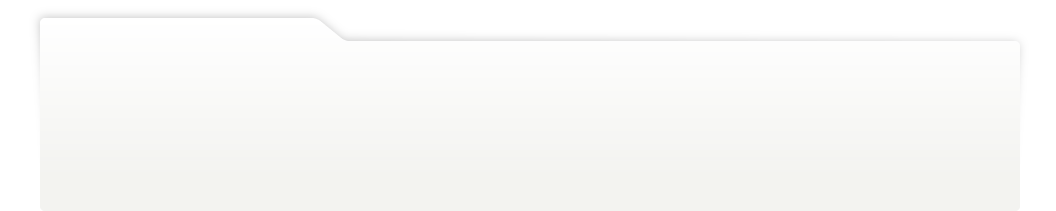
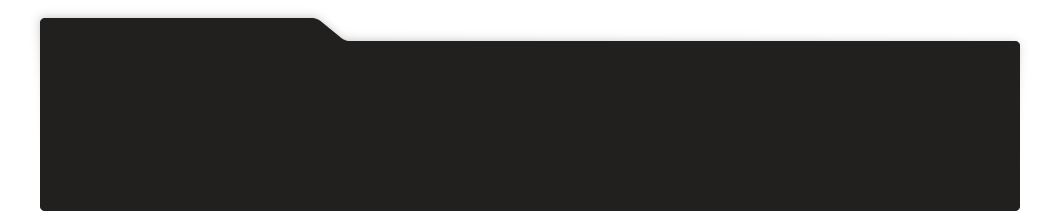
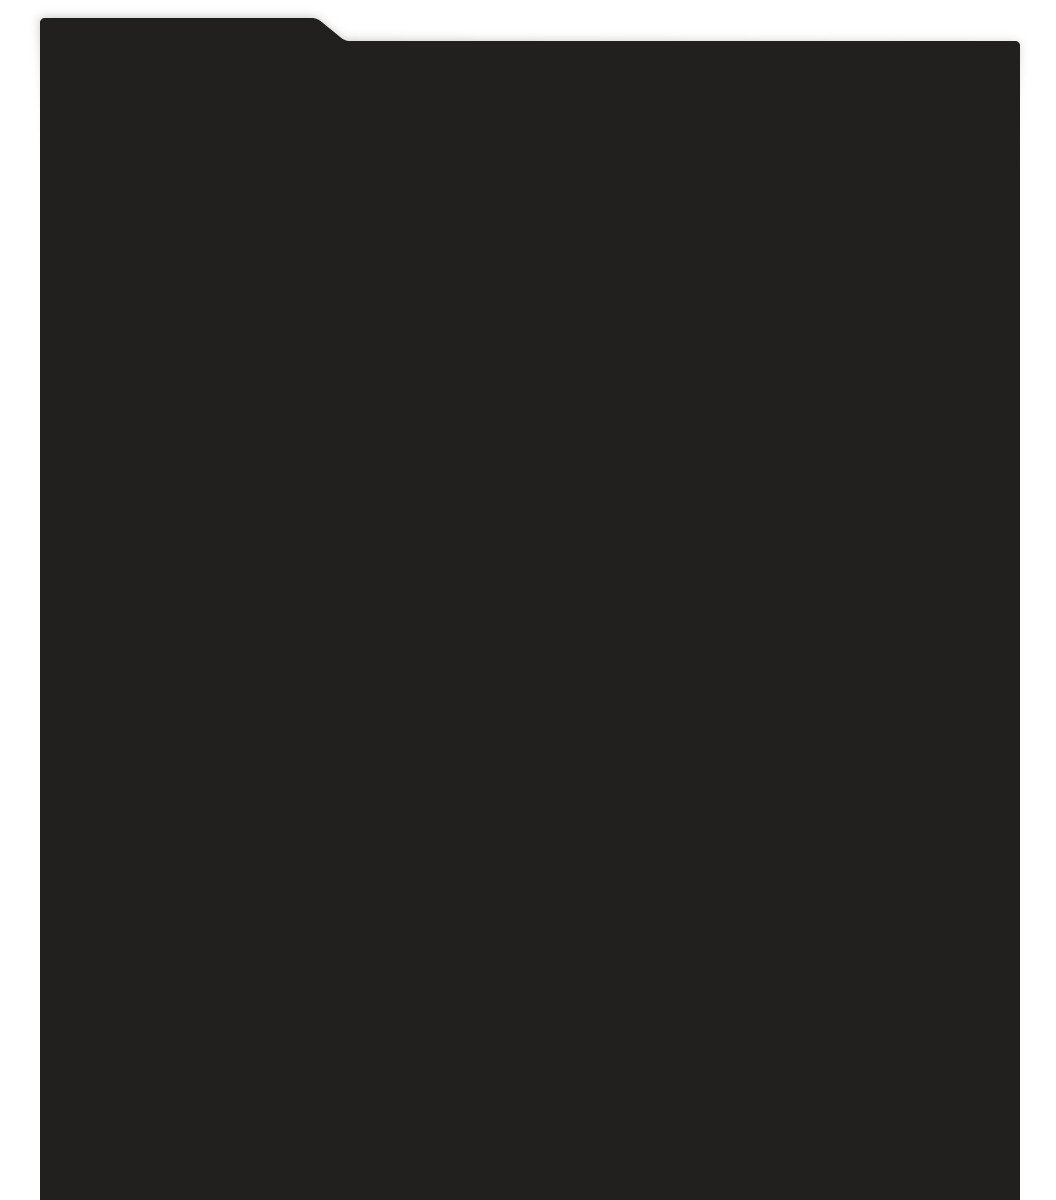
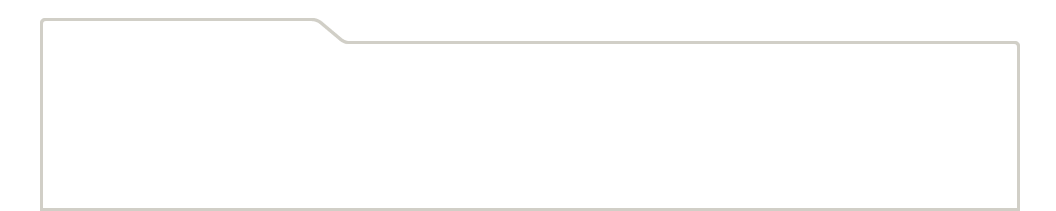
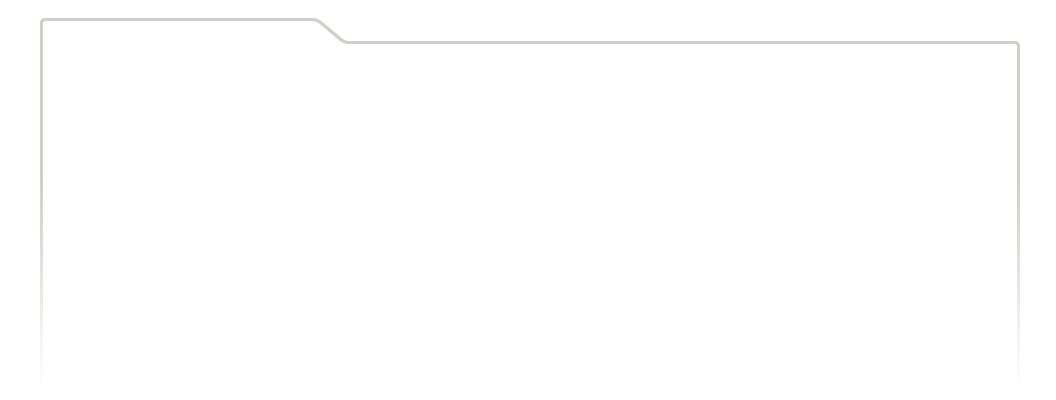
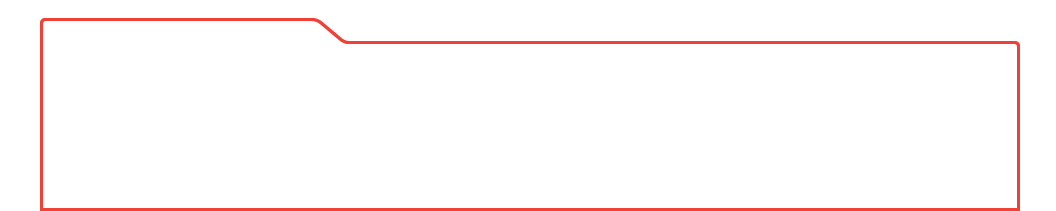
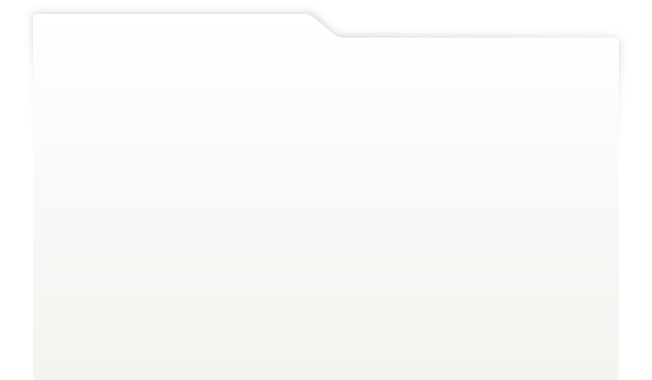
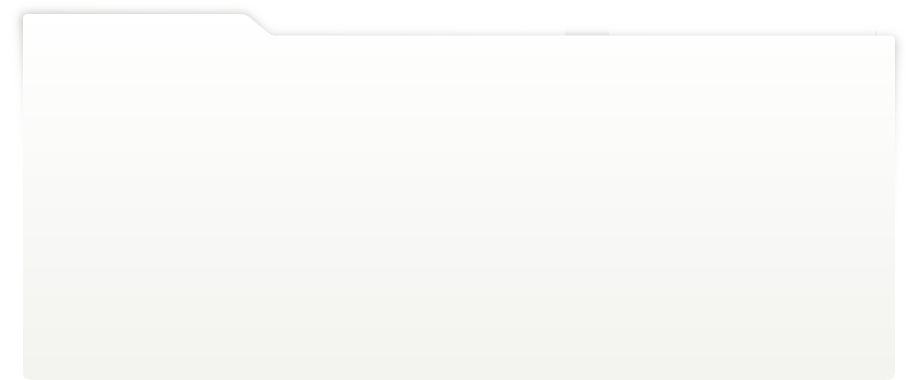
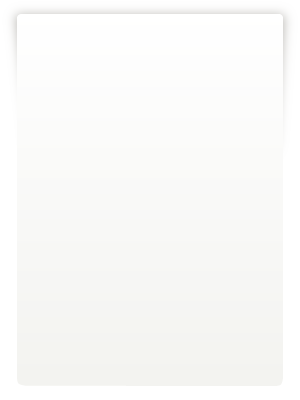
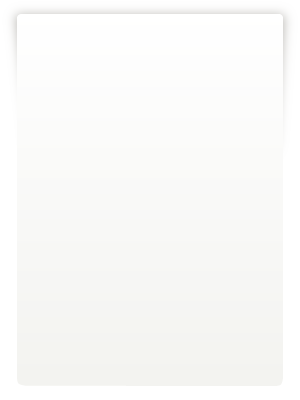
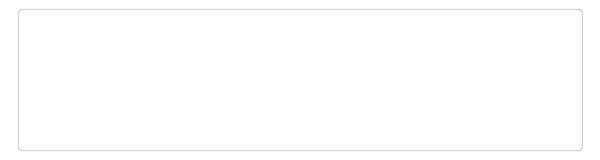
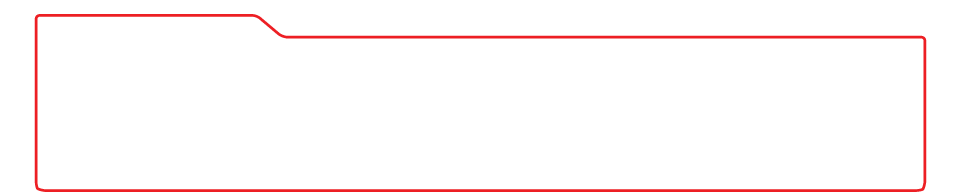
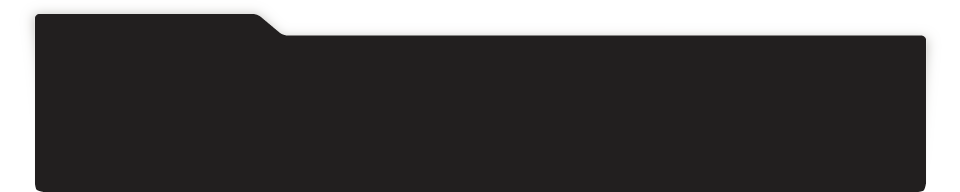
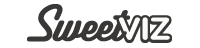
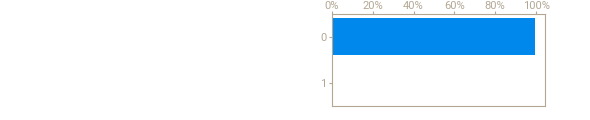
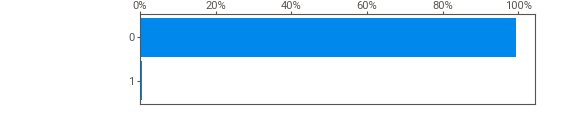
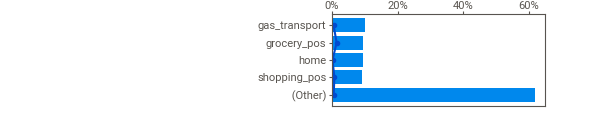
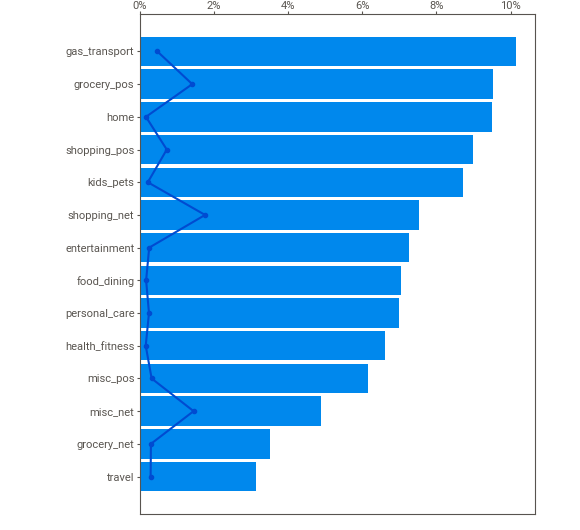
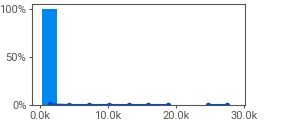
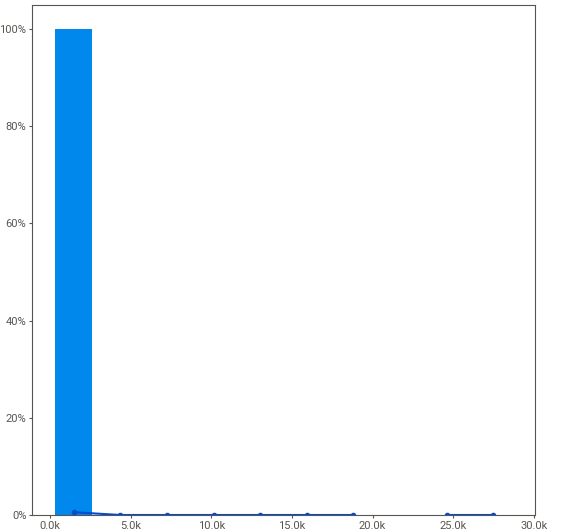
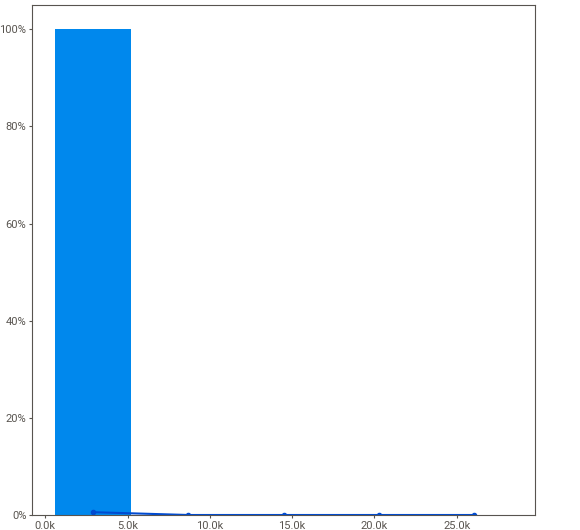
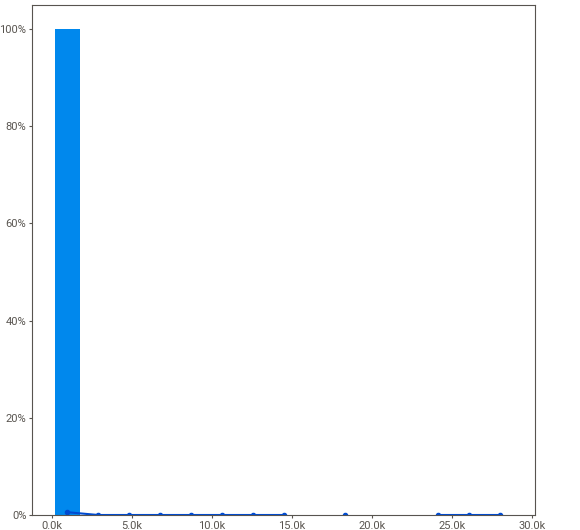
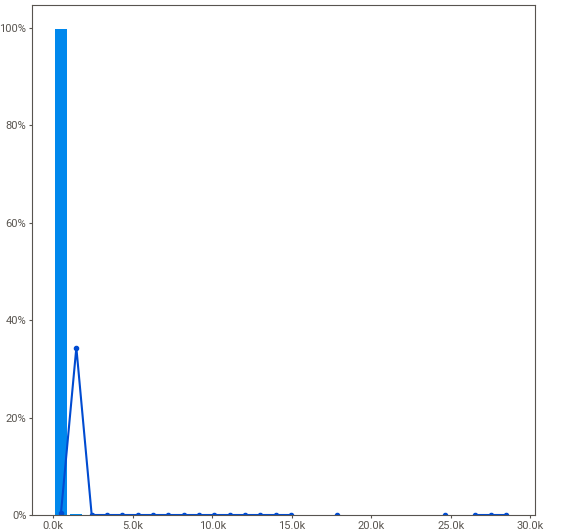
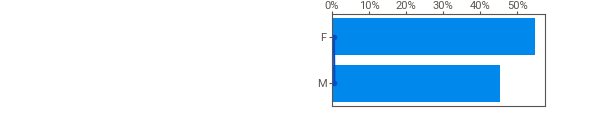
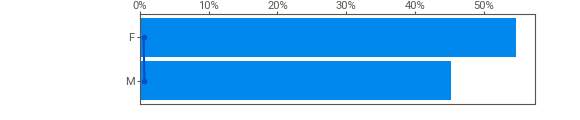
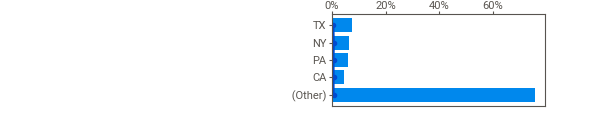
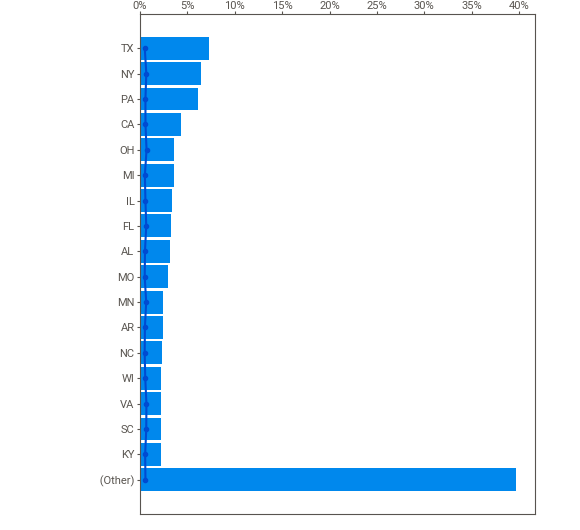
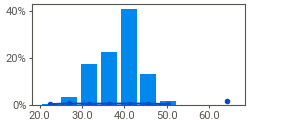
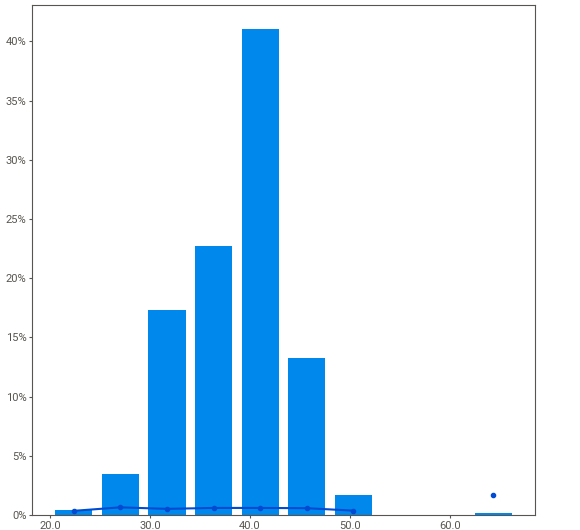
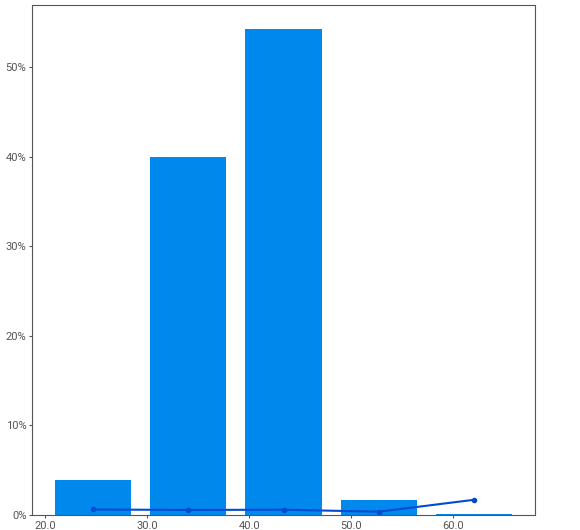
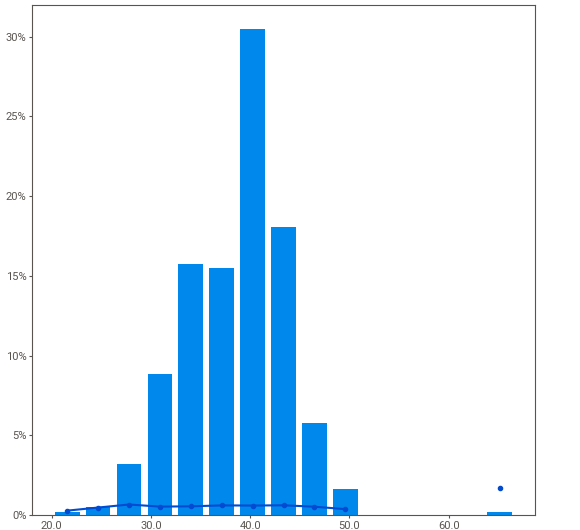
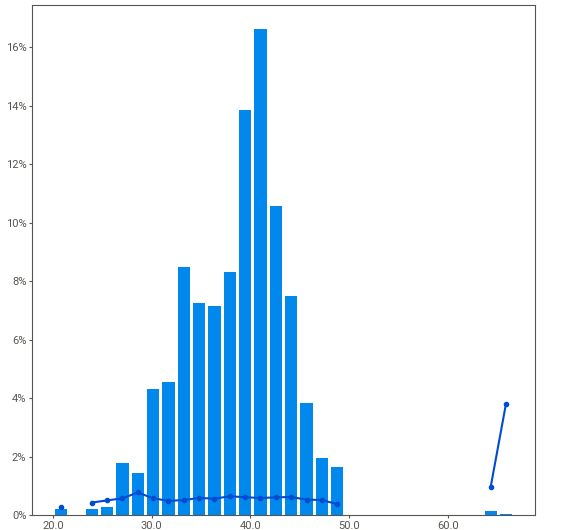
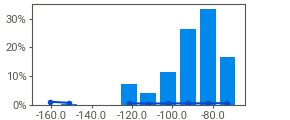
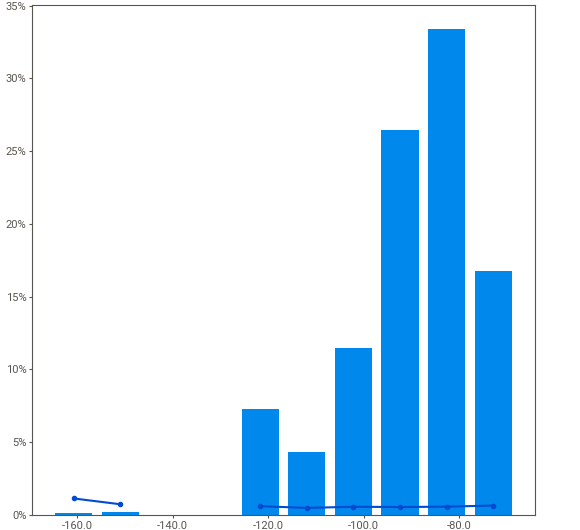
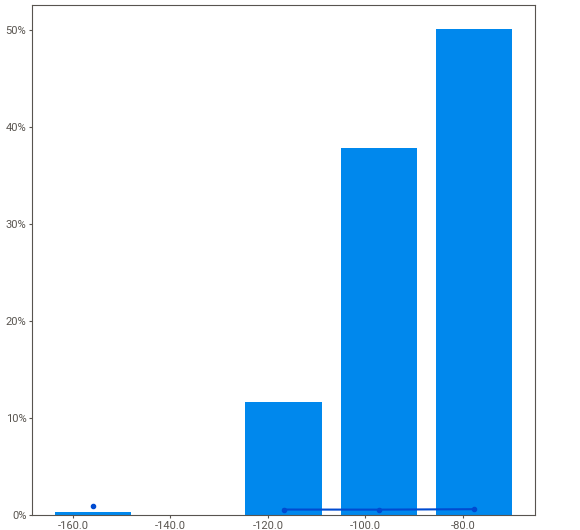
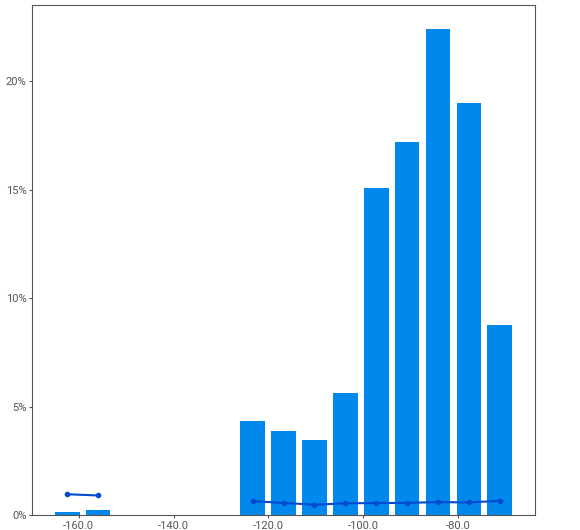
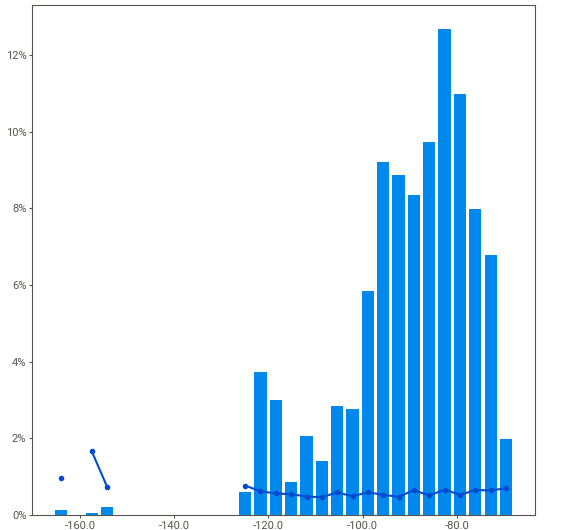
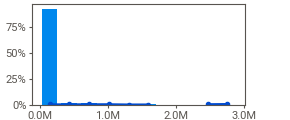
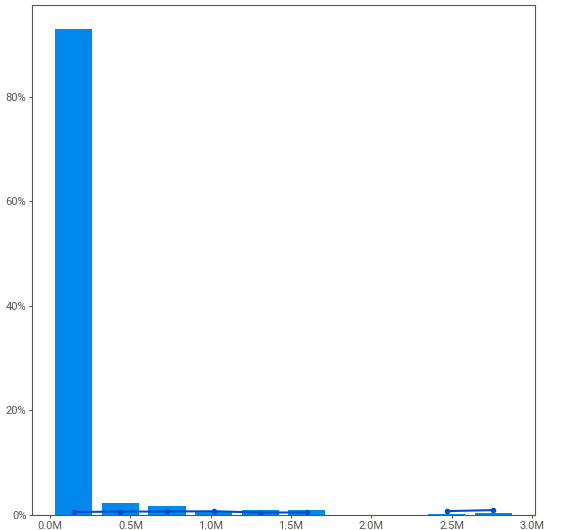
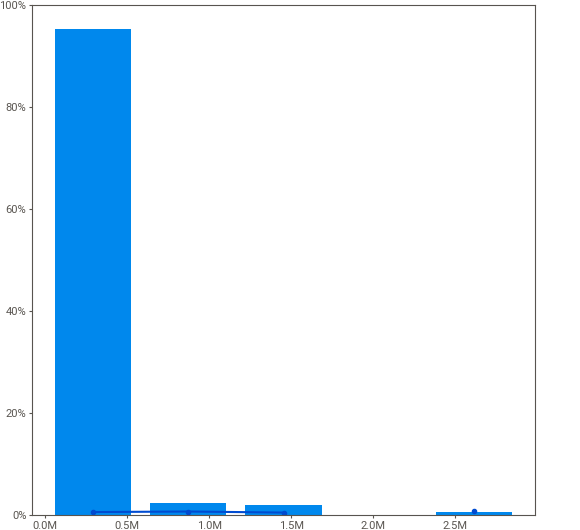
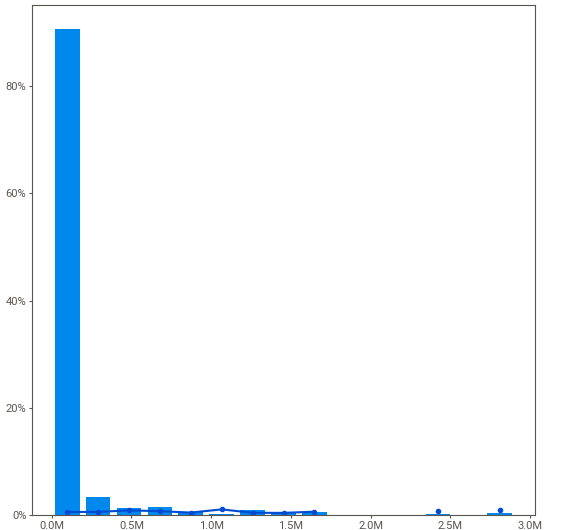
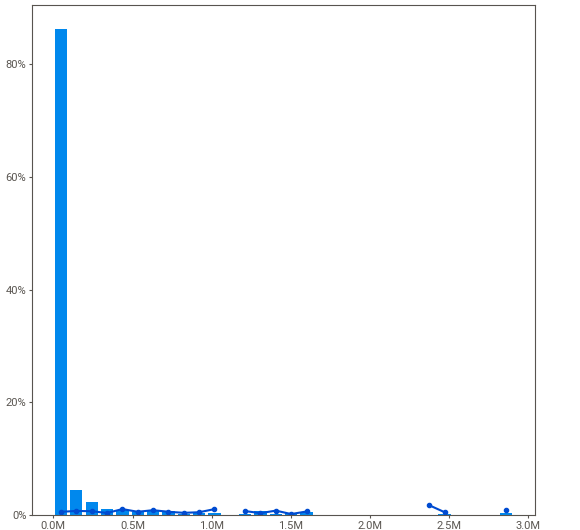
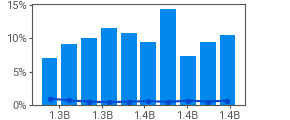
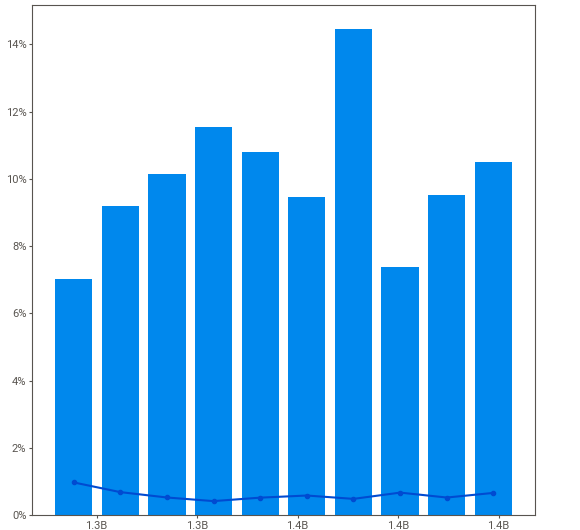
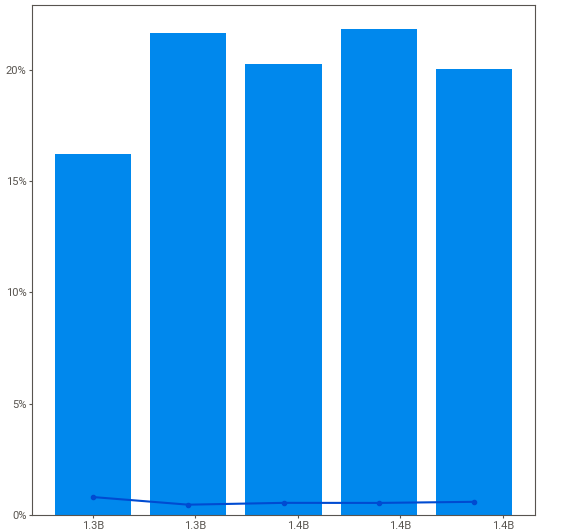
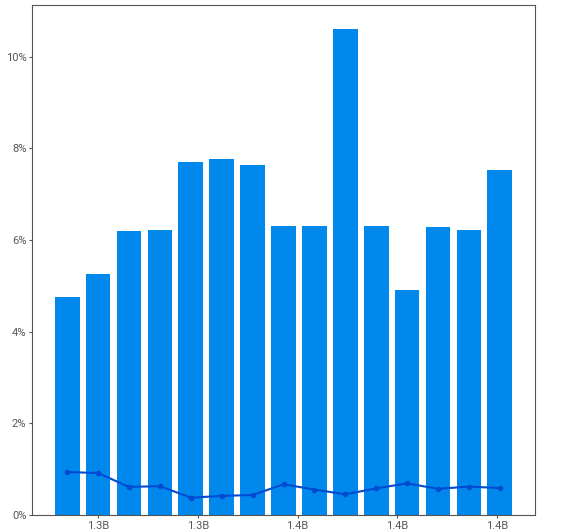
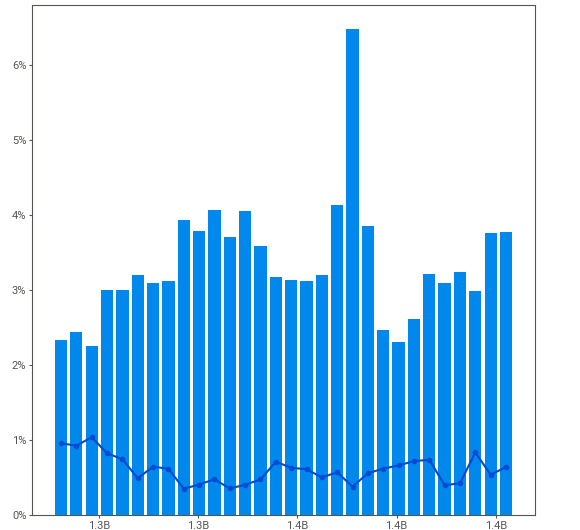
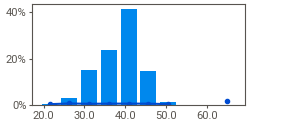
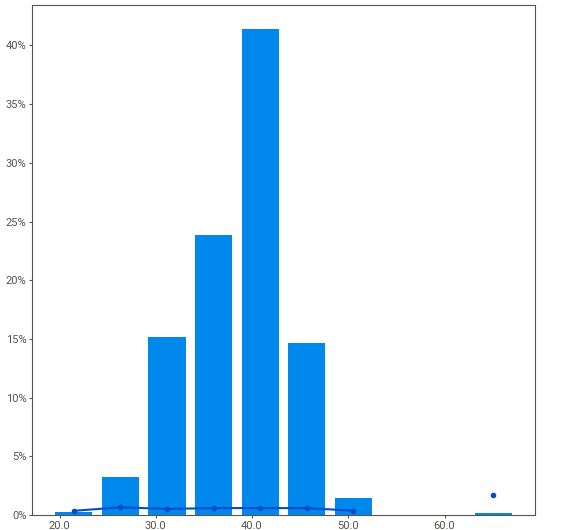
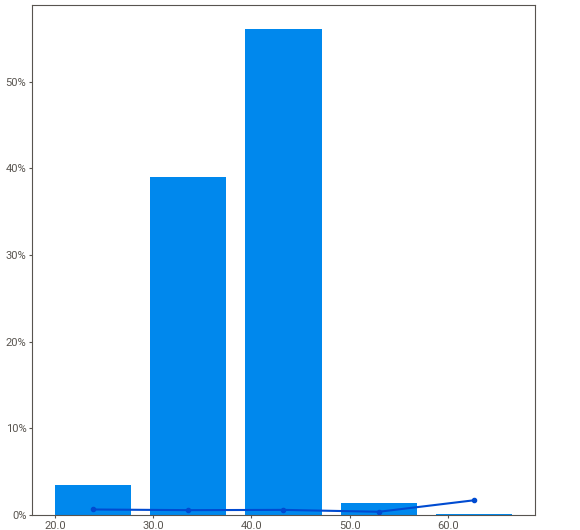
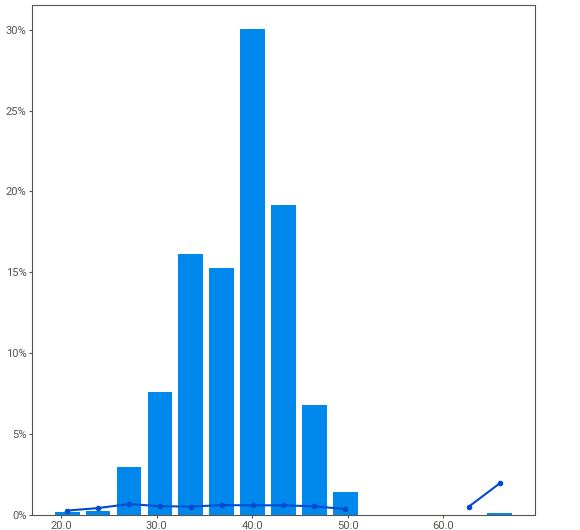
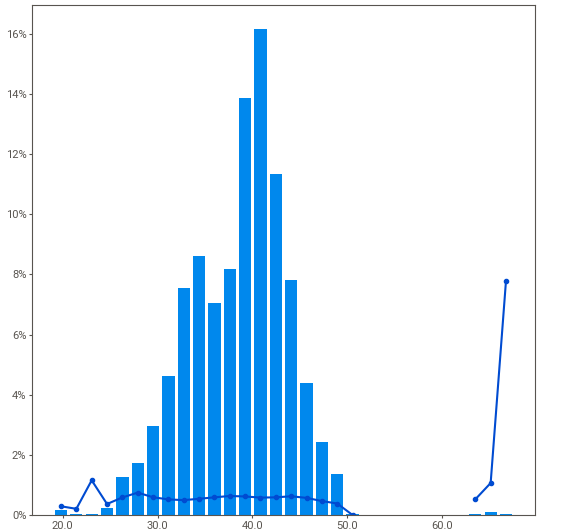
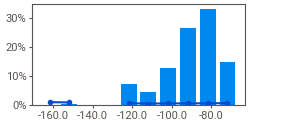
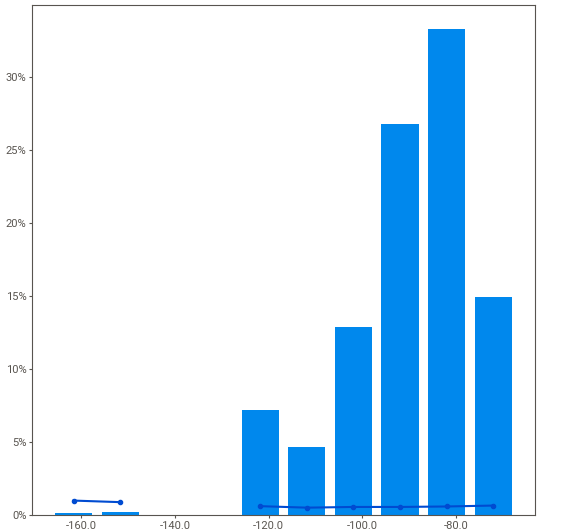
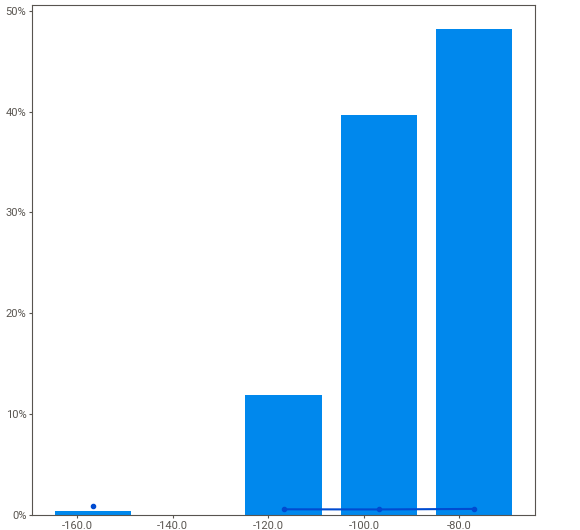
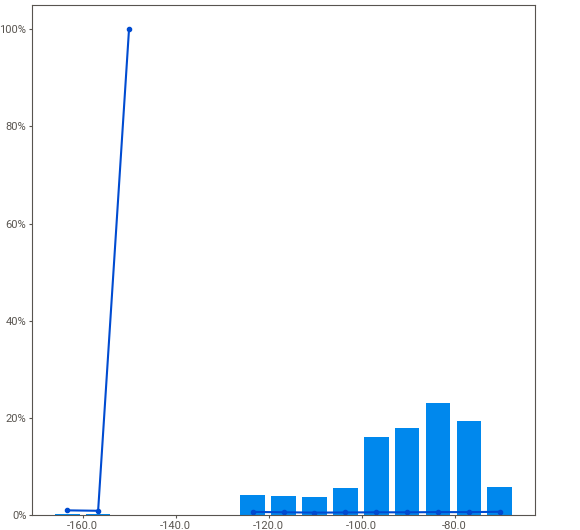
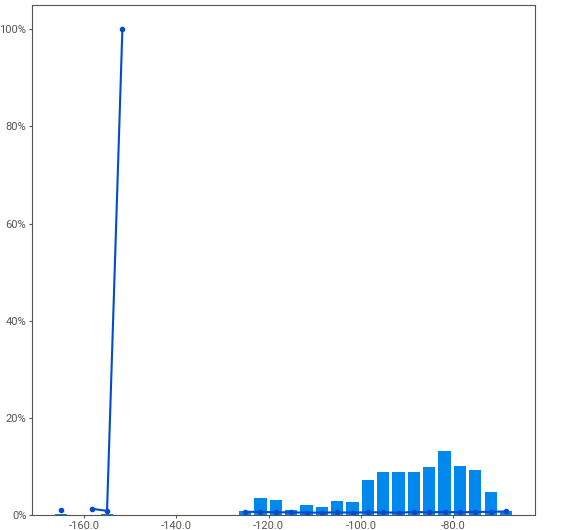
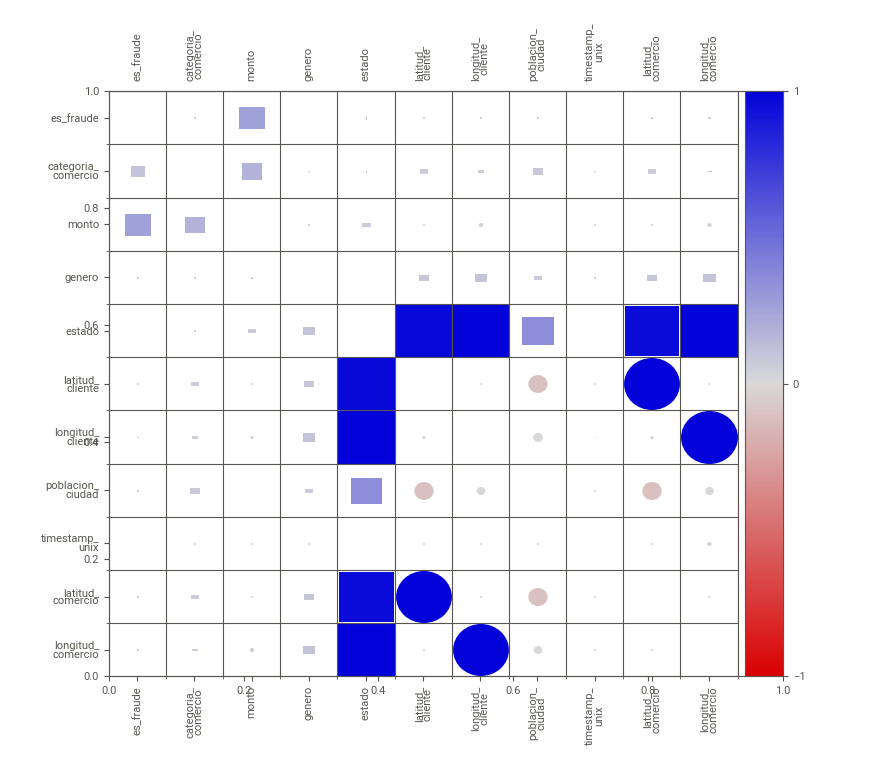
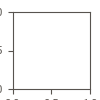

In [13]:
report = sv.analyze(df_train, target_feat="es_fraude")
report.show_notebook()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)



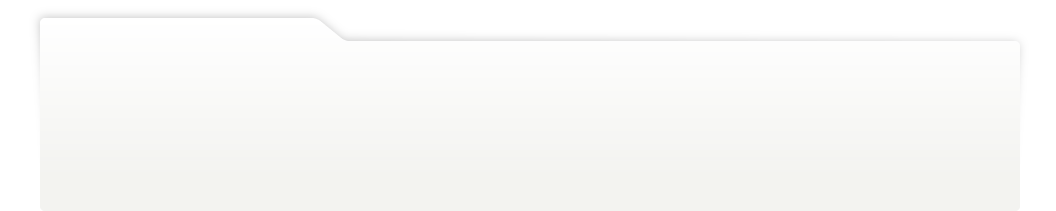
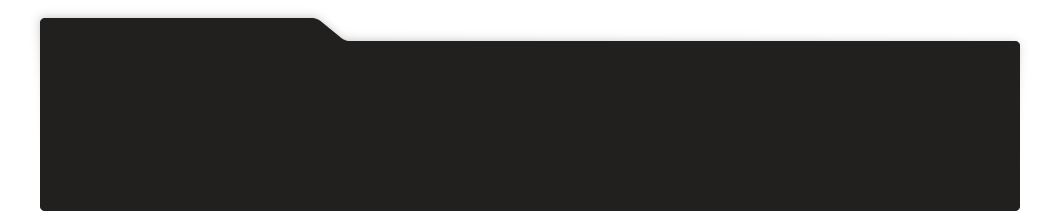
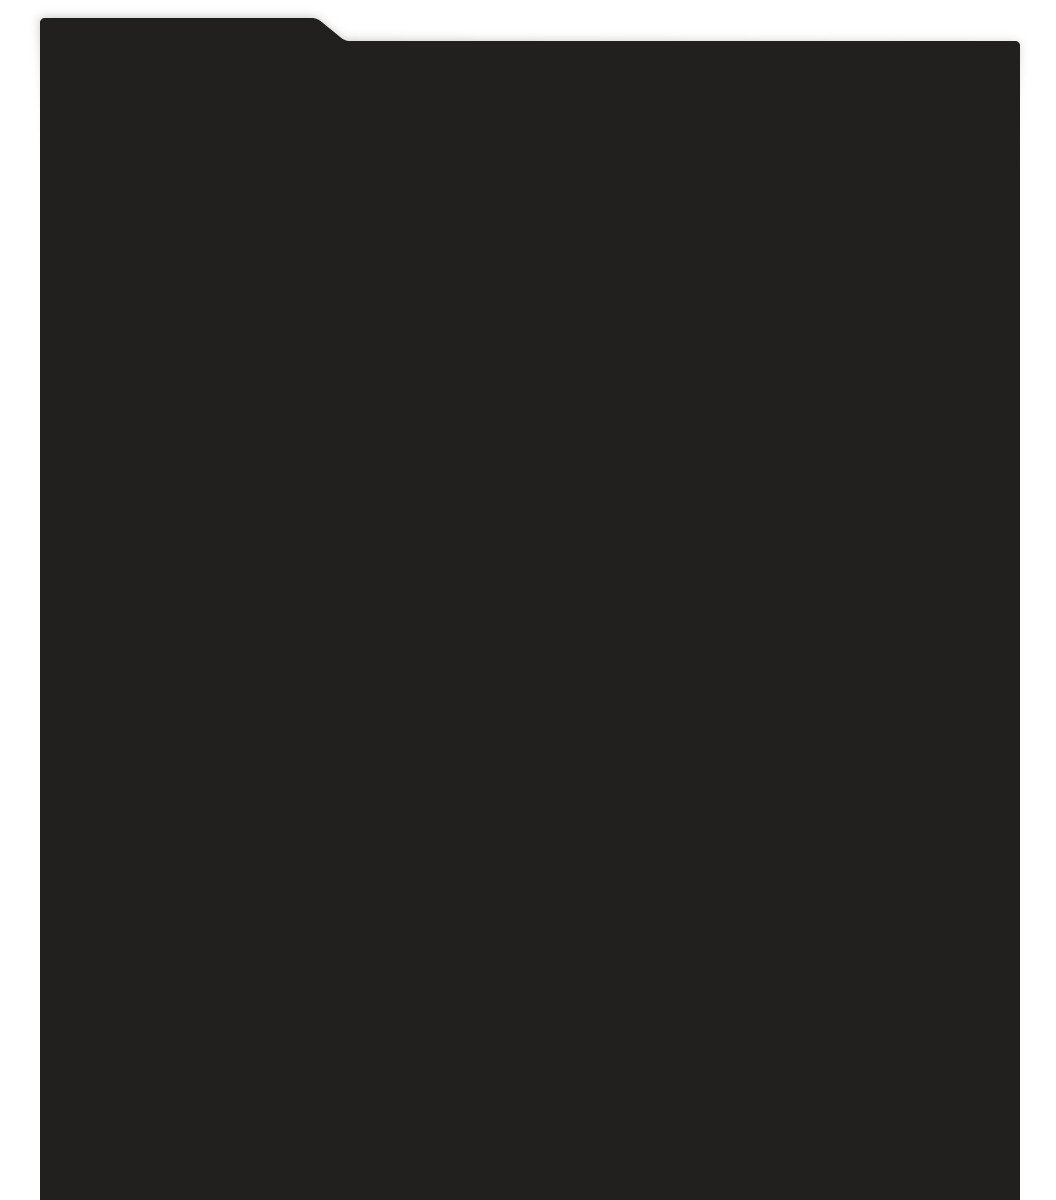
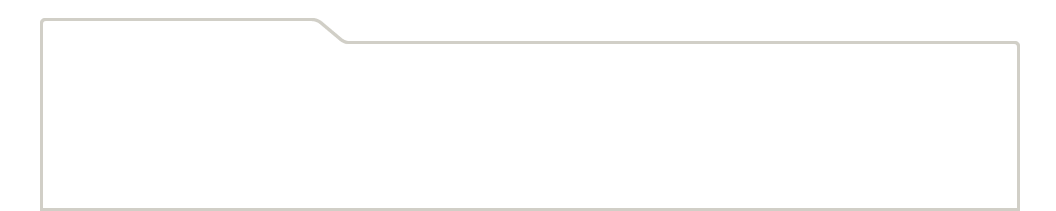
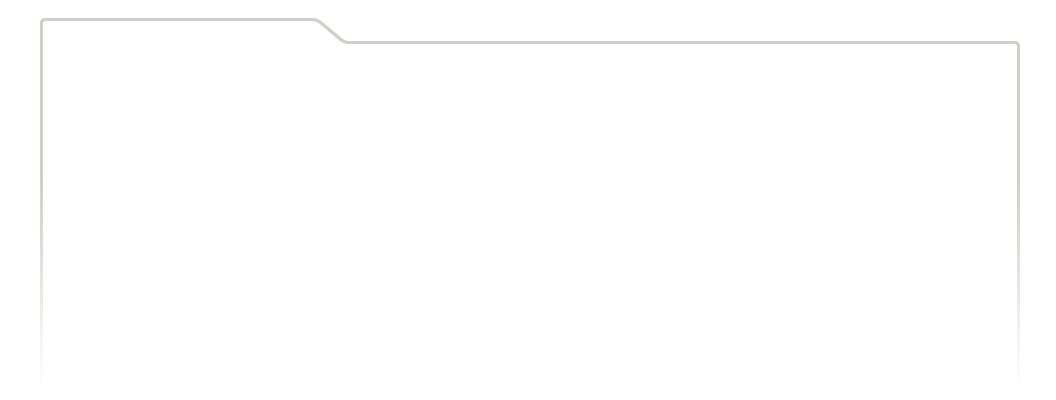
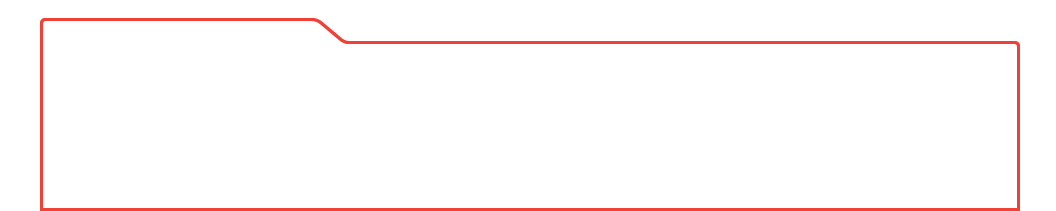
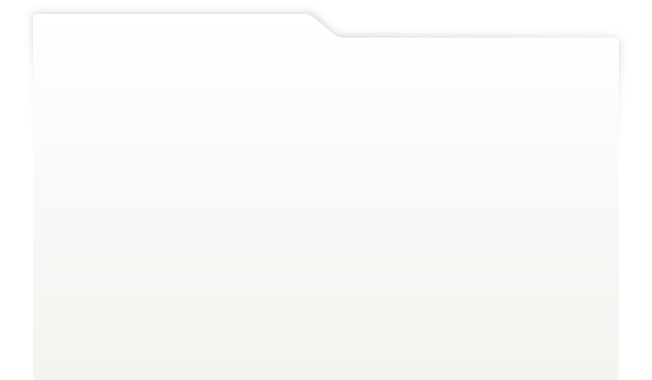
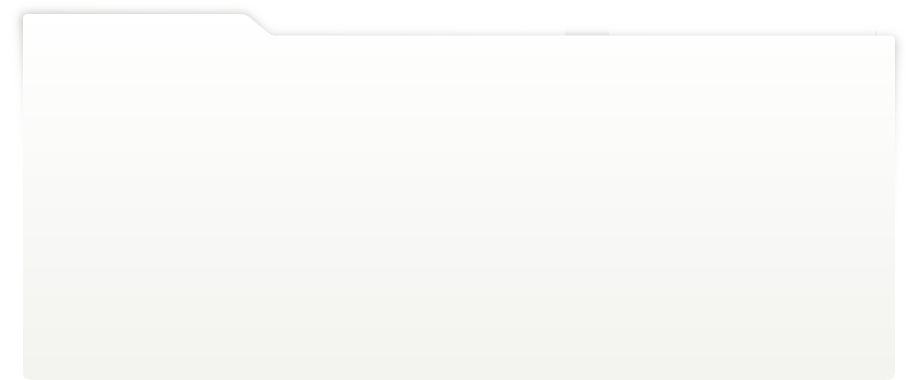
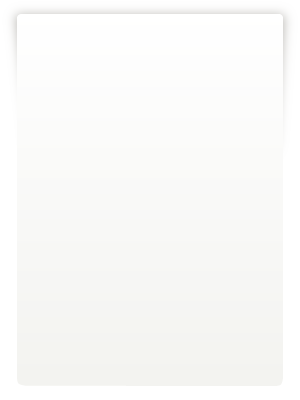
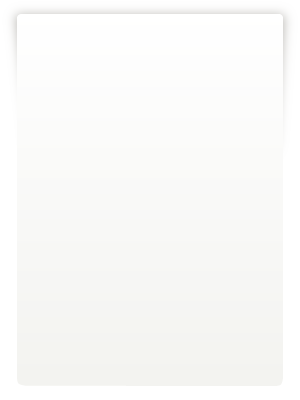
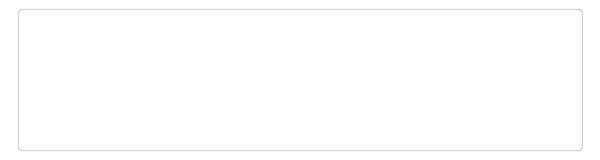
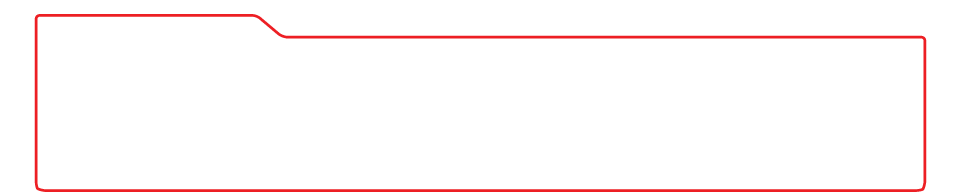
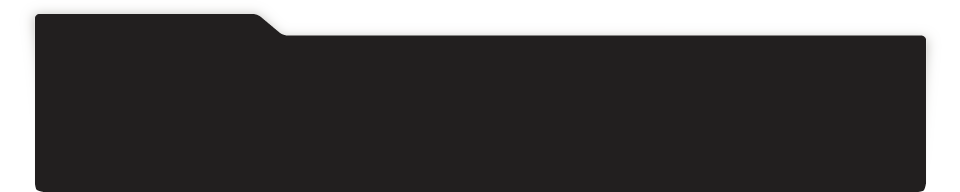
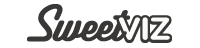
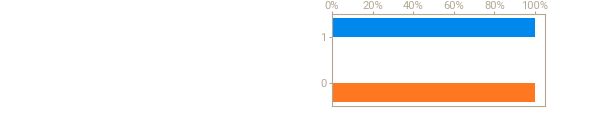
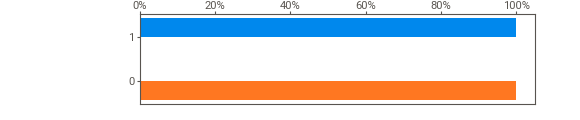
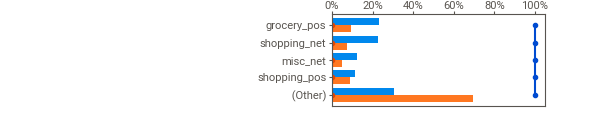
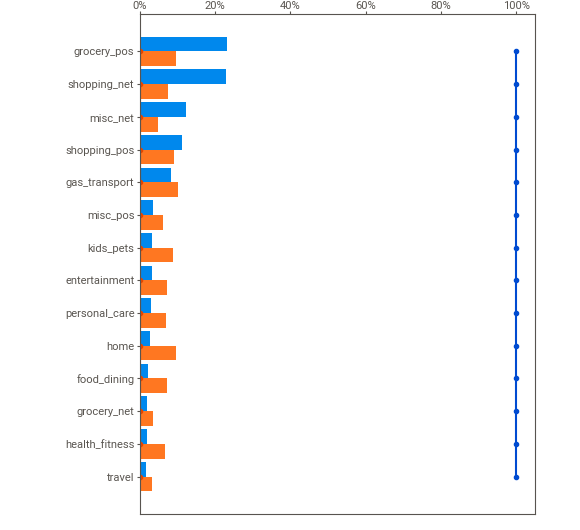
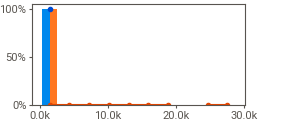
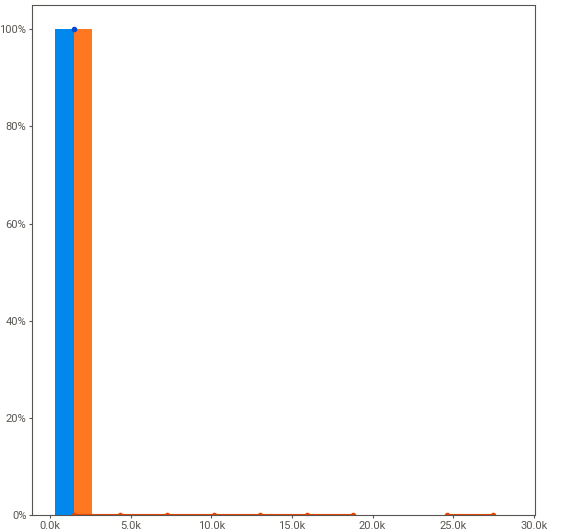
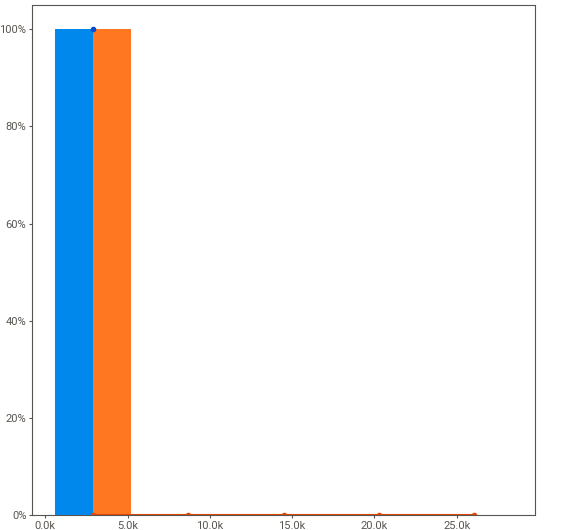
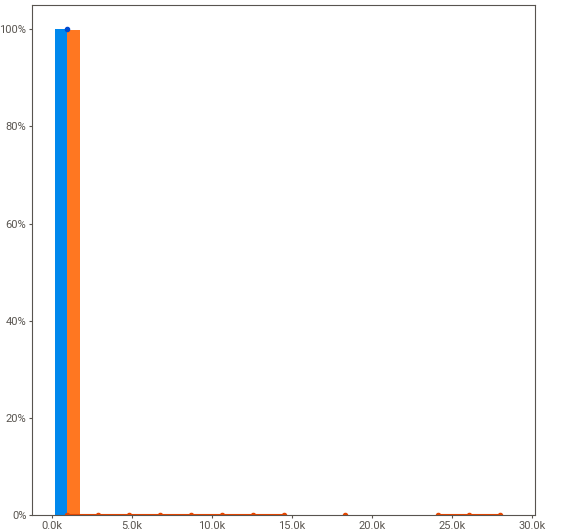
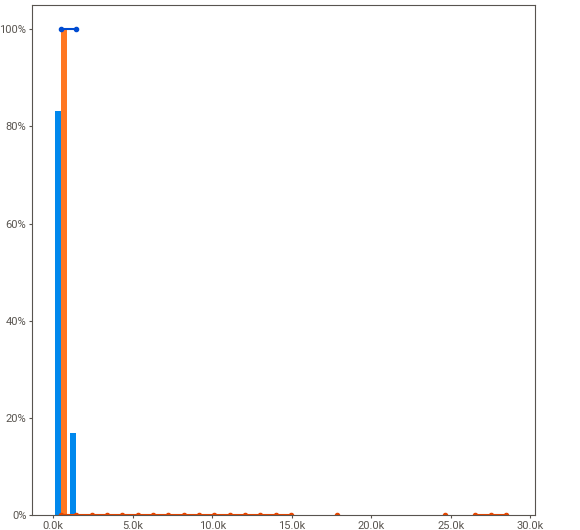
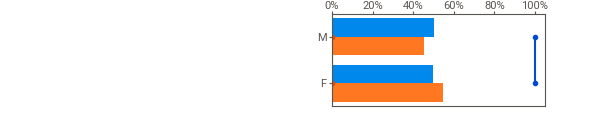
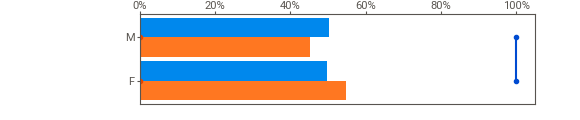
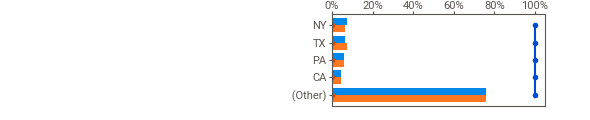
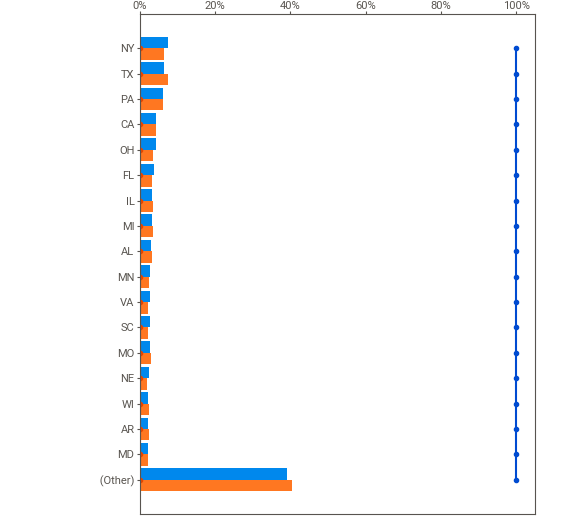
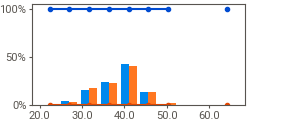
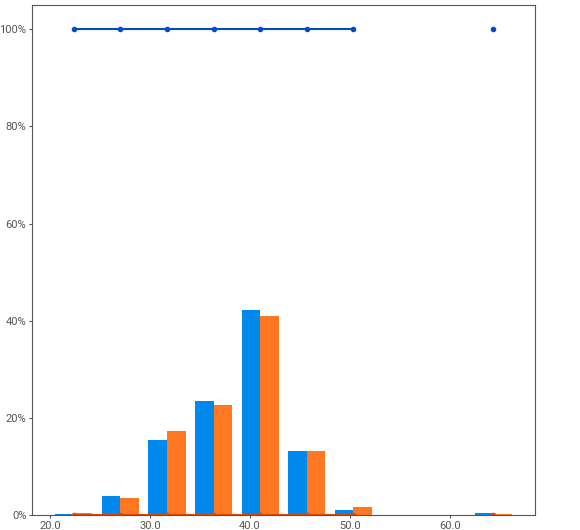
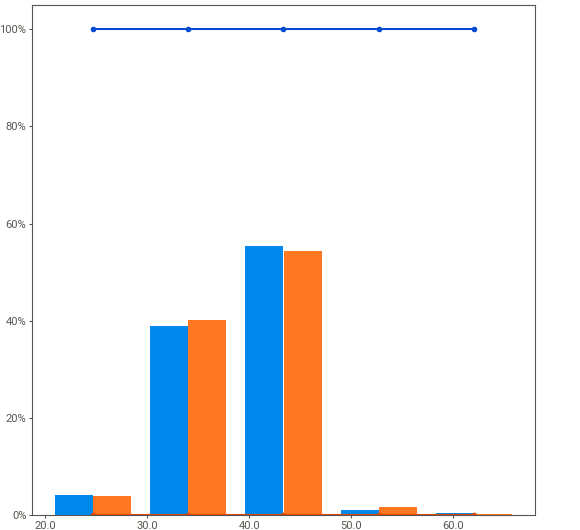
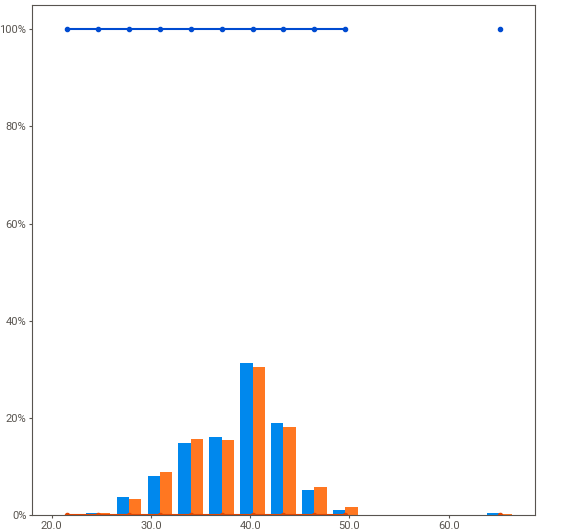
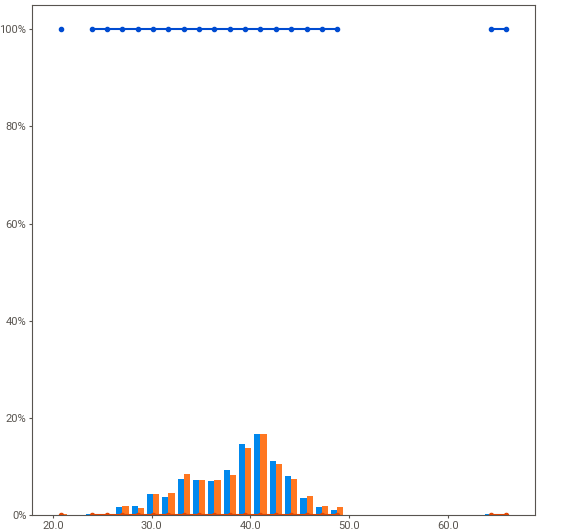
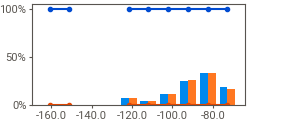
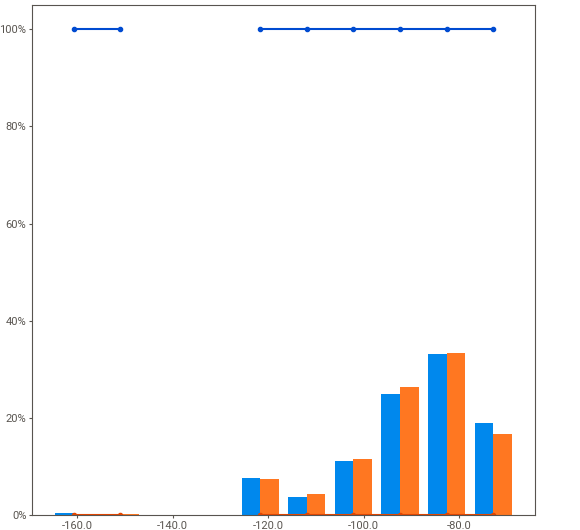
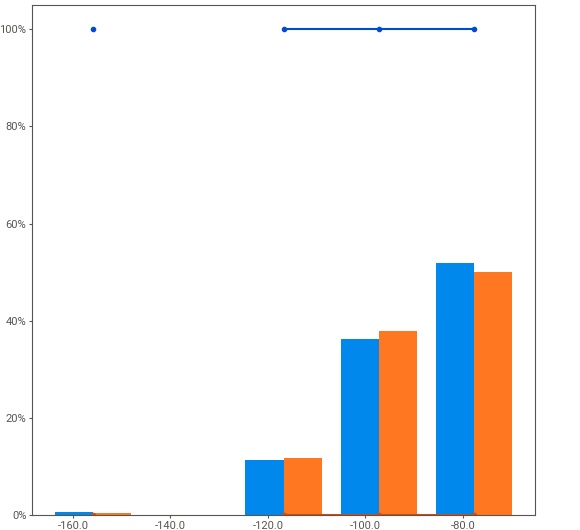
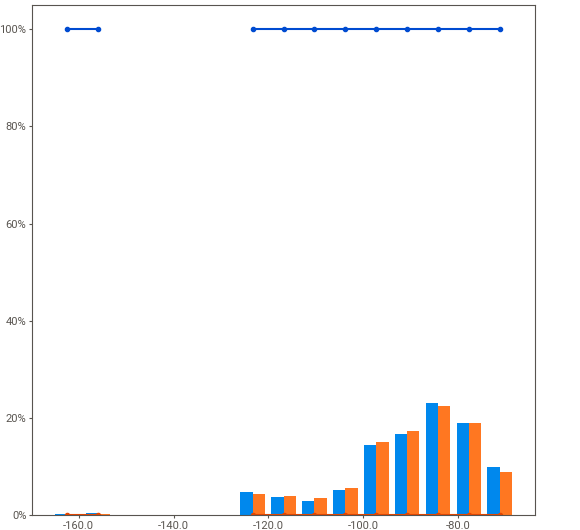
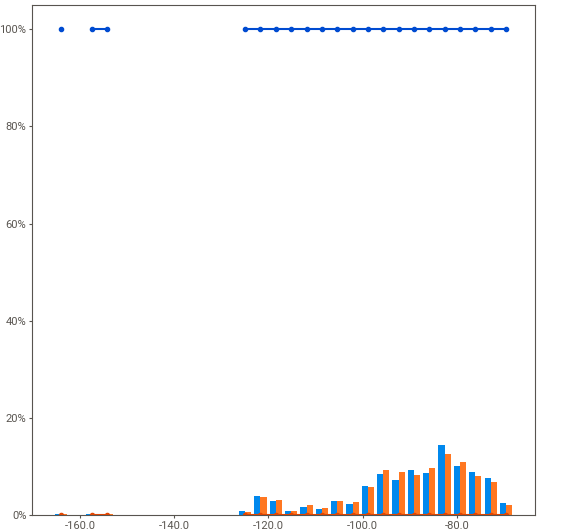
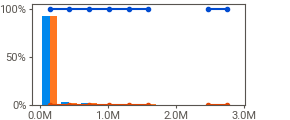
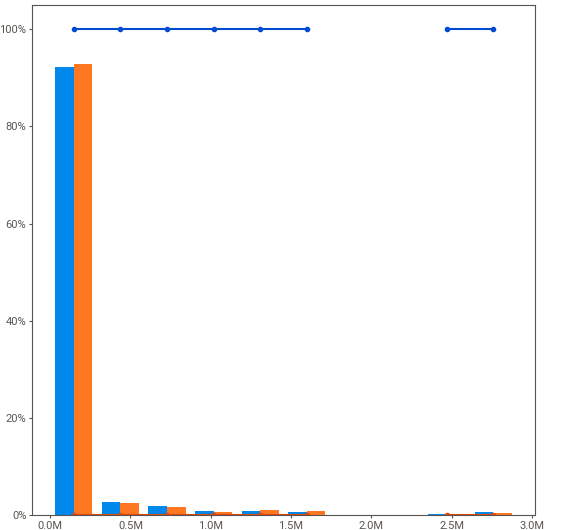
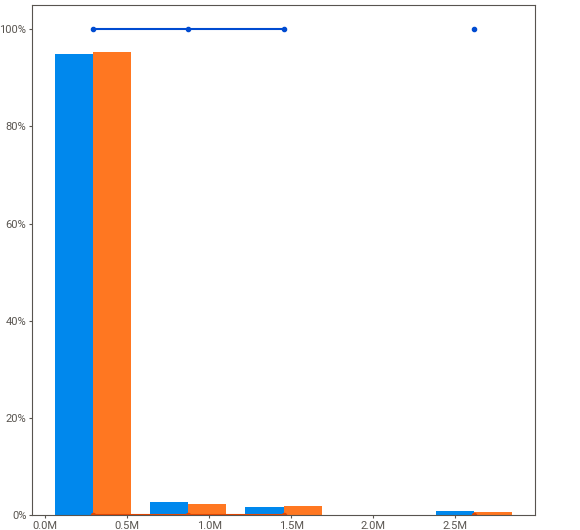
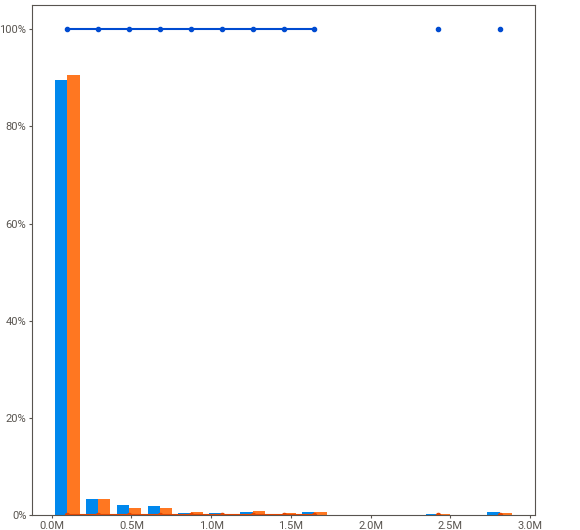
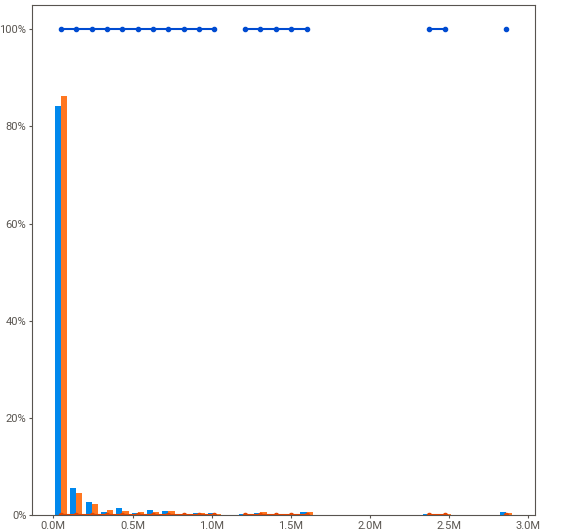
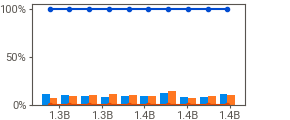
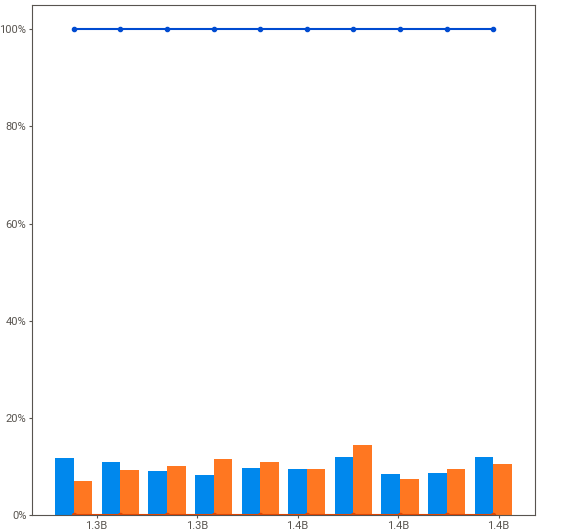
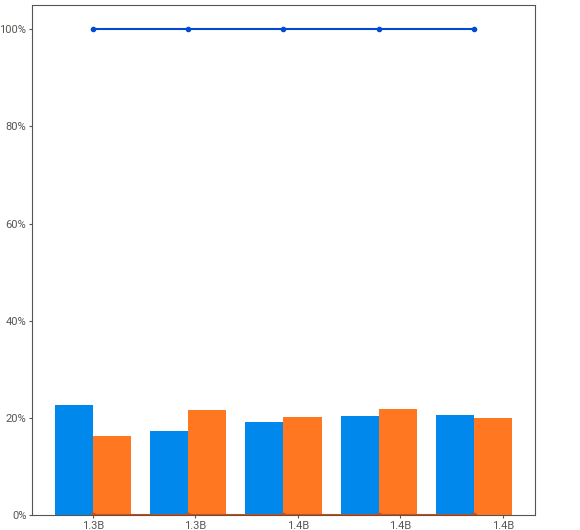
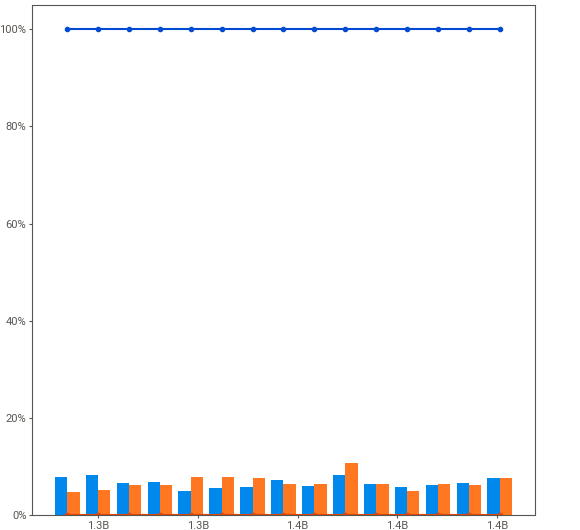
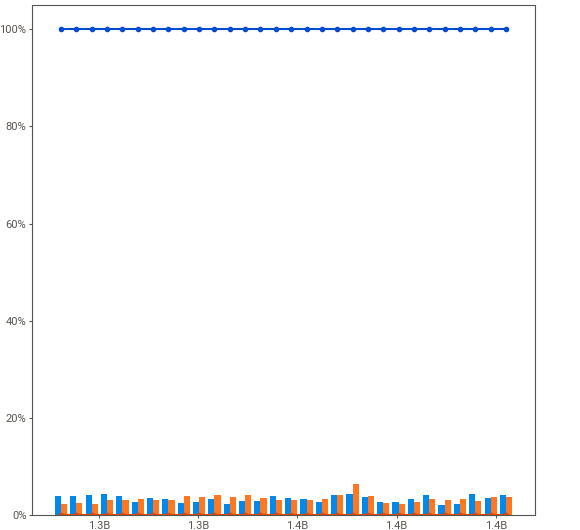
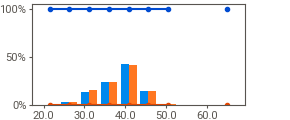
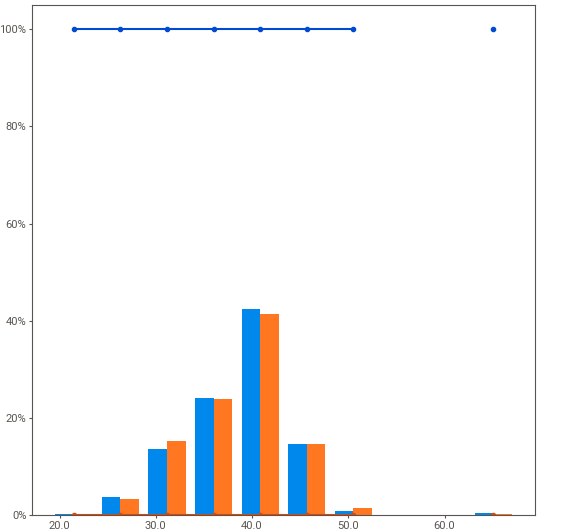
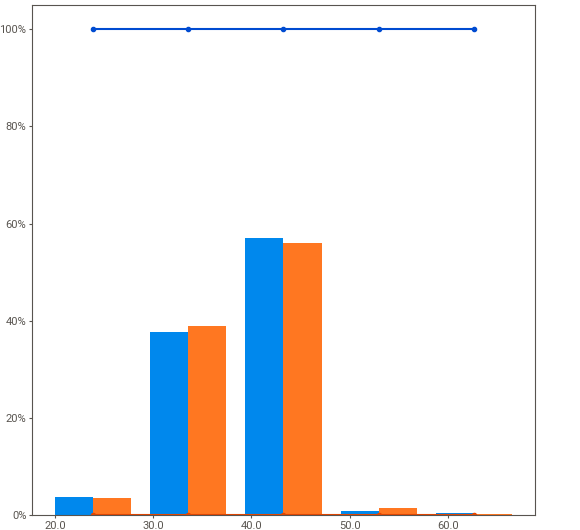
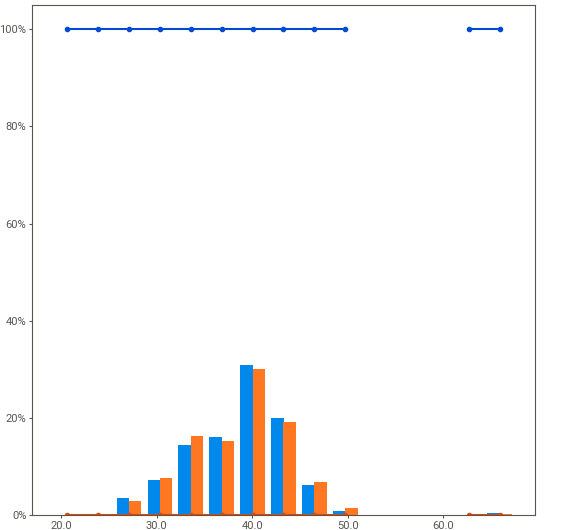
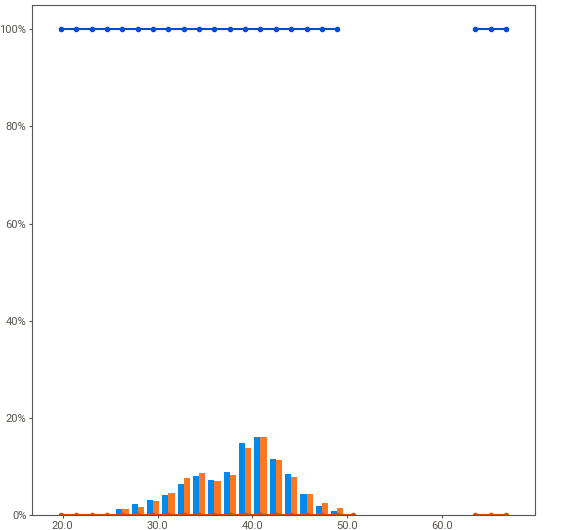
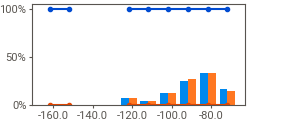
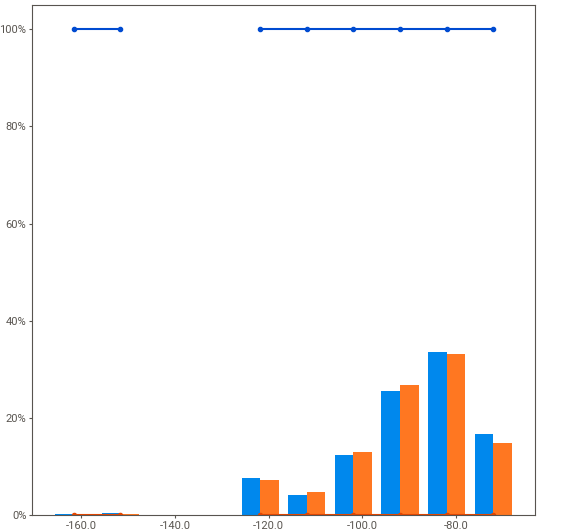
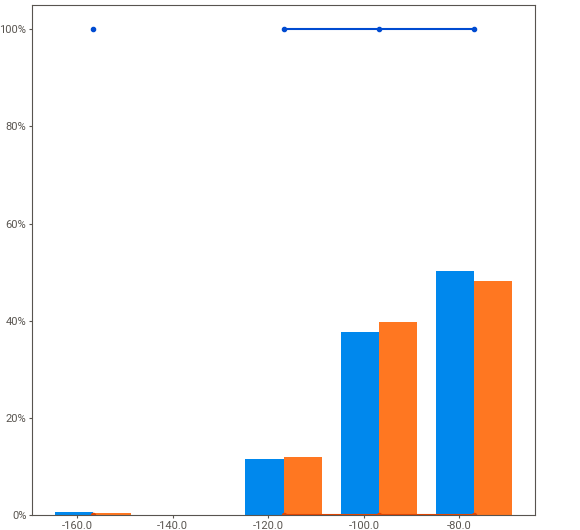
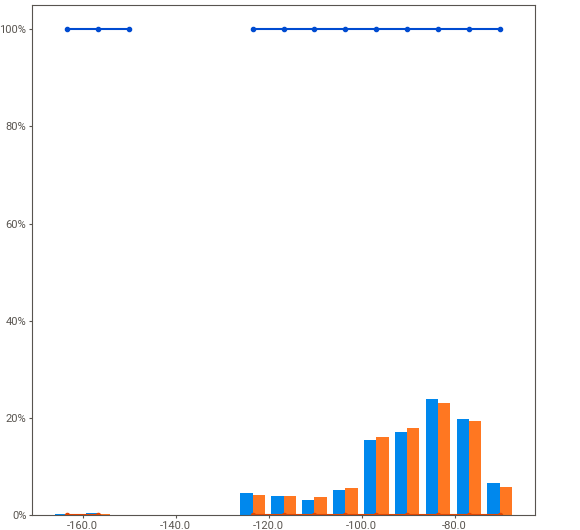
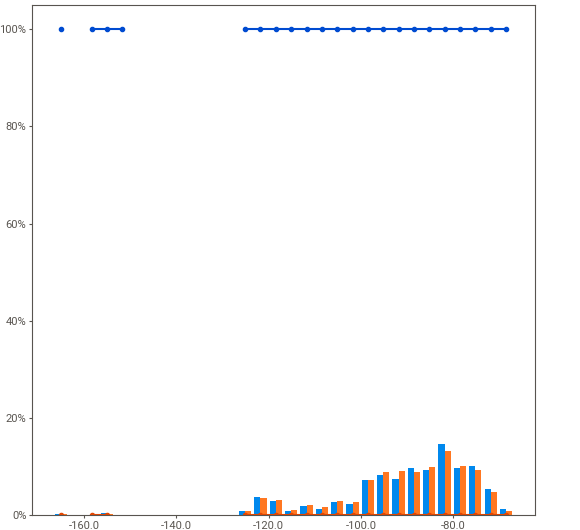
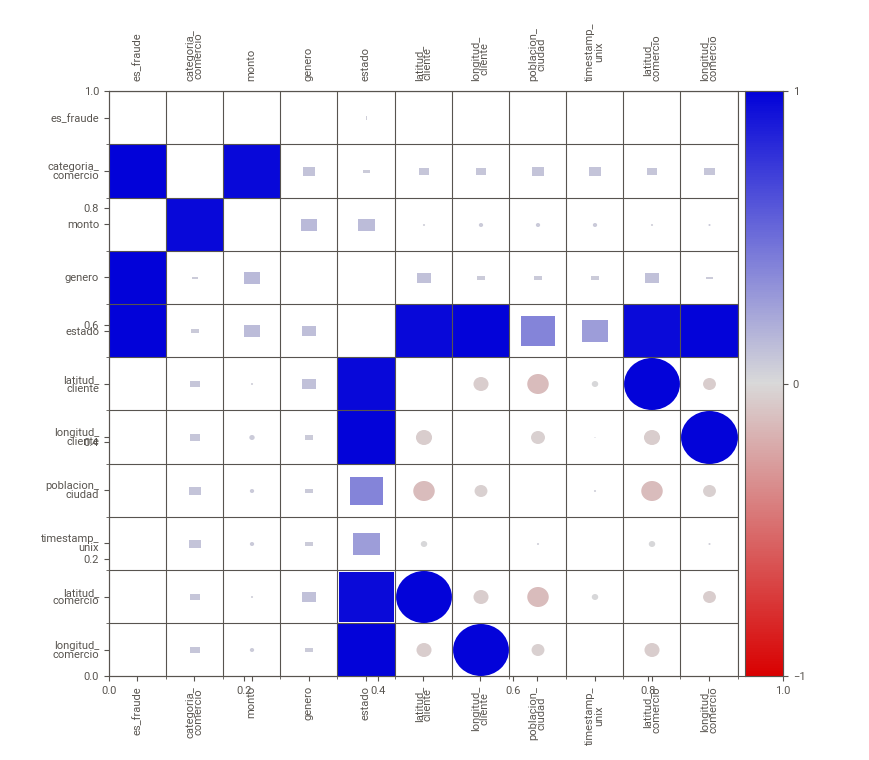
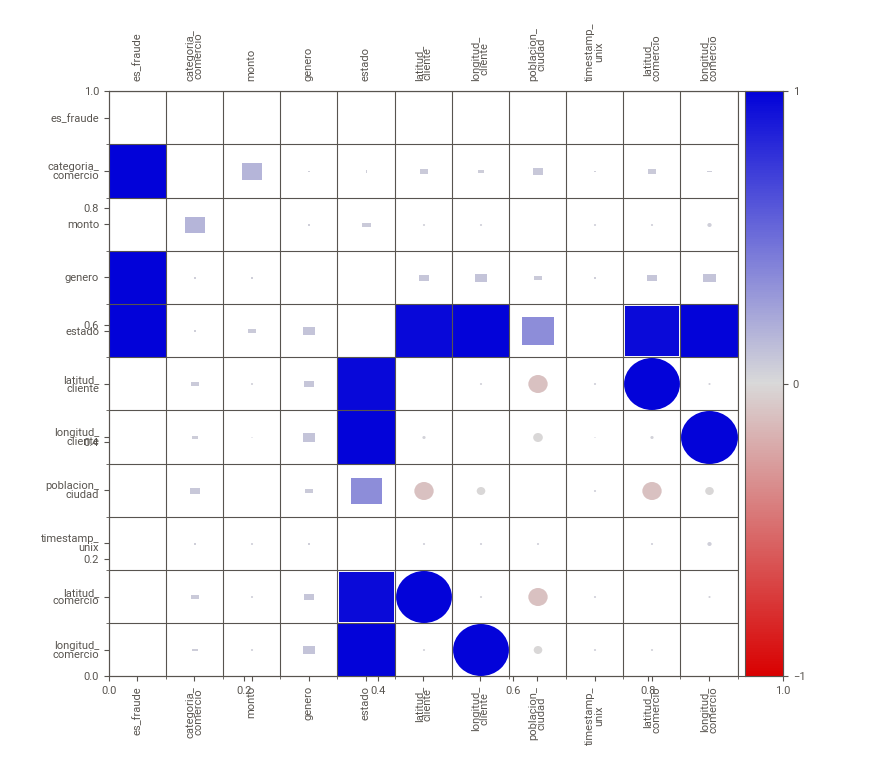

In [14]:
report_fraude = sv.compare_intra(
    df_train,
    df_train["es_fraude"] == 1,
    ["Fraude", "No fraude"],
    target_feat="es_fraude"
)

report_fraude.show_notebook()

In [15]:
df_train["type"] = "train"
df_test["type"] = "test"

df_fraude = pd.concat([df_train, df_test], ignore_index=True)
df_fraude.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 20 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   fecha_hora_transaccion  datetime64[ns]
 1   numero_tarjeta          string        
 2   comercio                object        
 3   categoria_comercio      category      
 4   monto                   float64       
 5   genero                  category      
 6   direccion               object        
 7   ciudad                  object        
 8   estado                  object        
 9   codigo_postal           string        
 10  latitud_cliente         float64       
 11  longitud_cliente        float64       
 12  poblacion_ciudad        int64         
 13  ocupacion               object        
 14  fecha_nacimiento        datetime64[ns]
 15  timestamp_unix          int64         
 16  latitud_comercio        float64       
 17  longitud_comercio       float64       
 18  es

In [16]:
# Usar dataframe existente
transactions_clean_v1 = df_fraude.copy()

# Estandarizar fechas
transactions_clean_v1["fecha_hora_transaccion"] = pd.to_datetime(
    transactions_clean_v1["fecha_hora_transaccion"], errors="coerce"
)

transactions_clean_v1["fecha_nacimiento"] = pd.to_datetime(
    transactions_clean_v1["fecha_nacimiento"], errors="coerce"
)

# Estandarizar columnas numéricas
numeric_cols = [
    "monto", "latitud_cliente", "longitud_cliente", "poblacion_ciudad",
    "timestamp_unix", "latitud_comercio", "longitud_comercio",
    "es_fraude", "codigo_postal"
]

for col in numeric_cols:
    if col in transactions_clean_v1.columns:
        transactions_clean_v1[col] = pd.to_numeric(
            transactions_clean_v1[col], errors="coerce"
        )

# Feature engineering
transactions_clean_v1["hora_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.hour.astype("Int64")
transactions_clean_v1["dia_semana_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.day_name()
transactions_clean_v1["mes_transaccion"] = transactions_clean_v1["fecha_hora_transaccion"].dt.month.astype("Int64")

# Edad aproximada del cliente al momento de la transacción
edad_anios = (
    (transactions_clean_v1["fecha_hora_transaccion"] - transactions_clean_v1["fecha_nacimiento"]).dt.days / 365.25
)

transactions_clean_v1["edad_cliente"] = np.floor(edad_anios).astype("Int64")

# Distancia Haversine entre cliente y comercio
lat1 = np.radians(transactions_clean_v1["latitud_cliente"])
lon1 = np.radians(transactions_clean_v1["longitud_cliente"])
lat2 = np.radians(transactions_clean_v1["latitud_comercio"])
lon2 = np.radians(transactions_clean_v1["longitud_comercio"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2.0) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

transactions_clean_v1["distancia_km"] = 6371.0 * c

# Protección de datos personales
pii_cols = ["nombre", "apellido", "direccion"]

transactions_clean_v1 = transactions_clean_v1.drop(
    columns=[c for c in pii_cols if c in transactions_clean_v1.columns]
)

# Remover número de tarjeta, dejando solo últimos 4 dígitos
if "numero_tarjeta" in transactions_clean_v1.columns:
    transactions_clean_v1["tarjeta_ultimos4"] = transactions_clean_v1["numero_tarjeta"].astype(str).str[-4:]
    transactions_clean_v1 = transactions_clean_v1.drop(columns=["numero_tarjeta"])

transactions_clean_v1.head()

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,es_fraude,type,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,1325376018,36.01,-82.05,0,train,0,Tuesday,1,30,78.60,2095
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1325376044,49.16,-118.19,0,train,0,Tuesday,1,40,30.21,7322
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,1325376051,43.15,-112.15,0,train,0,Tuesday,1,56,108.21,7661
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,1325376076,47.03,-112.56,0,train,0,Tuesday,1,51,95.67,0240
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,1325376186,38.67,-78.63,0,train,0,Tuesday,1,32,77.56,3984


In [17]:
columnas_finales = [
    "fecha_hora_transaccion",
    "comercio",
    "categoria_comercio",
    "monto",
    "genero",
    "ciudad",
    "estado",
    "codigo_postal",
    "latitud_cliente",
    "longitud_cliente",
    "poblacion_ciudad",
    "ocupacion",
    "fecha_nacimiento",
    "id_transaccion",
    "timestamp_unix",
    "latitud_comercio",
    "longitud_comercio",
    "hora_transaccion",
    "dia_semana_transaccion",
    "mes_transaccion",
    "edad_cliente",
    "distancia_km",
    "tarjeta_ultimos4",
    "es_fraude",
    "type"
]

columnas_existentes = [col for col in columnas_finales if col in transactions_clean_v1.columns]

transactions_clean_v1 = transactions_clean_v1.loc[:, columnas_existentes]

transactions_clean_v1.head()

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,1325376018,36.01,-82.05,0,Tuesday,1,30,78.60,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1325376044,49.16,-118.19,0,Tuesday,1,40,30.21,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,1325376051,43.15,-112.15,0,Tuesday,1,56,108.21,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,1325376076,47.03,-112.56,0,Tuesday,1,51,95.67,0240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,1325376186,38.67,-78.63,0,Tuesday,1,32,77.56,3984,0,train


In [18]:
transactions_clean_v1["type"].value_counts()

type
train    1296675
test      555719
Name: count, dtype: int64

In [19]:
transactions_clean_v1.loc[
    transactions_clean_v1["type"] == "train",
    "es_fraude"
].value_counts()

es_fraude
0    1289169
1       7506
Name: count, dtype: int64

In [20]:
transactions_clean_v1

,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,1325376018,36.01,-82.05,0,Tuesday,1,30,78.60,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1325376044,49.16,-118.19,0,Tuesday,1,40,30.21,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,1325376051,43.15,-112.15,0,Tuesday,1,56,108.21,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,1325376076,47.03,-112.56,0,Tuesday,1,51,95.67,0240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,1325376186,38.67,-78.63,0,Tuesday,1,32,77.56,3984,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,fraud_Reilly and Sons,health_fitness,43.77,M,Luray,MO,63453,40.49,-91.89,519,Town planner,1966-02-13,1388534347,39.95,-91.33,23,Thursday,12,54,77.03,0617,0,test
1852390,2020-12-31 23:59:09,fraud_Hoppe-Parisian,kids_pets,111.84,M,Lake Jackson,TX,77566,29.04,-95.44,28739,Futures trader,1999-12-27,1388534349,29.66,-96.19,23,Thursday,12,21,100.07,1656,0,test
1852391,2020-12-31 23:59:15,fraud_Rau-Robel,kids_pets,86.88,F,Burbank,WA,99323,46.20,-118.90,3684,Musician,1981-11-29,1388534355,46.66,-119.72,23,Thursday,12,39,80.76,8086,0,test
1852392,2020-12-31 23:59:24,fraud_Breitenberg LLC,travel,7.99,M,Mesa,ID,83643,44.63,-116.45,129,Cartographer,1965-12-15,1388534364,44.47,-117.08,23,Thursday,12,55,52.93,9158,0,test


In [21]:
transactions_clean_v1.loc[transactions_clean_v1["type"]=='test',"es_fraude"].value_counts()

es_fraude
0    553574
1      2145
Name: count, dtype: int64

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)



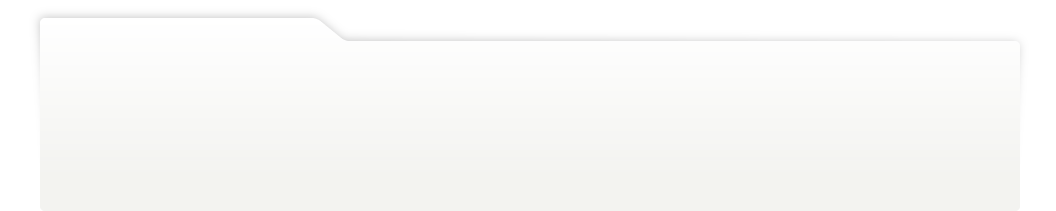
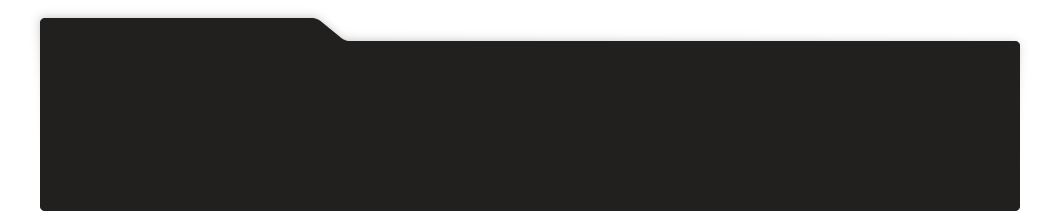
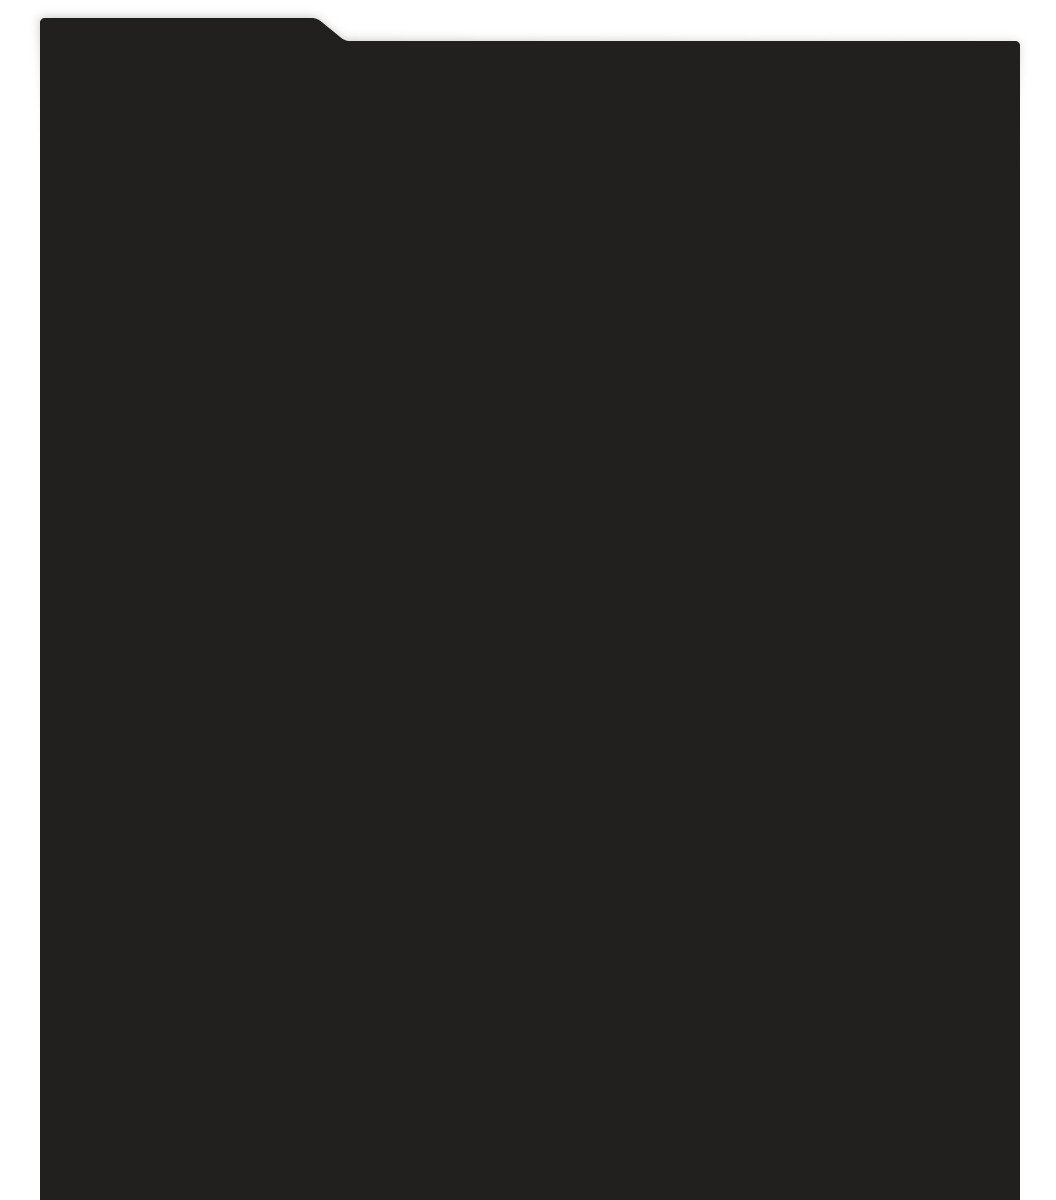
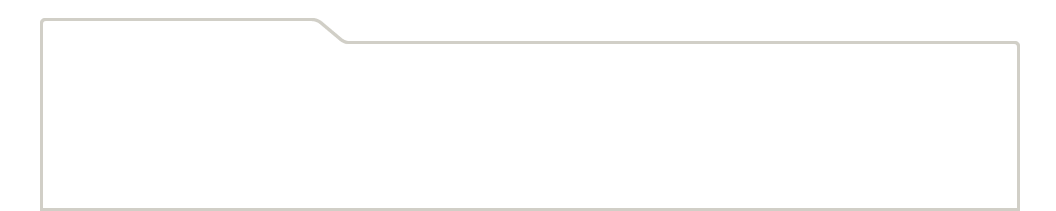
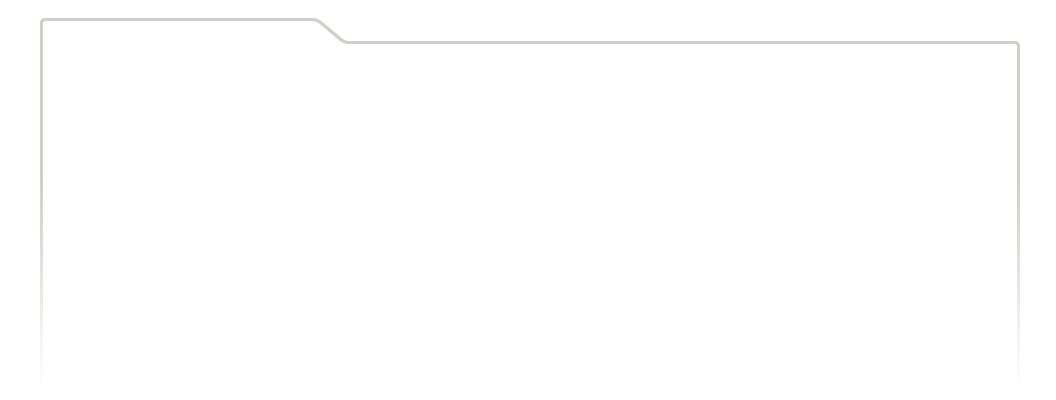
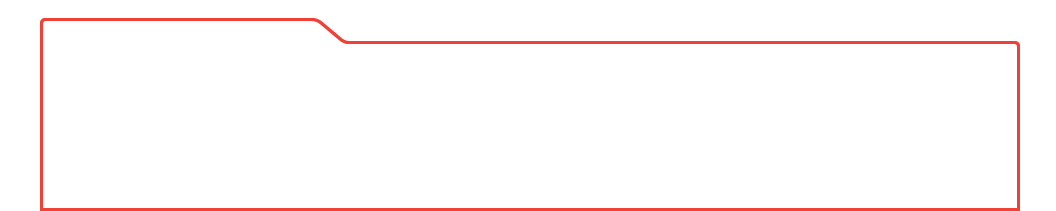
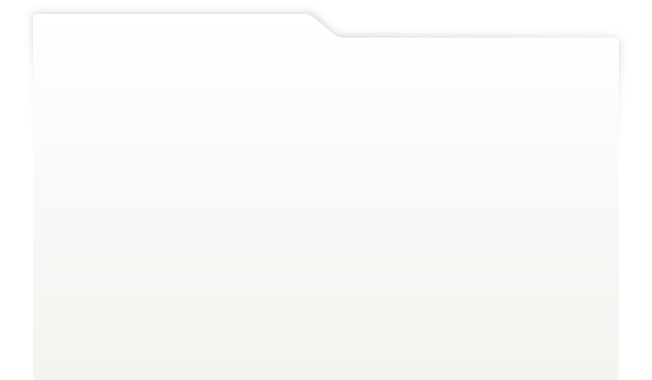
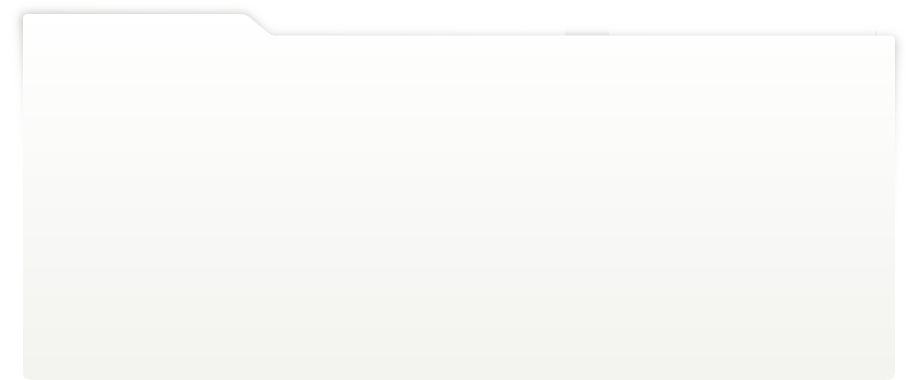
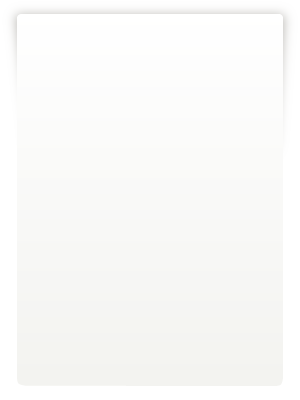
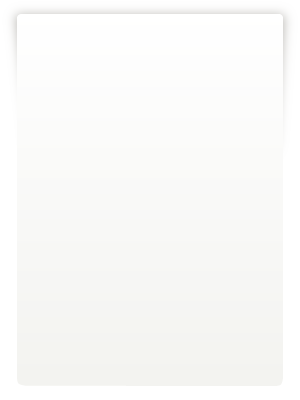
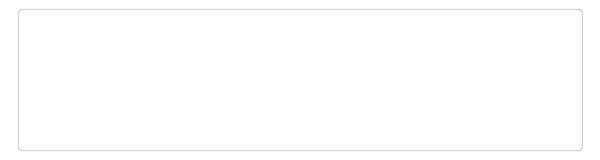
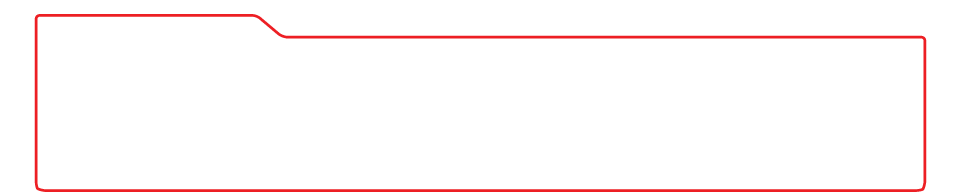
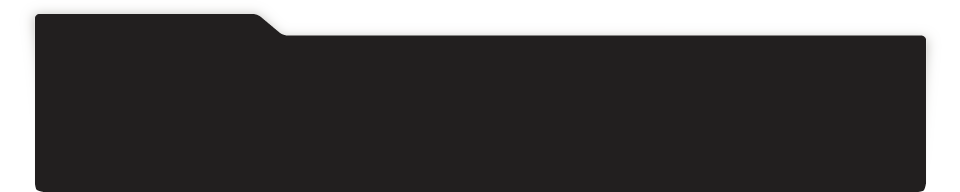
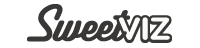
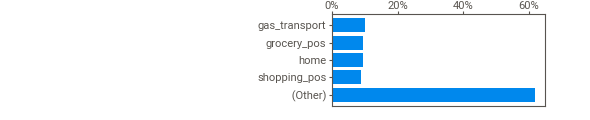
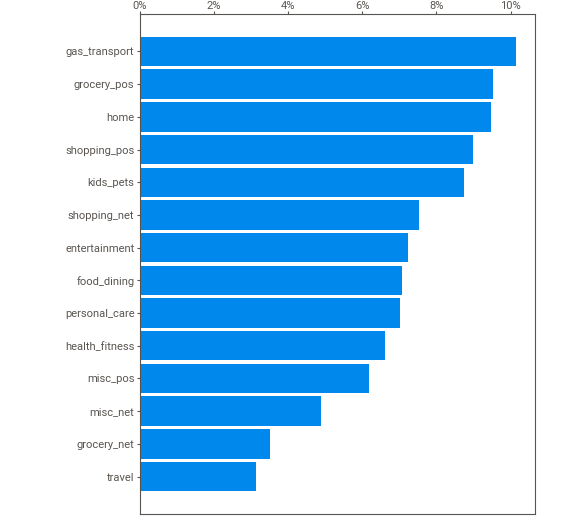
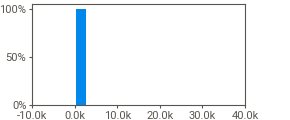
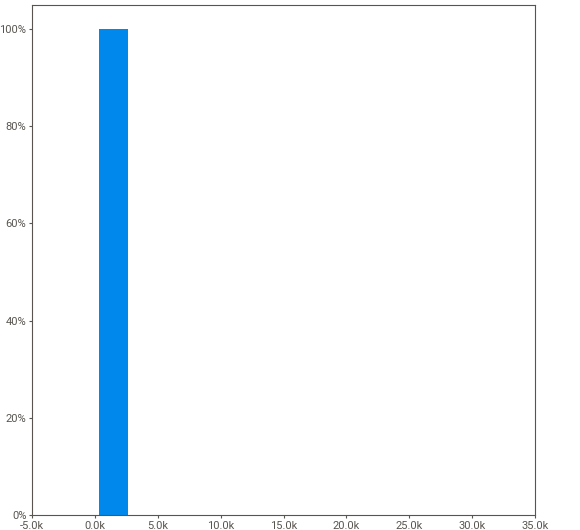
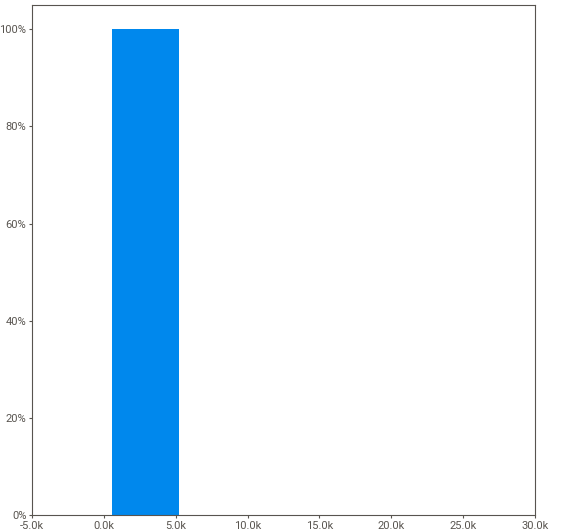
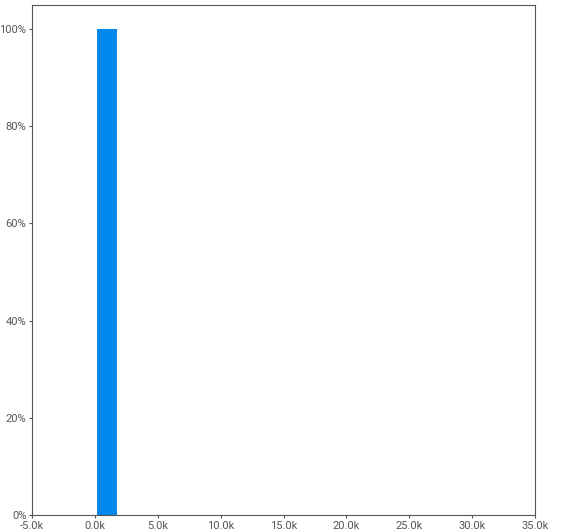
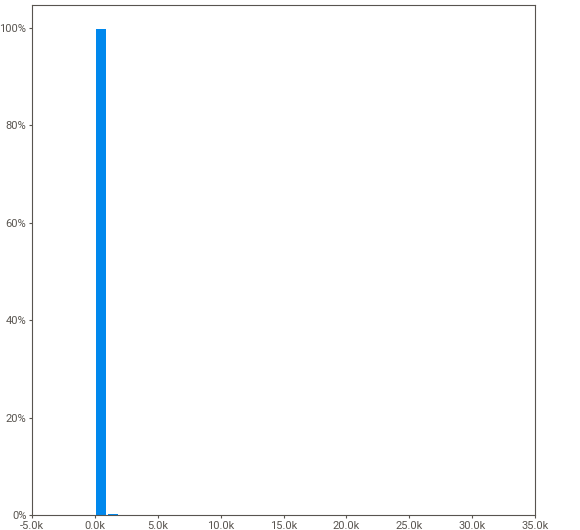
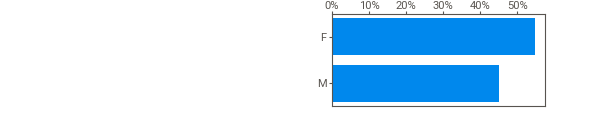
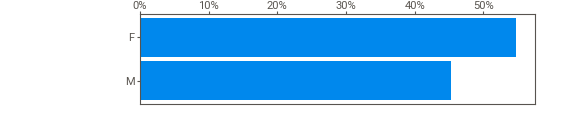
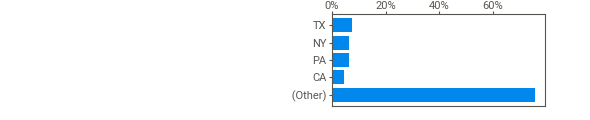
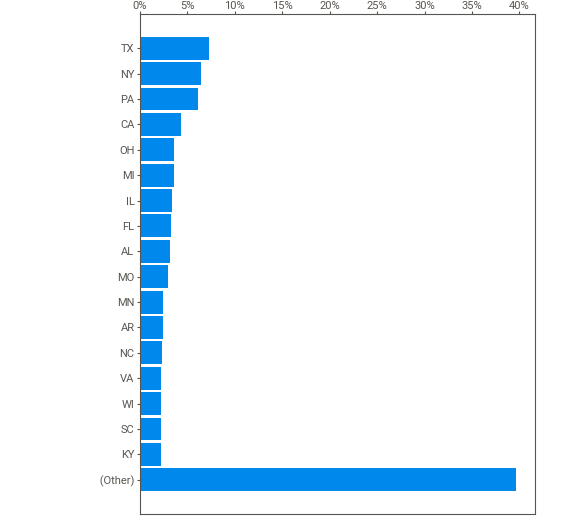
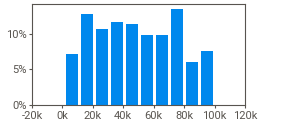
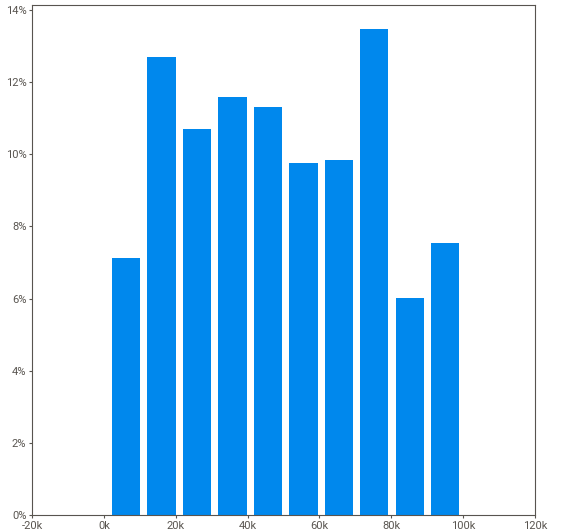
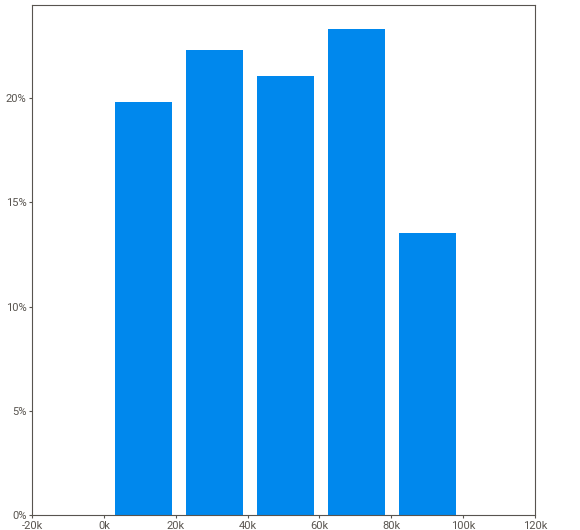
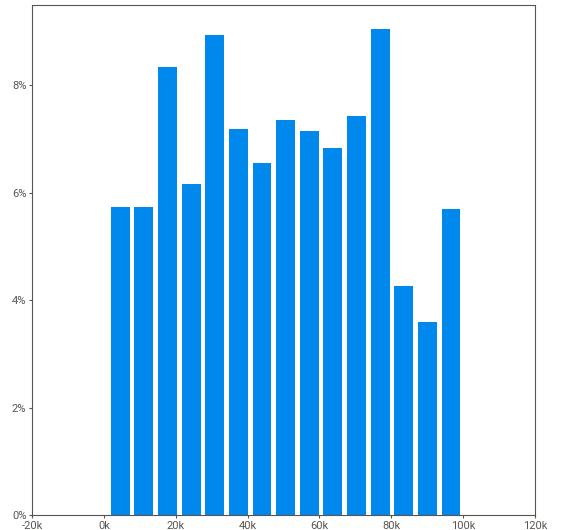
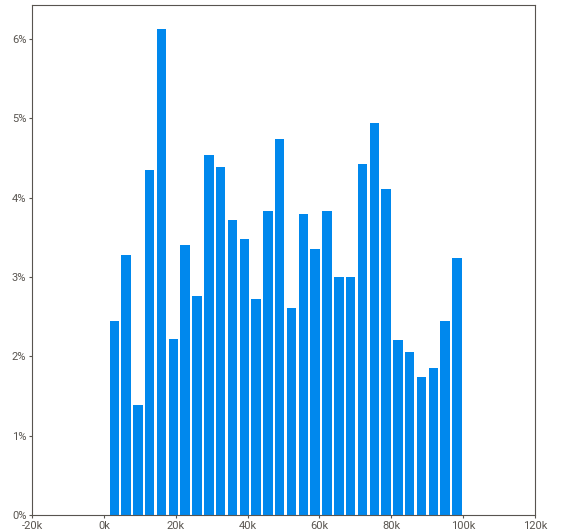
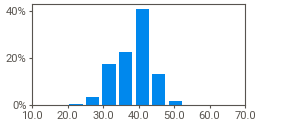
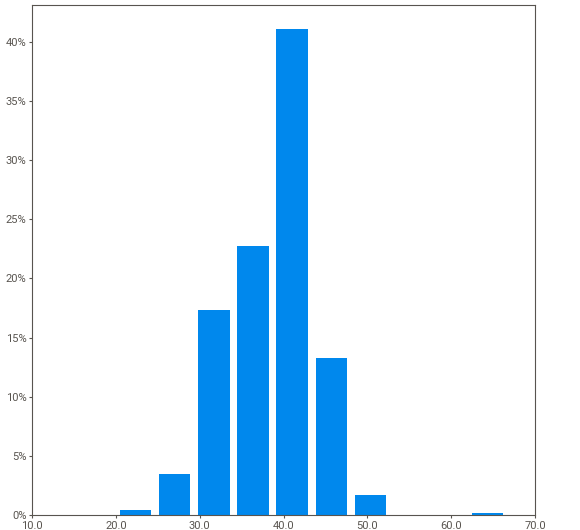
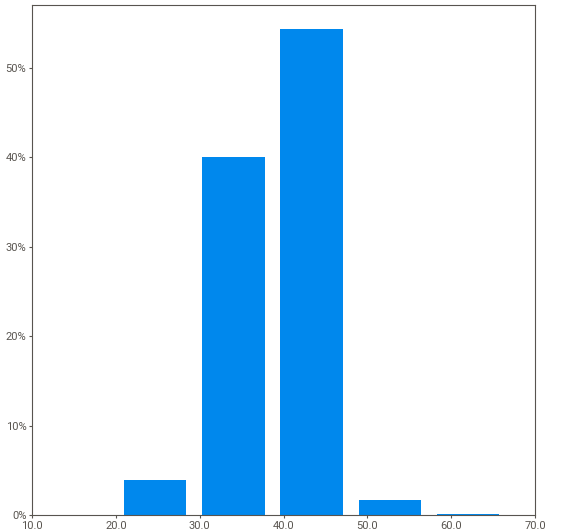
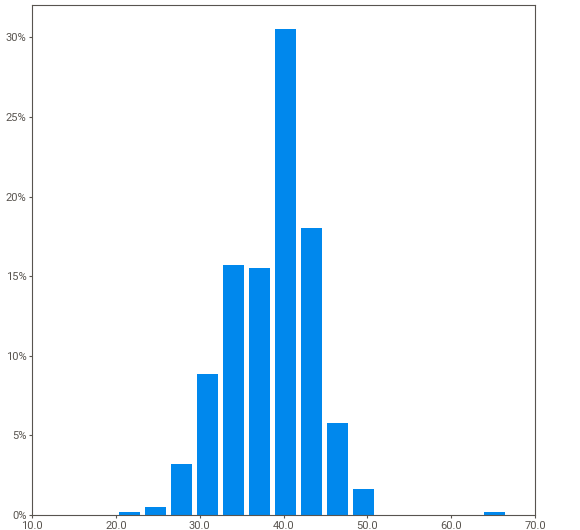
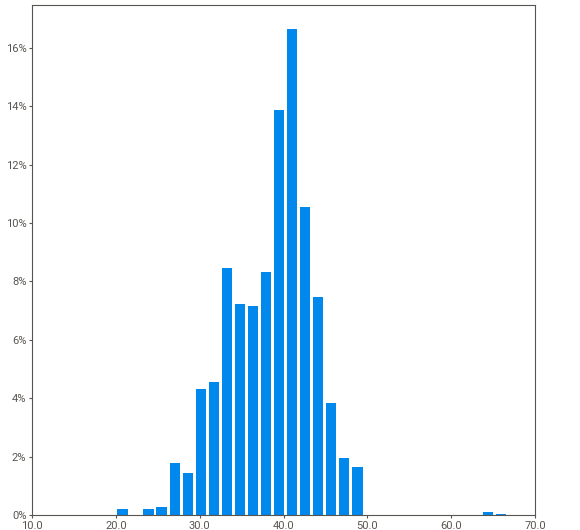
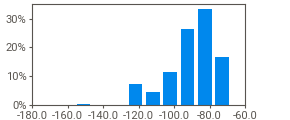
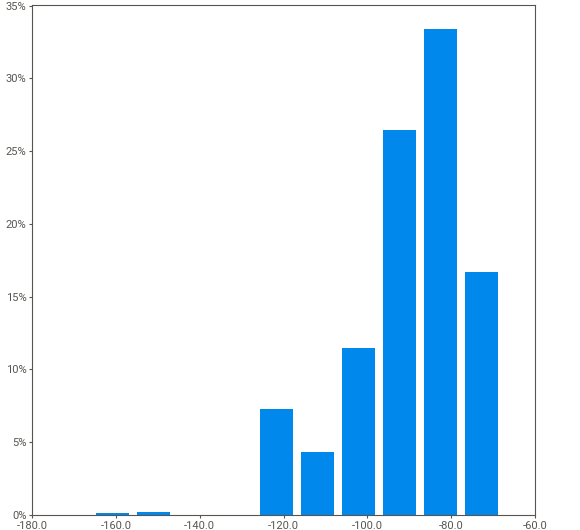
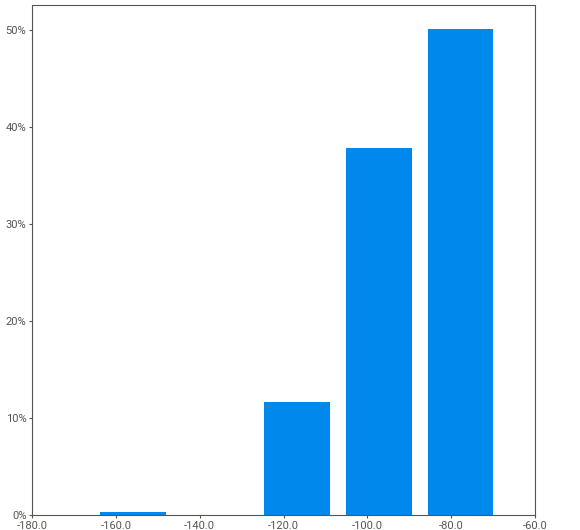
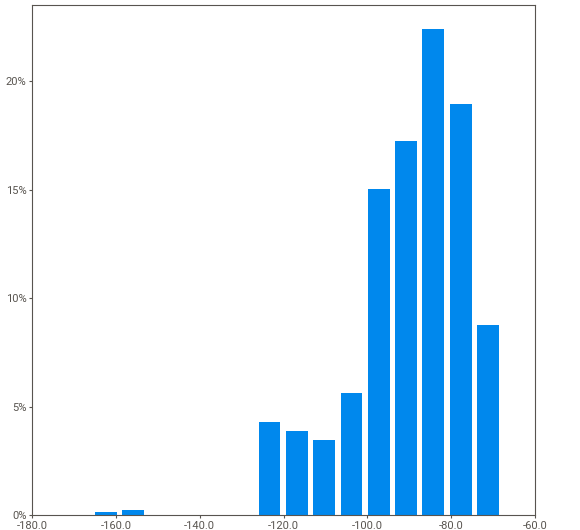
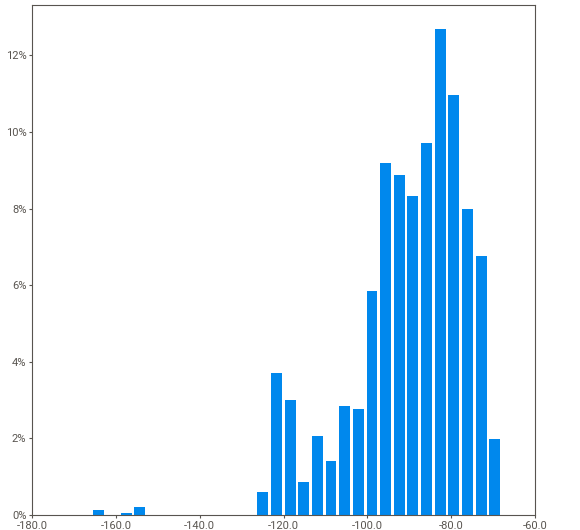
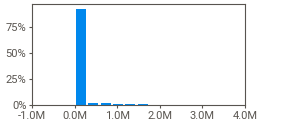
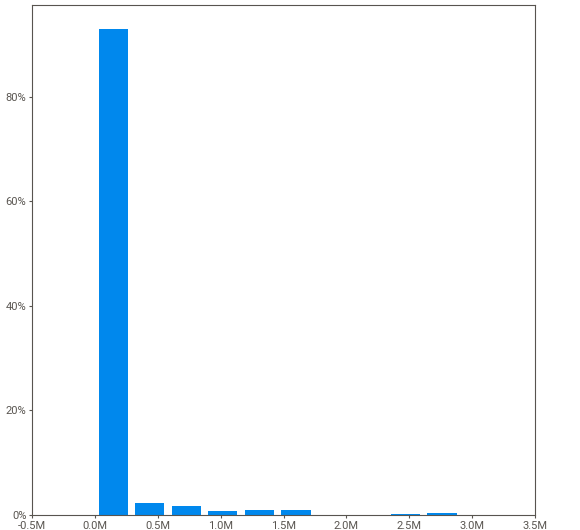
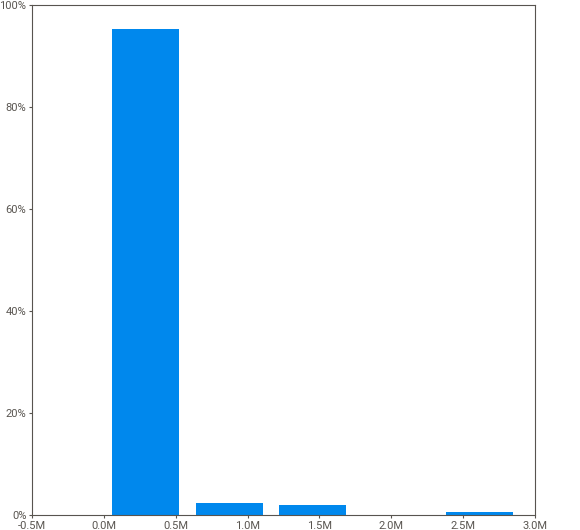
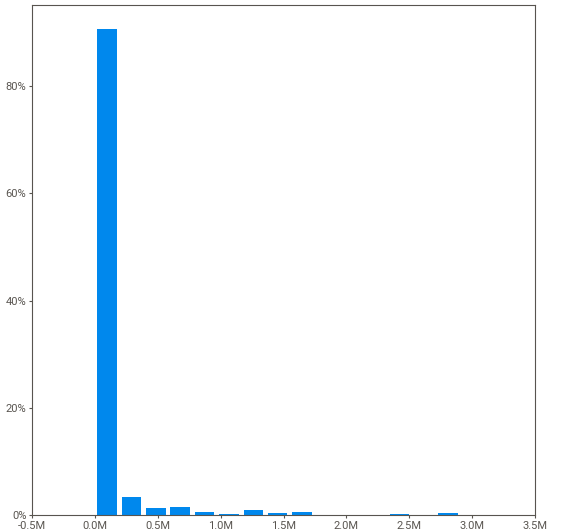
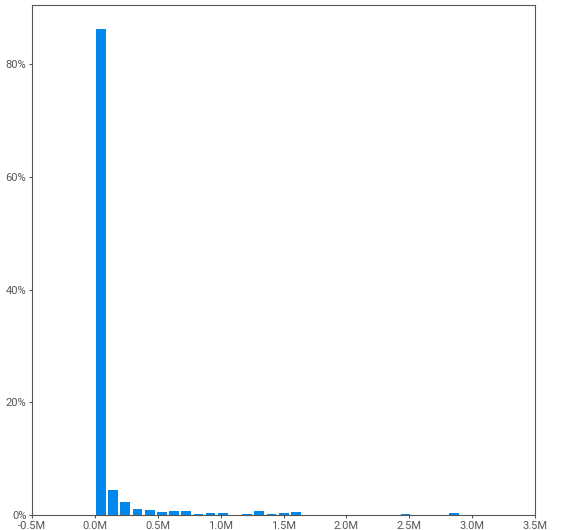
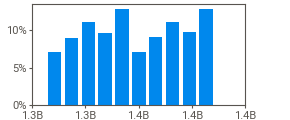
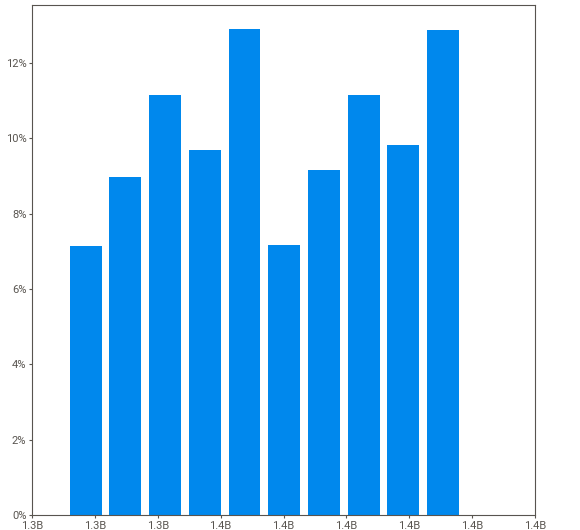
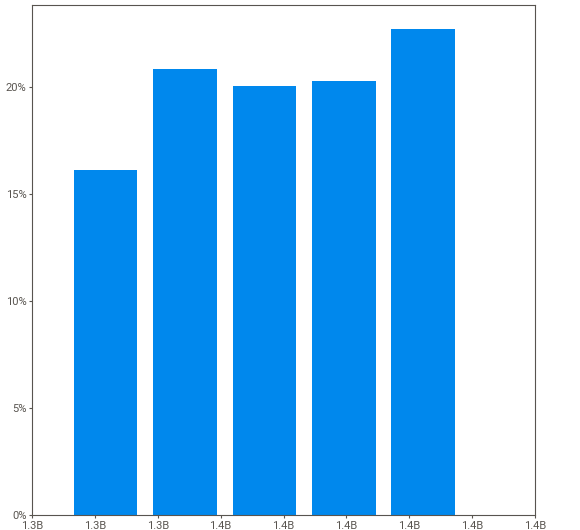
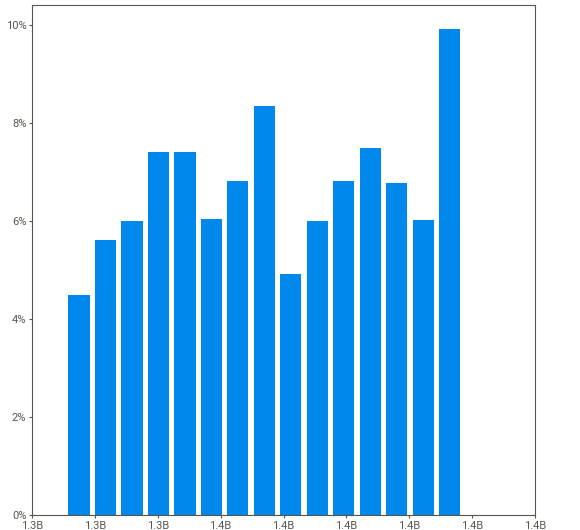
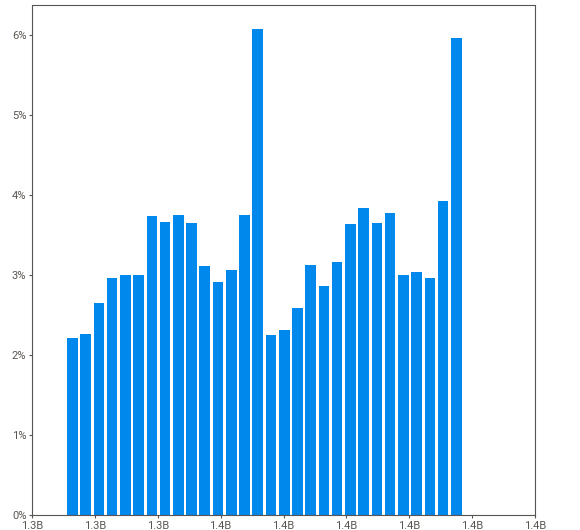
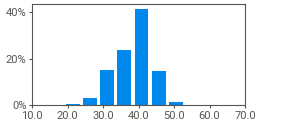
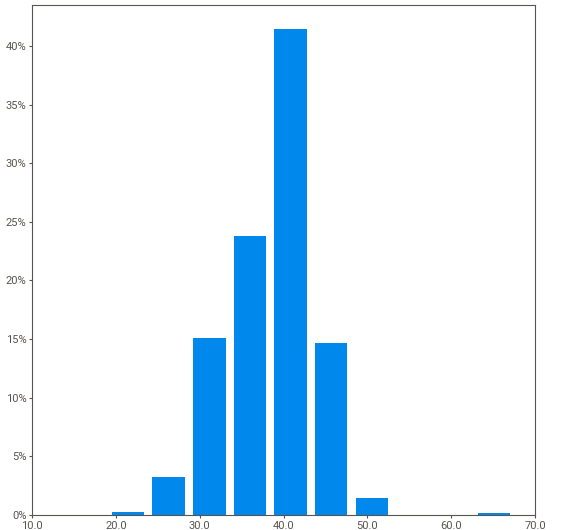
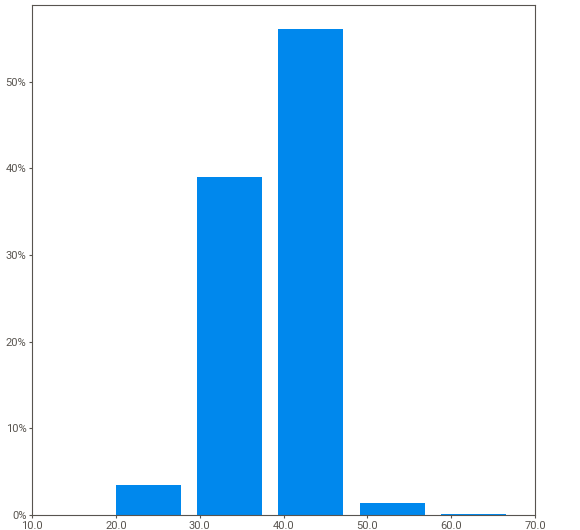
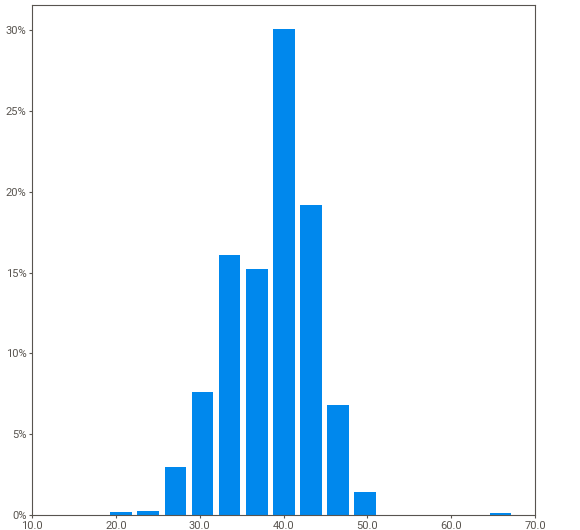
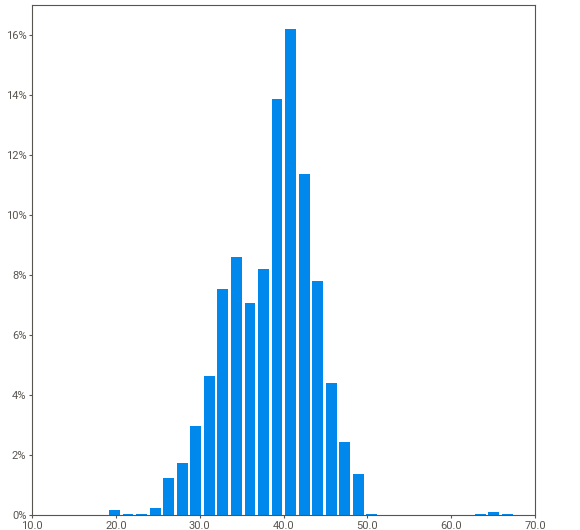
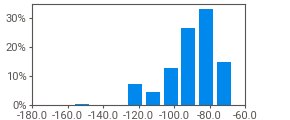
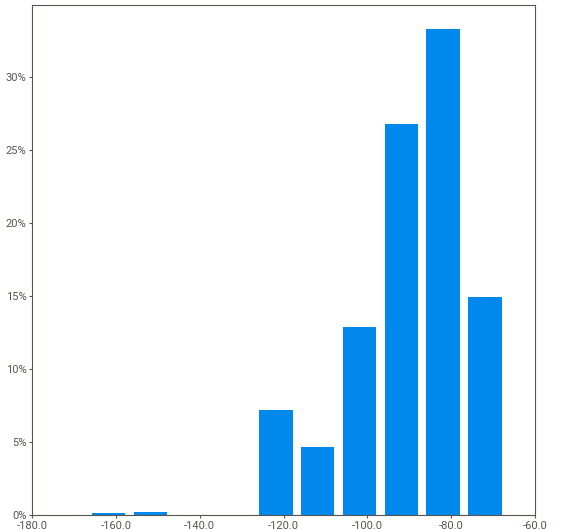
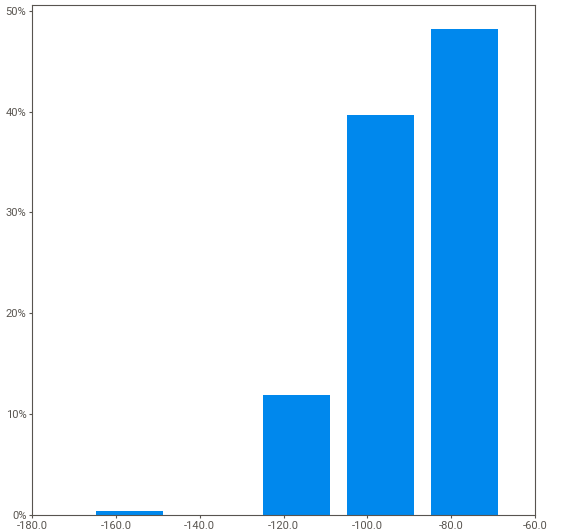
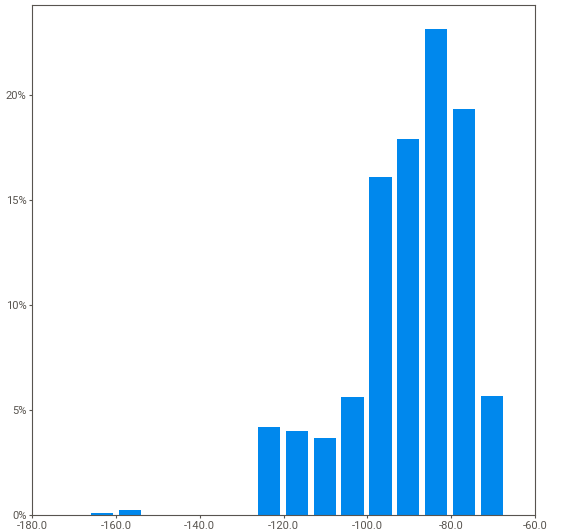
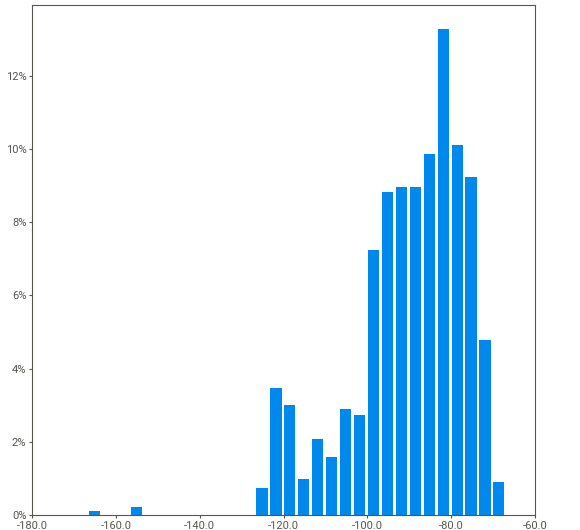
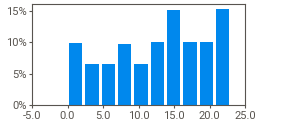
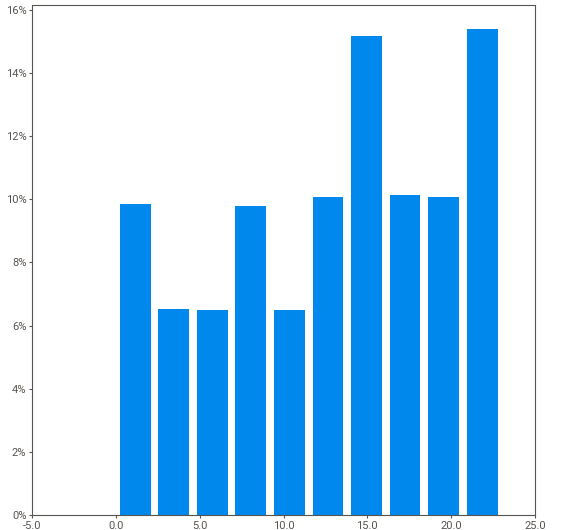
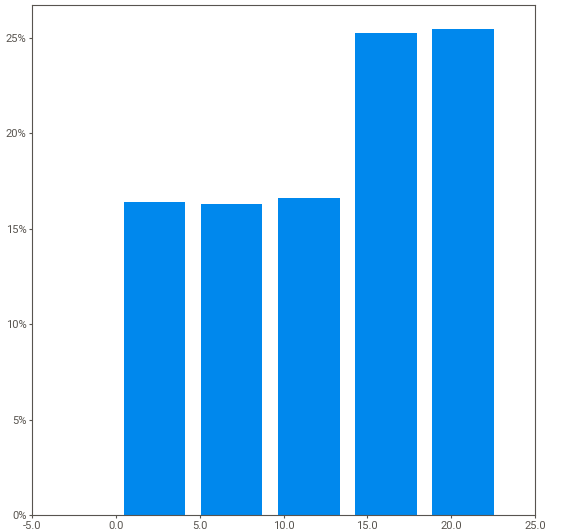
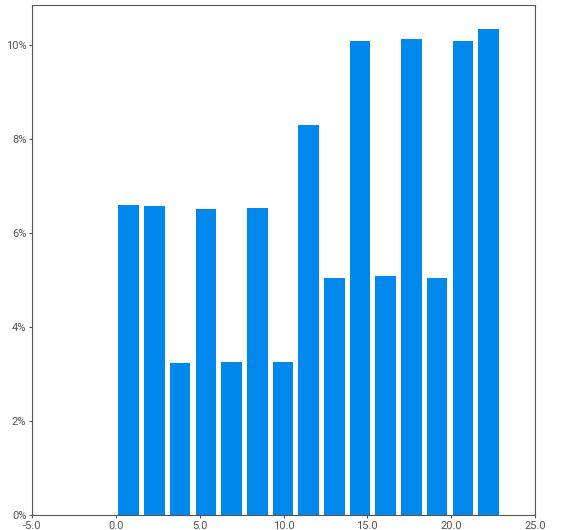
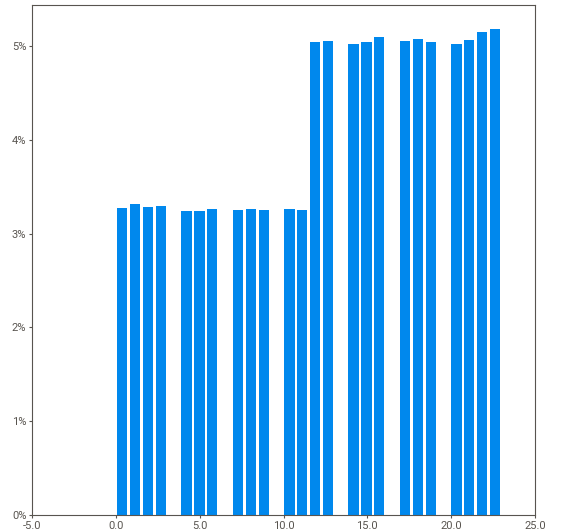
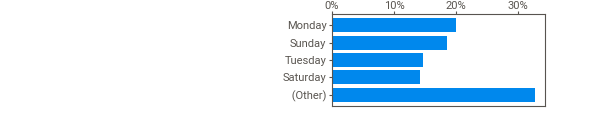
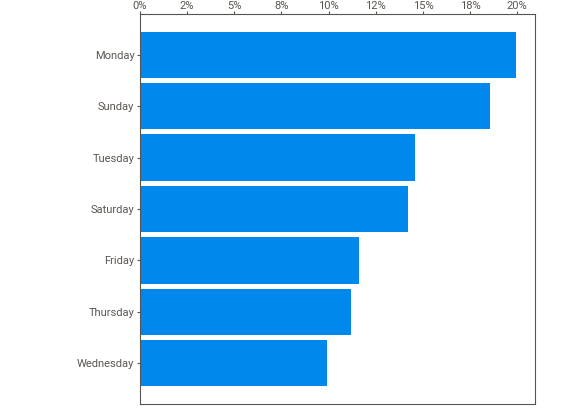
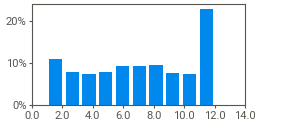
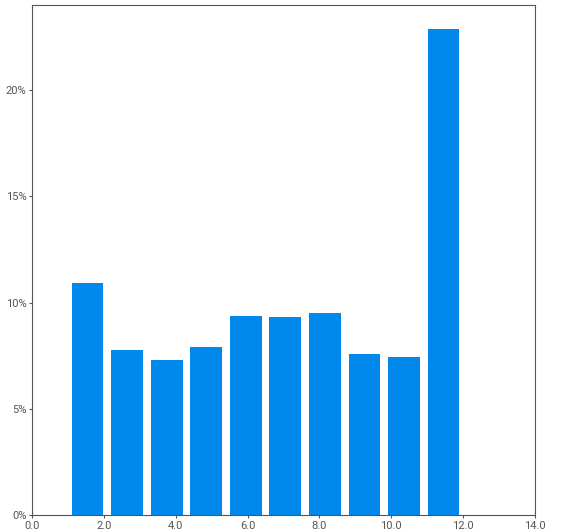
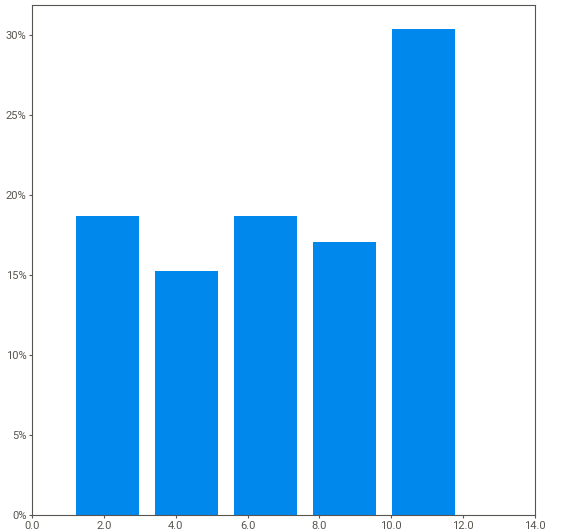
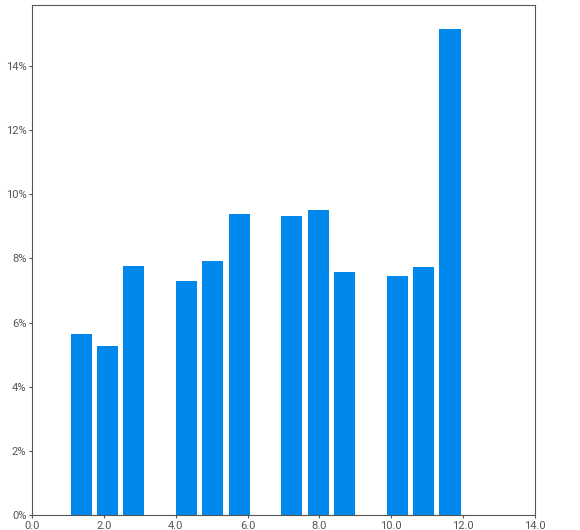
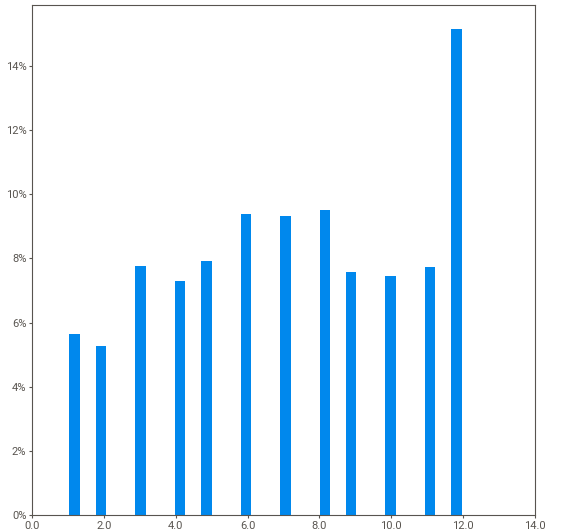
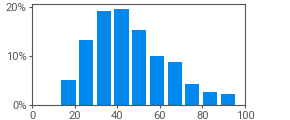
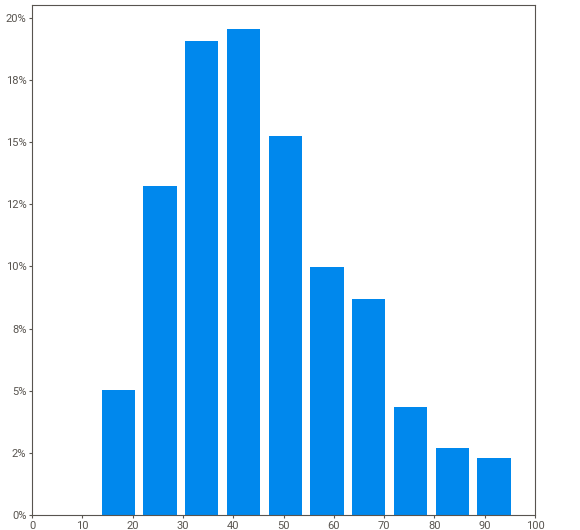
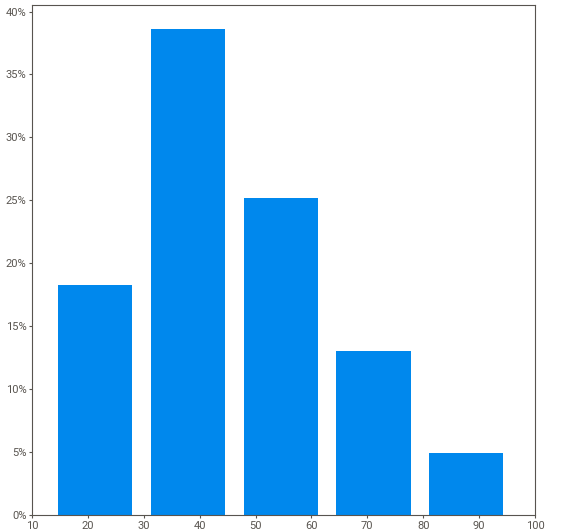
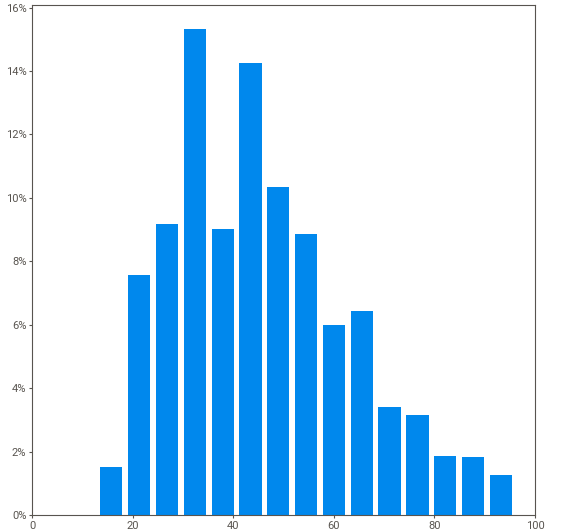
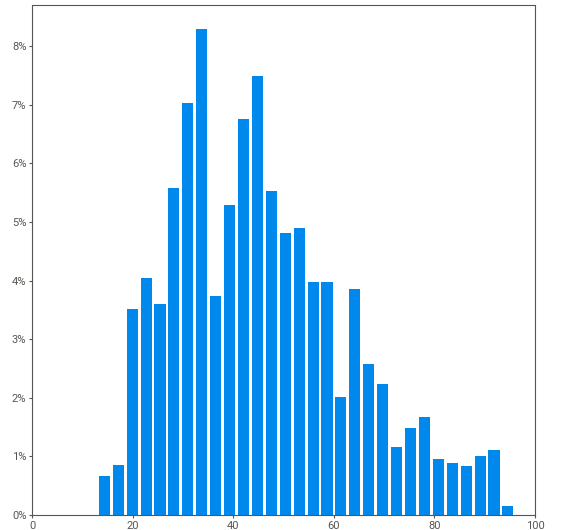
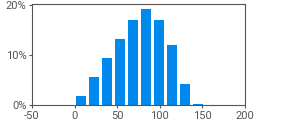
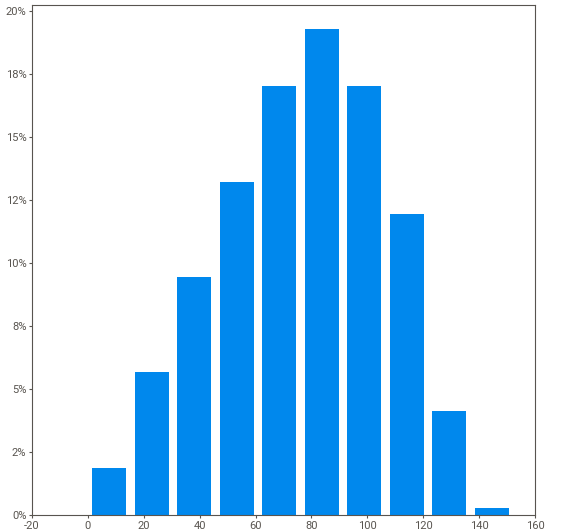
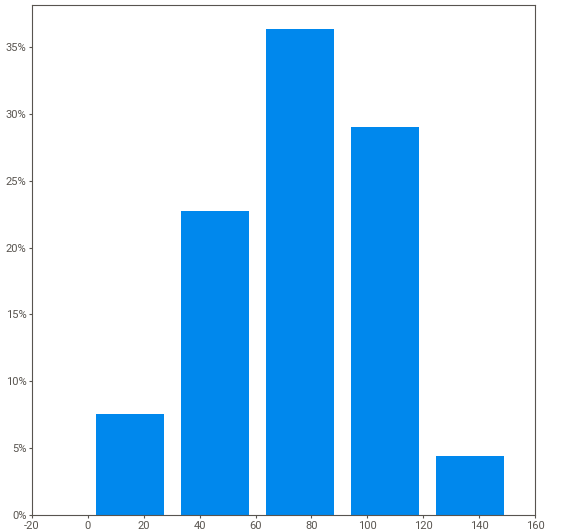
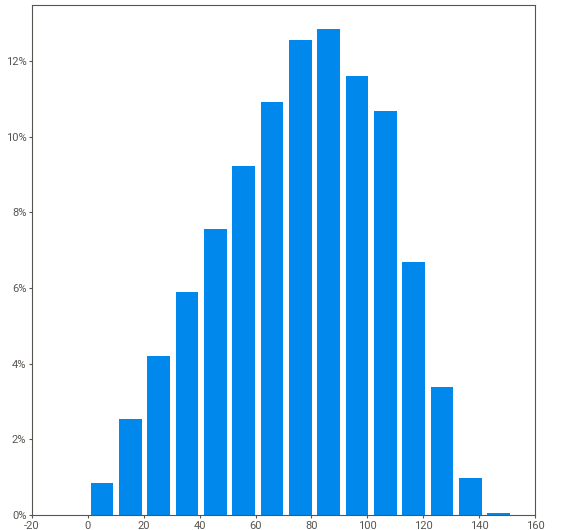
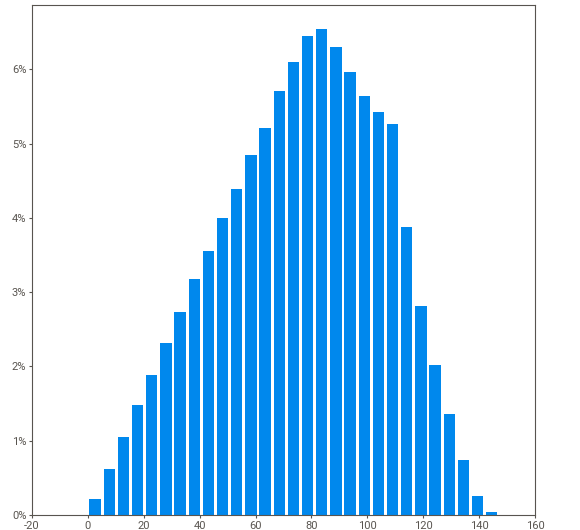
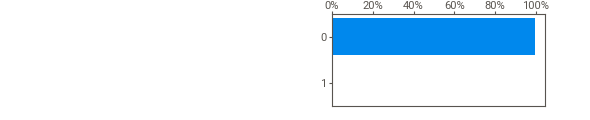
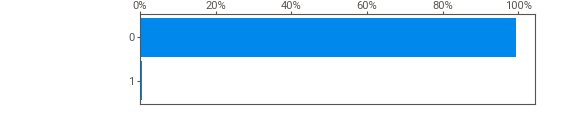
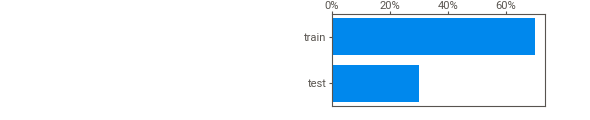
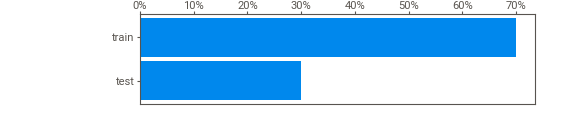
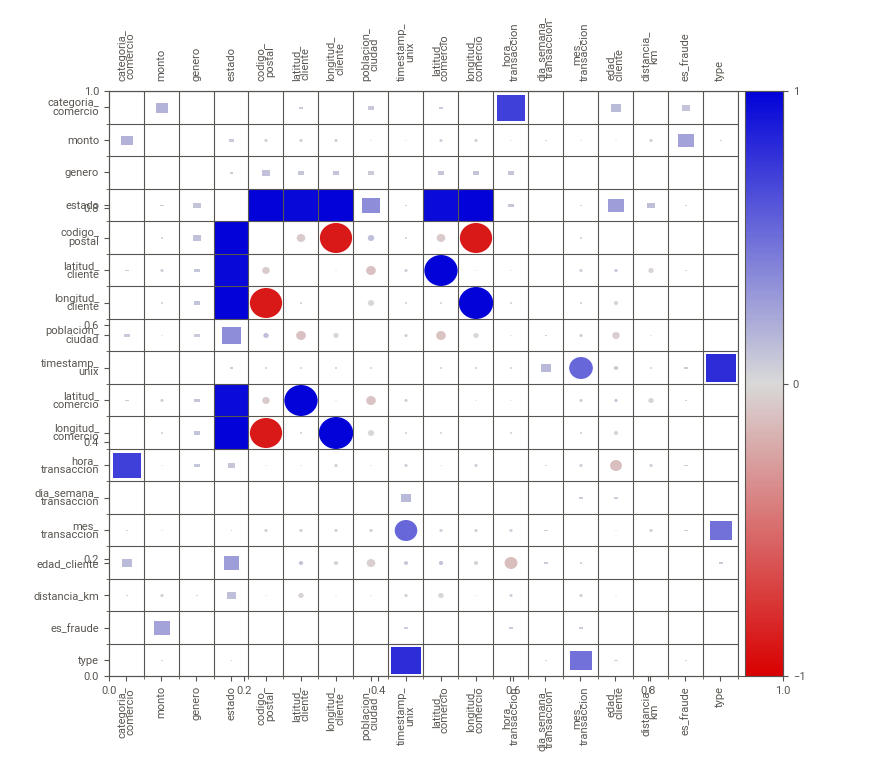
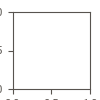

In [22]:
import sweetviz as sv

report = sv.analyze(transactions_clean_v1)
report.show_notebook()

In [23]:
from pathlib import Path

current = Path.cwd().resolve()

# Si estás en notebooks, la raíz es la carpeta anterior
project_root = current.parent

output_dir = project_root / "data" / "interim"
output_dir.mkdir(parents=True, exist_ok=True)

transactions_clean_v1.to_csv(
    output_dir / "transactions_clean_v2.csv",
    index=False
)

print(f"Archivo guardado en: {output_dir.resolve()}")

Archivo guardado en: C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\interim


# Semana 5

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

from scipy import sparse
from scipy.sparse import save_npz, hstack

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD

import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [25]:
current = Path.cwd().resolve()
print("Estoy trabajando en:", current)

# Si estás dentro de la carpeta notebooks
project_root = current.parent

input_path = project_root / "data" / "interim" / "transactions_clean_v2.csv"

print("Buscando archivo en:")
print(input_path)

if not input_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {input_path}")

df = pd.read_csv(input_path)

print("Archivo cargado correctamente")
print("Shape:", df.shape)

display(df.head())

Estoy trabajando en: C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\notebooks
Buscando archivo en:
C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\interim\transactions_clean_v2.csv
Archivo cargado correctamente
Shape: (1852394, 24)


,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,1325376018,36.01,-82.05,0,Tuesday,1,30,78.60,2095,0,train
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1325376044,49.16,-118.19,0,Tuesday,1,40,30.21,7322,0,train
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,1325376051,43.15,-112.15,0,Tuesday,1,56,108.21,7661,0,train
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,1325376076,47.03,-112.56,0,Tuesday,1,51,95.67,240,0,train
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,1325376186,38.67,-78.63,0,Tuesday,1,32,77.56,3984,0,train


In [26]:
print("Columnas disponibles:")
for col in df.columns:
    print("-", col)

# Detectar automáticamente la columna objetivo
if "es_fraude" in df.columns:
    target_col = "es_fraude"
elif "is_fraud" in df.columns:
    target_col = "is_fraud"
else:
    raise ValueError("No se encontró la columna objetivo: es_fraude o is_fraud")

print("\nTarget usado:", target_col)
print(df[target_col].value_counts())

Columnas disponibles:
- fecha_hora_transaccion
- comercio
- categoria_comercio
- monto
- genero
- ciudad
- estado
- codigo_postal
- latitud_cliente
- longitud_cliente
- poblacion_ciudad
- ocupacion
- fecha_nacimiento
- timestamp_unix
- latitud_comercio
- longitud_comercio
- hora_transaccion
- dia_semana_transaccion
- mes_transaccion
- edad_cliente
- distancia_km
- tarjeta_ultimos4
- es_fraude
- type

Target usado: es_fraude
es_fraude
0    1842743
1       9651
Name: count, dtype: int64


In [27]:
df_features = df[df["type"]=="train"].copy()

# Convertir fechas
if "fecha_hora_transaccion" in df_features.columns:
    df_features["fecha_hora_transaccion"] = pd.to_datetime(
        df_features["fecha_hora_transaccion"],
        errors="coerce"
    )

if "fecha_nacimiento" in df_features.columns:
    df_features["fecha_nacimiento"] = pd.to_datetime(
        df_features["fecha_nacimiento"],
        errors="coerce"
    )

# Crear features temporales a partir de fecha_hora_transaccion
if "fecha_hora_transaccion" in df_features.columns:
    df_features["hora_transaccion"] = df_features["fecha_hora_transaccion"].dt.hour
    df_features["dia_semana_num"] = df_features["fecha_hora_transaccion"].dt.dayofweek
    df_features["dia_semana_transaccion"] = df_features["fecha_hora_transaccion"].dt.day_name()
    df_features["mes_transaccion"] = df_features["fecha_hora_transaccion"].dt.month

# Feature: fin de semana
if "dia_semana_num" in df_features.columns:
    df_features["es_fin_de_semana"] = df_features["dia_semana_num"].isin([5, 6]).astype(int)

# Features cíclicas para hora
if "hora_transaccion" in df_features.columns:
    df_features["hora_sin"] = np.sin(2 * np.pi * df_features["hora_transaccion"] / 24)
    df_features["hora_cos"] = np.cos(2 * np.pi * df_features["hora_transaccion"] / 24)

# Features cíclicas para mes
if "mes_transaccion" in df_features.columns:
    df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes_transaccion"] / 12)
    df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes_transaccion"] / 12)

# Feature: periodo del día
def clasificar_periodo(hora):
    if pd.isna(hora):
        return "desconocido"
    elif 0 <= hora <= 5:
        return "madrugada"
    elif 6 <= hora <= 11:
        return "mañana"
    elif 12 <= hora <= 17:
        return "tarde"
    else:
        return "noche"

if "hora_transaccion" in df_features.columns:
    df_features["periodo_dia"] = df_features["hora_transaccion"].apply(clasificar_periodo)

# Feature: log del monto
if "monto" in df_features.columns:
    df_features["log_monto"] = np.log1p(df_features["monto"])

print("Shape después de feature engineering:", df_features.shape)
display(df_features.head())

Shape después de feature engineering: (1296675, 32)


,fecha_hora_transaccion,comercio,categoria_comercio,monto,genero,ciudad,estado,codigo_postal,latitud_cliente,longitud_cliente,poblacion_ciudad,ocupacion,fecha_nacimiento,timestamp_unix,latitud_comercio,longitud_comercio,hora_transaccion,dia_semana_transaccion,mes_transaccion,edad_cliente,distancia_km,tarjeta_ultimos4,es_fraude,type,dia_semana_num,es_fin_de_semana,hora_sin,hora_cos,mes_sin,mes_cos,periodo_dia,log_monto
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,1325376018,36.01,-82.05,0,Tuesday,1,30,78.60,2095,0,train,1,0,0.00,1.00,0.50,0.87,madrugada,1.79
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1325376044,49.16,-118.19,0,Tuesday,1,40,30.21,7322,0,train,1,0,0.00,1.00,0.50,0.87,madrugada,4.68
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,1325376051,43.15,-112.15,0,Tuesday,1,56,108.21,7661,0,train,1,0,0.00,1.00,0.50,0.87,madrugada,5.40
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,1325376076,47.03,-112.56,0,Tuesday,1,51,95.67,240,0,train,1,0,0.00,1.00,0.50,0.87,madrugada,3.83
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,1325376186,38.67,-78.63,0,Tuesday,1,32,77.56,3984,0,train,1,0,0.00,1.00,0.50,0.87,madrugada,3.76


Regarding time features, we chose cyclical time features for hour and month using sine and cosine transforms. Because hour and month “wrap around” (23 is close to 0; December is close to January), treating them as plain integers can mislead models. The code maps hour and month onto a circle via

- $hora\_sin = \sin\!\left(2\pi \cdot \frac{hora}{24}\right)$ and $hora\_cos = \cos\!\left(2\pi \cdot \frac{hora}{24}\right)$  
- $mes\_sin = \sin\!\left(2\pi \cdot \frac{mes}{12}\right)$ and $mes\_cos = \cos\!\left(2\pi \cdot \frac{mes}{12}\right)$ 

 using both sine and cosine preserves the circular structure (each time point maps to a unique position on the unit circle), which often helps linear models and tree-based models learn smooth periodic patterns without creating an artificial “gap” at the boundary

In [28]:
MAX_ROWS = 15000
MAX_FRAUD = 1500

df_features[target_col] = pd.to_numeric(df_features[target_col], errors="coerce")

df_valid = df_features.dropna(subset=[target_col]).copy()
df_valid[target_col] = df_valid[target_col].astype(int)

if len(df_valid) > MAX_ROWS:
    df_fraud = df_valid[df_valid[target_col] == 1]
    df_normal = df_valid[df_valid[target_col] == 0]
    
    n_fraud = min(len(df_fraud), MAX_FRAUD)
    n_normal = min(len(df_normal), MAX_ROWS - n_fraud)
    
    df_model = pd.concat([
        df_fraud.sample(n=n_fraud, random_state=RANDOM_STATE),
        df_normal.sample(n=n_normal, random_state=RANDOM_STATE)
    ])
    
    df_model = df_model.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model = df_valid.copy().reset_index(drop=True)

y = df_model[target_col].values

print("Shape de muestra usada:", df_model.shape)
print("Distribución del target:")
print(df_model[target_col].value_counts())

Shape de muestra usada: (15000, 32)
Distribución del target:
es_fraude
0    13500
1     1500
Name: count, dtype: int64


In [29]:
numeric_candidates = [
    "monto",
    "log_monto",
    "codigo_postal",
    #"latitud_cliente",
    #"longitud_cliente",
    "poblacion_ciudad",
    #"latitud_comercio",
    #"longitud_comercio",
    "timestamp_unix",
    "hora_transaccion",
    "dia_semana_num",
    "mes_transaccion",
    "edad_cliente",
    "distancia_km",
    "es_fin_de_semana",
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",
    "es_fraude"  
]

categorical_candidates = [
    "genero",
    "categoria_comercio",
    #"ciudad",
    "estado",
    "dia_semana_transaccion",
    "periodo_dia",
    #"type"
]

#text_feature = "texto_comercio_ocupacion"

numeric_features = [c for c in numeric_candidates if c in df_model.columns]
categorical_features = [c for c in categorical_candidates if c in df_model.columns]

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

#print("\nVariable de texto:")
#print(text_feature)

Variables numéricas:
['monto', 'log_monto', 'codigo_postal', 'poblacion_ciudad', 'timestamp_unix', 'hora_transaccion', 'dia_semana_num', 'mes_transaccion', 'edad_cliente', 'distancia_km', 'es_fin_de_semana', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'es_fraude']

Variables categóricas:
['genero', 'categoria_comercio', 'estado', 'dia_semana_transaccion', 'periodo_dia']


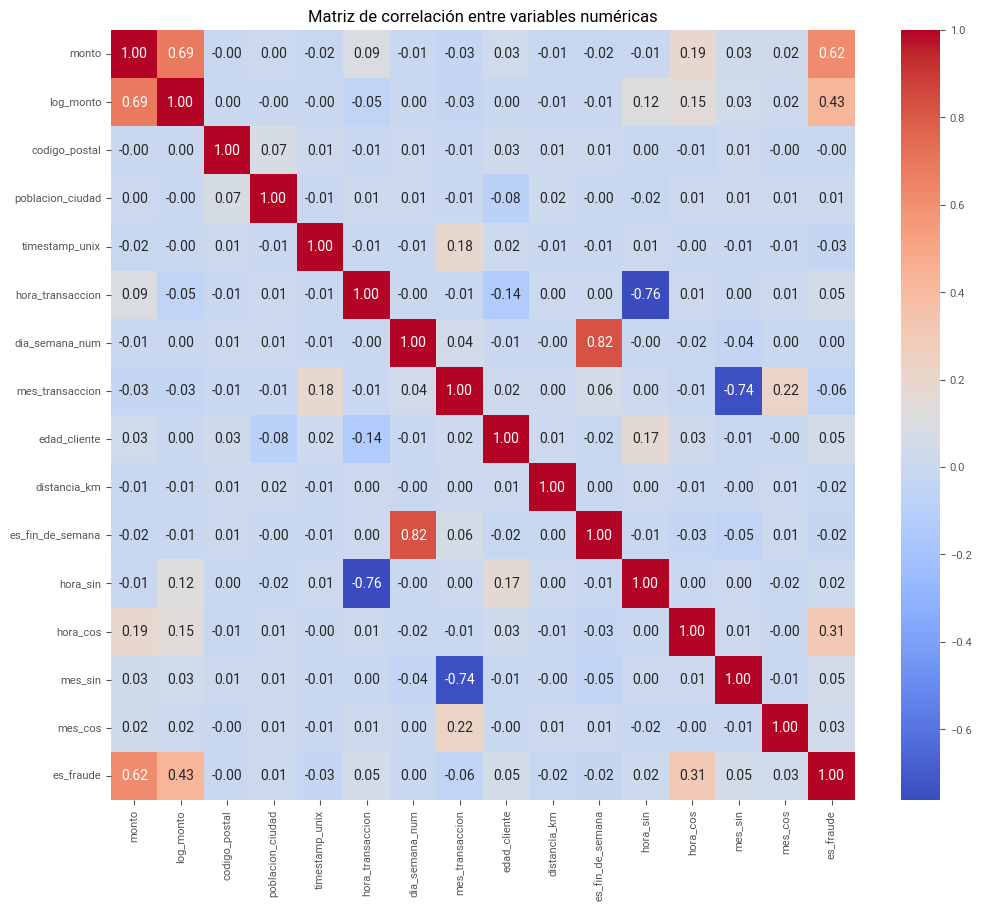

In [30]:
## Correlation matrix
import seaborn as sns   
correlation_matrix = df_model.loc[:,numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,          # Annotate cells
            fmt=".2f",           # 2 decimal places
            cmap='coolwarm',     # Color scheme
            annot_kws={"size": 10}) # Font size

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

By analyzing the correlation matrix, we can gain insights into which features are most informative for the dependent variable “es_fraude.” In this case, we observe that “monto” has a strong correlation with the target variable, which makes sense since fraudulent transactions are often associated with higher amounts.

On the other hand, correlation analysis can also help us identify redundant features. For example, “es_fin_de_semana” shows a high correlation with “dia_de_semana_num,” indicating that both variables capture similar information. This redundancy suggests that one of them can be removed, selecting the feature that contributes more effectively to the model.

This process is important for several reasons, including reducing redundancy, avoiding unnecessary complexity, and improving model interpretability.

## OnehotEncoding

In [31]:
def crear_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", crear_onehot_encoder())
])

text_pipeline = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=300,
        min_df=2,
        ngram_range=(1, 2)
    ))
])
numeric_features = numeric_features[:numeric_features.index("es_fraude")] # Eliminar la variable objetivo para la visualización
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        #("text", text_pipeline, text_feature)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_features = preprocessor.fit_transform(df_model)

print("Matriz final X_features:", X_features.shape)
print("Tipo de matriz:", type(X_features))

Matriz final X_features: (15000, 93)
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>


In [32]:
X_numeric = preprocessor.named_transformers_["numeric"].transform(df_model[numeric_features])
X_categorical = preprocessor.named_transformers_["categorical"].transform(df_model[categorical_features])
#X_text = preprocessor.named_transformers_["text"].transform(df_model[text_feature])

print("Matriz numérica:", X_numeric.shape)
print("Matriz categórica:", X_categorical.shape)
#print("Matriz texto:", X_text.shape)
print("Matriz completa:", X_features.shape)

Matriz numérica: (15000, 15)
Matriz categórica: (15000, 78)
Matriz completa: (15000, 93)


In [33]:
feature_names = preprocessor.get_feature_names_out()

feature_names_df = pd.DataFrame({
    "feature": feature_names
})

print("Cantidad total de features:", len(feature_names_df))
display(feature_names_df.head(20))

Cantidad total de features: 93


,feature
0,numeric__monto
1,numeric__log_monto
2,numeric__codigo_postal
3,numeric__poblacion_ciudad
4,numeric__timestamp_unix
5,numeric__hora_transaccion
6,numeric__dia_semana_num
7,numeric__mes_transaccion
8,numeric__edad_cliente
9,numeric__distancia_km


## Dimensionality reduction

In [34]:
max_pca_components = min(20, X_numeric.shape[1], X_numeric.shape[0] - 1)

pca_model = PCA(n_components=max_pca_components, random_state=RANDOM_STATE)
X_pca = pca_model.fit_transform(X_numeric)

pca_explained = pca_model.explained_variance_ratio_
pca_cumulative = np.cumsum(pca_explained)

print("Shape PCA:", X_pca.shape)

pca_results = pd.DataFrame({
    "componente": range(1, len(pca_explained) + 1),
    "varianza_explicada": pca_explained,
    "varianza_acumulada": pca_cumulative
})

display(pca_results)

Shape PCA: (15000, 15)


,componente,varianza_explicada,varianza_acumulada
0,1,0.13,0.13
1,2,0.12,0.25
2,3,0.12,0.37
3,4,0.11,0.48
4,5,0.07,0.55
5,6,0.07,0.62
6,7,0.07,0.69
7,8,0.07,0.76
8,9,0.06,0.82
9,10,0.06,0.88


In [35]:
max_svd_components = min(50, X_features.shape[1] - 1, X_features.shape[0] - 1)

svd_model = TruncatedSVD(n_components=max_svd_components, random_state=RANDOM_STATE)
X_svd = svd_model.fit_transform(X_features)

svd_explained = svd_model.explained_variance_ratio_
svd_cumulative = np.cumsum(svd_explained)

print("Shape SVD:", X_svd.shape)

svd_results = pd.DataFrame({
    "componente": range(1, len(svd_explained) + 1),
    "energia_retenida": svd_explained,
    "energia_acumulada": svd_cumulative
})

display(svd_results.head(20))

Shape SVD: (15000, 50)


,componente,energia_retenida,energia_acumulada
0,1,0.11,0.11
1,2,0.11,0.22
2,3,0.10,0.32
3,4,0.09,0.41
4,5,0.06,0.47
5,6,0.06,0.52
6,7,0.04,0.56
7,8,0.02,0.58
8,9,0.05,0.63
9,10,0.05,0.68


In [36]:
componentes_a_comparar = [2, 5, 10, 20, 50]

comparison_rows = []

# PCA numérico
for k in componentes_a_comparar:
    if k <= max_pca_components:
        pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
        Z = pca_k.fit_transform(X_numeric)
        X_rec = pca_k.inverse_transform(Z)
        
        reconstruction_error = (
            np.linalg.norm(X_numeric - X_rec) / np.linalg.norm(X_numeric)
        )
        
        comparison_rows.append({
            "metodo": "PCA - solo numéricas",
            "componentes": k,
            "varianza_o_energia_acumulada": pca_k.explained_variance_ratio_.sum(),
            "error_reconstruccion_relativo": reconstruction_error,
            "matriz_usada": "X_numeric"
        })

# SVD matriz completa
if sparse.issparse(X_features):
    X_features_dense = X_features.toarray()
else:
    X_features_dense = np.asarray(X_features)

norm_X_features = np.linalg.norm(X_features_dense)

for k in componentes_a_comparar:
    if k <= max_svd_components:
        svd_k = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
        Z = svd_k.fit_transform(X_features)
        X_rec = svd_k.inverse_transform(Z)
        
        reconstruction_error = (
            np.linalg.norm(X_features_dense - X_rec) / norm_X_features
        )
        
        comparison_rows.append({
            "metodo": "SVD - matriz completa",
            "componentes": k,
            "varianza_o_energia_acumulada": svd_k.explained_variance_ratio_.sum(),
            "error_reconstruccion_relativo": reconstruction_error,
            "matriz_usada": "X_features"
        })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

,metodo,componentes,varianza_o_energia_acumulada,error_reconstruccion_relativo,matriz_usada
0,PCA - solo numéricas,2,0.25,0.87,X_numeric
1,PCA - solo numéricas,5,0.55,0.67,X_numeric
2,PCA - solo numéricas,10,0.88,0.34,X_numeric
3,SVD - matriz completa,2,0.22,0.89,X_features
4,SVD - matriz completa,5,0.47,0.75,X_features
5,SVD - matriz completa,10,0.68,0.55,X_features
6,SVD - matriz completa,20,0.89,0.32,X_features
7,SVD - matriz completa,50,0.98,0.15,X_features


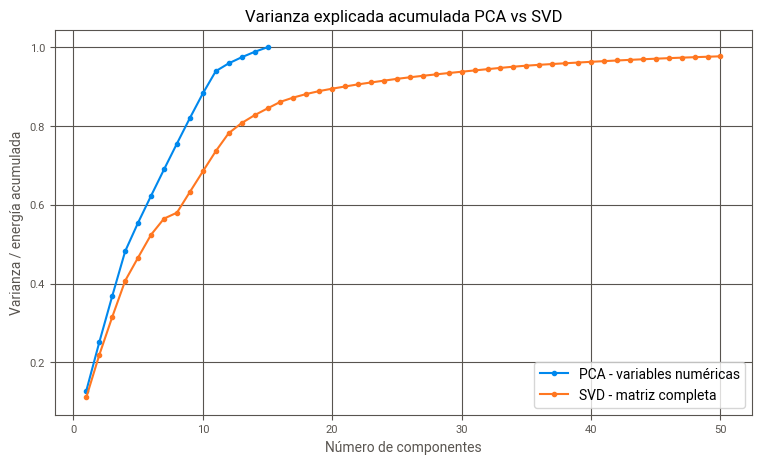

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(pca_cumulative) + 1),
    pca_cumulative,
    marker="o",
    label="PCA - variables numéricas"
)

plt.plot(
    range(1, len(svd_cumulative) + 1),
    svd_cumulative,
    marker="o",
    label="SVD - matriz completa"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza / energía acumulada")
plt.title("Varianza explicada acumulada PCA vs SVD")
plt.legend()
plt.grid(True)
plt.show()

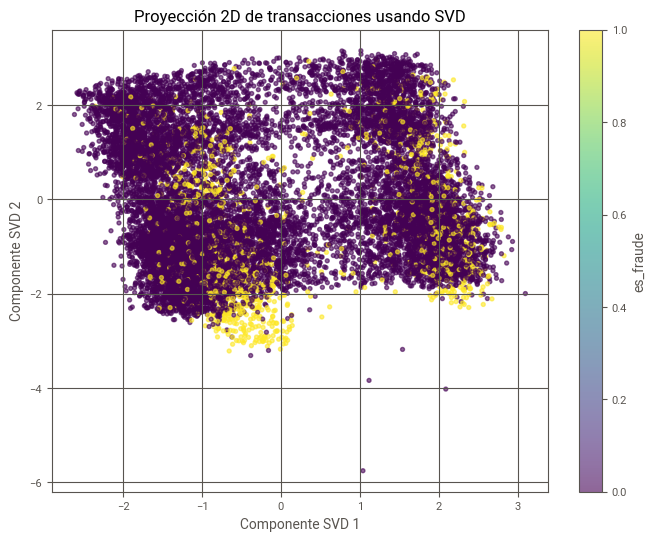

In [38]:
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_svd_2d = svd_2d.fit_transform(X_features)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_svd_2d[:, 0],
    X_svd_2d[:, 1],
    c=y,
    s=8,
    alpha=0.6
)

plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.title("Proyección 2D de transacciones usando SVD")
plt.colorbar(scatter, label=target_col)
plt.grid(True)
plt.show()

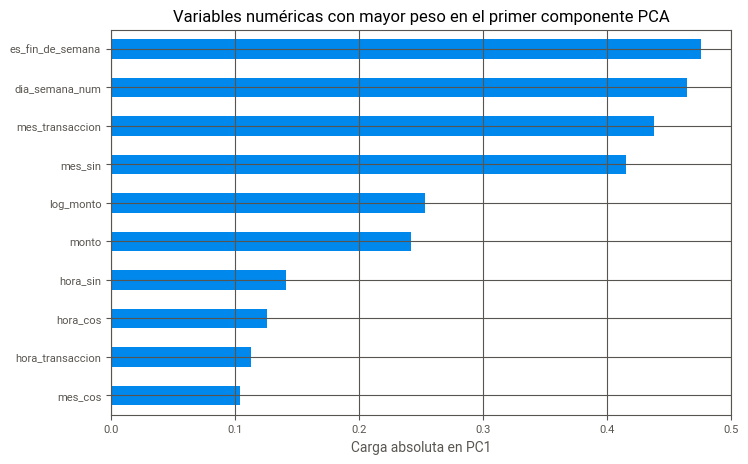

es_fin_de_semana   0.48
dia_semana_num     0.47
mes_transaccion    0.44
mes_sin            0.42
log_monto          0.25
monto              0.24
hora_sin           0.14
hora_cos           0.13
hora_transaccion   0.11
mes_cos            0.10
dtype: float64

In [39]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2.fit(X_numeric)

loadings_pc1 = pd.Series(
    np.abs(pca_2.components_[0]),
    index=numeric_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

loadings_pc1.head(10).sort_values().plot(kind="barh")

plt.xlabel("Carga absoluta en PC1")
plt.title("Variables numéricas con mayor peso en el primer componente PCA")
plt.grid(True)
plt.show()

display(loadings_pc1.head(10))

In [40]:
output_dir = project_root / "data" / "week5"
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar matriz completa
if sparse.issparse(X_features):
    save_npz(output_dir / "X_features_week5.npz", X_features)
else:
    np.save(output_dir / "X_features_week5.npy", X_features)

# Guardar target
pd.DataFrame({target_col: y}).to_csv(
    output_dir / "y_week5.csv",
    index=False
)

# Guardar nombres de features
feature_names_df.to_csv(
    output_dir / "feature_names_week5.csv",
    index=False
)

# Guardar tabla comparativa
comparison_df.to_csv(
    output_dir / "dimensionality_comparison_week5.csv",
    index=False
)

print("Entregables guardados en:")
print(output_dir.resolve())

Entregables guardados en:
C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\week5


In [41]:
best_pca = comparison_df[comparison_df["metodo"] == "PCA - solo numéricas"].sort_values("componentes").tail(1)
best_svd = comparison_df[comparison_df["metodo"] == "SVD - matriz completa"].sort_values("componentes").tail(1)

pca_componentes = int(best_pca["componentes"].iloc[0])
pca_varianza = best_pca["varianza_o_energia_acumulada"].iloc[0]
pca_error = best_pca["error_reconstruccion_relativo"].iloc[0]

svd_componentes = int(best_svd["componentes"].iloc[0])
svd_energia = best_svd["varianza_o_energia_acumulada"].iloc[0]
svd_error = best_svd["error_reconstruccion_relativo"].iloc[0]

interpretacion = f"""
Interpretación técnica:

Se construyó una matriz de características reproducible a partir de variables numéricas,
categóricas, temporales y textuales. La matriz final X_features tiene {X_features.shape[0]} filas
y {X_features.shape[1]} columnas después de aplicar escalamiento, OneHotEncoding y TF-IDF.

En PCA, usando solo variables numéricas, {pca_componentes} componentes conservaron aproximadamente
{pca_varianza:.2%} de la varianza, con un error relativo de reconstrucción de {pca_error:.4f}.
Esto permite evaluar si las variables numéricas contienen redundancia.

En SVD, usando la matriz completa, {svd_componentes} componentes conservaron aproximadamente
{svd_energia:.2%} de la energía total, con un error relativo de reconstrucción de {svd_error:.4f}.
El SVD fue más adecuado para la matriz completa porque esta incluye variables dispersas generadas
por OneHotEncoding y TF-IDF.

La proyección 2D permitió observar si las transacciones fraudulentas se agrupan o se mezclan con las
no fraudulentas. Si los puntos de fraude aparecen mezclados, significa que la separación no es
linealmente evidente y que se necesitarían modelos más complejos para clasificación.

En general, el feature engineering temporal, geográfico, categórico y textual permitió transformar
la tabla original en una representación más significativa para análisis dimensional.
"""

print(interpretacion)


Interpretación técnica:

Se construyó una matriz de características reproducible a partir de variables numéricas,
categóricas, temporales y textuales. La matriz final X_features tiene 15000 filas
y 93 columnas después de aplicar escalamiento, OneHotEncoding y TF-IDF.

En PCA, usando solo variables numéricas, 10 componentes conservaron aproximadamente
88.25% de la varianza, con un error relativo de reconstrucción de 0.3428.
Esto permite evaluar si las variables numéricas contienen redundancia.

En SVD, usando la matriz completa, 50 componentes conservaron aproximadamente
97.69% de la energía total, con un error relativo de reconstrucción de 0.1479.
El SVD fue más adecuado para la matriz completa porque esta incluye variables dispersas generadas
por OneHotEncoding y TF-IDF.

La proyección 2D permitió observar si las transacciones fraudulentas se agrupan o se mezclan con las
no fraudulentas. Si los puntos de fraude aparecen mezclados, significa que la separación no es
linealmente evident

# Semana 7

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

RANDOM_STATE = 42

print("Variables disponibles para clustering:")
print("X_svd:", X_svd.shape if "X_svd" in globals() else "No existe")
print("X_features:", X_features.shape if "X_features" in globals() else "No existe")
print("df_model:", df_model.shape if "df_model" in globals() else "No existe")

Variables disponibles para clustering:
X_svd: (15000, 50)
X_features: (15000, 93)
df_model: (15000, 32)


In [44]:
N_COMPONENTS_CLUSTER = min(10, X_svd.shape[1])

X_cluster = X_svd[:, :N_COMPONENTS_CLUSTER]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Matriz usada para clustering:", X_cluster_scaled.shape)
print("Componentes SVD usados:", N_COMPONENTS_CLUSTER)

Matriz usada para clustering: (15000, 10)
Componentes SVD usados: 10


In [45]:
k_values = [2, 3, 4, 5, 6, 8, 10]

kmeans_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    silhouette = silhouette_score(X_cluster_scaled, labels)
    calinski = calinski_harabasz_score(X_cluster_scaled, labels)
    davies = davies_bouldin_score(X_cluster_scaled, labels)
    
    kmeans_results.append({
        "metodo": "K-means",
        "parametros": f"k={k}",
        "n_clusters": k,
        "silhouette": silhouette,
        "inertia": kmeans.inertia_,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies,
        "noise_ratio": 0,
        "interpretacion_limite": "K-means fuerza a todos los puntos a pertenecer a un cluster."
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df)

,metodo,parametros,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite
0,K-means,k=2,2,0.12,131411.32,2121.55,2.58,0,K-means fuerza a todos los puntos a pertenecer...
1,K-means,k=3,3,0.12,120373.30,1845.56,2.37,0,K-means fuerza a todos los puntos a pertenecer...
2,K-means,k=4,4,0.12,113675.03,1597.35,2.34,0,K-means fuerza a todos los puntos a pertenecer...
3,K-means,k=5,5,0.12,107302.87,1491.68,2.03,0,K-means fuerza a todos los puntos a pertenecer...
4,K-means,k=6,6,0.12,102249.76,1400.43,2.04,0,K-means fuerza a todos los puntos a pertenecer...
5,K-means,k=8,8,0.12,91683.69,1362.26,1.89,0,K-means fuerza a todos los puntos a pertenecer...
6,K-means,k=10,10,0.12,85764.34,1247.47,1.84,0,K-means fuerza a todos los puntos a pertenecer...


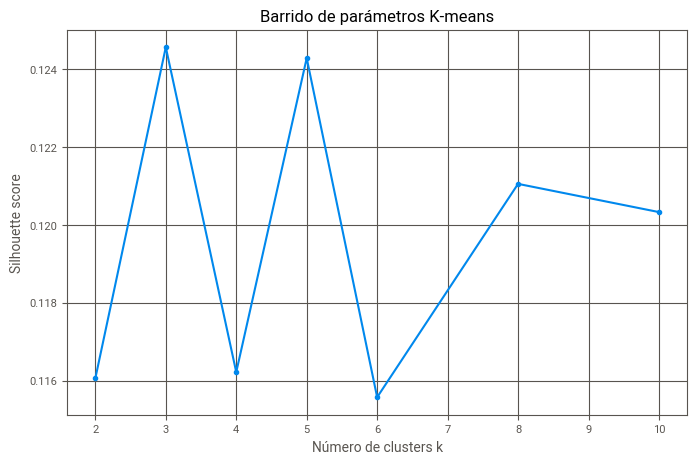

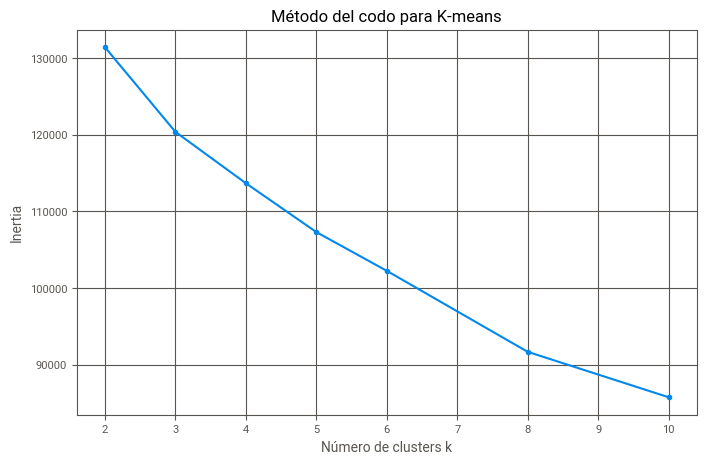

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette score")
plt.title("Barrido de parámetros K-means")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["n_clusters"],
    kmeans_results_df["inertia"],
    marker="o"
)

plt.xlabel("Número de clusters k")
plt.ylabel("Inertia")
plt.title("Método del codo para K-means")
plt.grid(True)
plt.show()

In [47]:
MAX_DBSCAN_ROWS = 5000

if X_cluster_scaled.shape[0] > MAX_DBSCAN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    dbscan_idx = rng.choice(
        X_cluster_scaled.shape[0],
        size=MAX_DBSCAN_ROWS,
        replace=False
    )
    X_dbscan = X_cluster_scaled[dbscan_idx]
    df_dbscan_base = df_model.iloc[dbscan_idx].copy()
else:
    dbscan_idx = np.arange(X_cluster_scaled.shape[0])
    X_dbscan = X_cluster_scaled
    df_dbscan_base = df_model.copy()

print("Matriz usada para DBSCAN:", X_dbscan.shape)

eps_values = [0.5, 0.8, 1.0, 1.3, 1.6, 2.0]
min_samples_values = [5, 10, 20]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_dbscan)
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        noise_ratio = np.mean(labels == -1)
        
        # Silhouette solo es válido si hay más de un cluster real
        if n_clusters >= 2:
            try:
                silhouette = silhouette_score(X_dbscan, labels)
                calinski = calinski_harabasz_score(X_dbscan, labels)
                davies = davies_bouldin_score(X_dbscan, labels)
            except Exception:
                silhouette = np.nan
                calinski = np.nan
                davies = np.nan
        else:
            silhouette = np.nan
            calinski = np.nan
            davies = np.nan
        
        dbscan_results.append({
            "metodo": "DBSCAN",
            "parametros": f"eps={eps}, min_samples={min_samples}",
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "silhouette": silhouette,
            "inertia": np.nan,
            "calinski_harabasz": calinski,
            "davies_bouldin": davies,
            "noise_ratio": noise_ratio,
            "interpretacion_limite": "DBSCAN puede marcar muchos puntos como ruido si la densidad no es adecuada."
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

Matriz usada para DBSCAN: (5000, 10)


,metodo,parametros,eps,min_samples,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite
0,DBSCAN,"eps=0.5, min_samples=5",0.50,5,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
1,DBSCAN,"eps=0.5, min_samples=10",0.50,10,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
2,DBSCAN,"eps=0.5, min_samples=20",0.50,20,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
3,DBSCAN,"eps=0.8, min_samples=5",0.80,5,13,-0.33,NaN,4.07,1.33,0.99,DBSCAN puede marcar muchos puntos como ruido s...
4,DBSCAN,"eps=0.8, min_samples=10",0.80,10,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
5,DBSCAN,"eps=0.8, min_samples=20",0.80,20,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
6,DBSCAN,"eps=1.0, min_samples=5",1.00,5,98,-0.38,NaN,7.58,1.62,0.78,DBSCAN puede marcar muchos puntos como ruido s...
7,DBSCAN,"eps=1.0, min_samples=10",1.00,10,1,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
8,DBSCAN,"eps=1.0, min_samples=20",1.00,20,0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...
9,DBSCAN,"eps=1.3, min_samples=5",1.30,5,15,-0.17,NaN,42.43,1.96,0.22,DBSCAN puede marcar muchos puntos como ruido s...


In [48]:
validation_table = pd.concat(
    [
        kmeans_results_df,
        dbscan_results_df
    ],
    ignore_index=True
)

validation_table = validation_table.sort_values(
    by=["metodo", "silhouette"],
    ascending=[True, False]
)

display(validation_table)

,metodo,parametros,n_clusters,silhouette,inertia,calinski_harabasz,davies_bouldin,noise_ratio,interpretacion_limite,eps,min_samples
22,DBSCAN,"eps=2.0, min_samples=5",4,0.21,NaN,41.54,2.03,0.03,DBSCAN puede marcar muchos puntos como ruido s...,2.00,5.00
20,DBSCAN,"eps=1.6, min_samples=10",3,0.13,NaN,87.35,2.92,0.11,DBSCAN puede marcar muchos puntos como ruido s...,1.60,10.00
19,DBSCAN,"eps=1.6, min_samples=5",4,0.09,NaN,44.49,2.19,0.07,DBSCAN puede marcar muchos puntos como ruido s...,1.60,5.00
16,DBSCAN,"eps=1.3, min_samples=5",15,-0.17,NaN,42.43,1.96,0.22,DBSCAN puede marcar muchos puntos como ruido s...,1.30,5.00
17,DBSCAN,"eps=1.3, min_samples=10",13,-0.24,NaN,34.37,2.25,0.41,DBSCAN puede marcar muchos puntos como ruido s...,1.30,10.00
18,DBSCAN,"eps=1.3, min_samples=20",11,-0.25,NaN,34.22,2.08,0.81,DBSCAN puede marcar muchos puntos como ruido s...,1.30,20.00
10,DBSCAN,"eps=0.8, min_samples=5",13,-0.33,NaN,4.07,1.33,0.99,DBSCAN puede marcar muchos puntos como ruido s...,0.80,5.00
13,DBSCAN,"eps=1.0, min_samples=5",98,-0.38,NaN,7.58,1.62,0.78,DBSCAN puede marcar muchos puntos como ruido s...,1.00,5.00
7,DBSCAN,"eps=0.5, min_samples=5",0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...,0.50,5.00
8,DBSCAN,"eps=0.5, min_samples=10",0,NaN,NaN,NaN,NaN,1.00,DBSCAN puede marcar muchos puntos como ruido s...,0.50,10.00


In [49]:
best_kmeans_row = kmeans_results_df.sort_values(
    by="silhouette",
    ascending=False
).iloc[0]

best_k = int(best_kmeans_row["n_clusters"])

print("Mejor K-means:")
display(best_kmeans_row)

best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = best_kmeans.fit_predict(X_cluster_scaled)


# Para DBSCAN, elegimos el mejor caso con al menos 2 clusters
# y no demasiado ruido.

valid_dbscan = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 2) &
    (dbscan_results_df["noise_ratio"] < 0.80) &
    (dbscan_results_df["silhouette"].notna())
].copy()

if len(valid_dbscan) > 0:
    best_dbscan_row = valid_dbscan.sort_values(
        by="silhouette",
        ascending=False
    ).iloc[0]
    
    best_eps = float(best_dbscan_row["eps"])
    best_min_samples = int(best_dbscan_row["min_samples"])
    
    print("Mejor DBSCAN:")
    display(best_dbscan_row)
    
    best_dbscan = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )
    
    dbscan_labels = best_dbscan.fit_predict(X_dbscan)

else:
    best_dbscan_row = None
    dbscan_labels = None
    print("No se encontró una configuración válida de DBSCAN con al menos 2 clusters y ruido menor a 80%.")

Mejor K-means:


metodo                                                             K-means
parametros                                                             k=3
n_clusters                                                               3
silhouette                                                            0.12
inertia                                                          120373.30
calinski_harabasz                                                  1845.56
davies_bouldin                                                        2.37
noise_ratio                                                              0
interpretacion_limite    K-means fuerza a todos los puntos a pertenecer...
Name: 1, dtype: object

Mejor DBSCAN:


metodo                                                              DBSCAN
parametros                                          eps=2.0, min_samples=5
eps                                                                   2.00
min_samples                                                              5
n_clusters                                                               4
silhouette                                                            0.21
inertia                                                                NaN
calinski_harabasz                                                    41.54
davies_bouldin                                                        2.03
noise_ratio                                                           0.03
interpretacion_limite    DBSCAN puede marcar muchos puntos como ruido s...
Name: 15, dtype: object

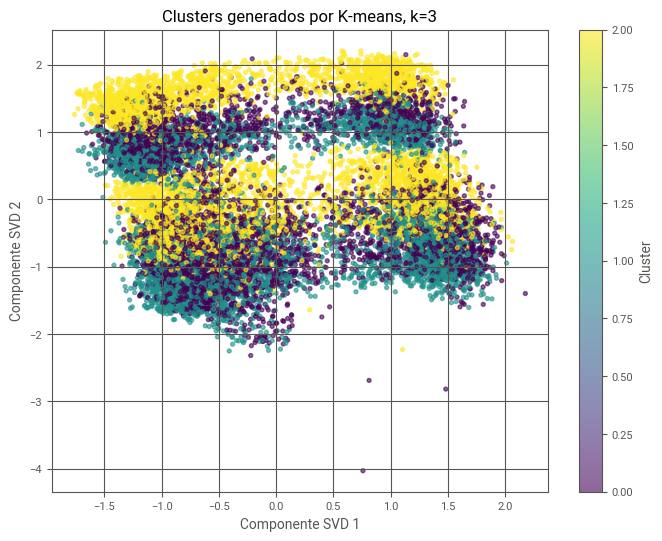

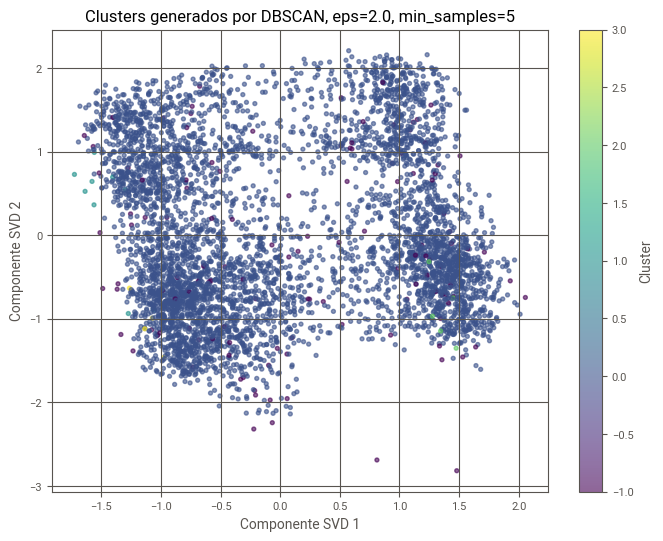

In [50]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_cluster_scaled[:, 0],
    X_cluster_scaled[:, 1],
    c=kmeans_labels,
    s=8,
    alpha=0.6
)

plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.title(f"Clusters generados por K-means, k={best_k}")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


if dbscan_labels is not None:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_dbscan[:, 0],
        X_dbscan[:, 1],
        c=dbscan_labels,
        s=8,
        alpha=0.6
    )

    plt.xlabel("Componente SVD 1")
    plt.ylabel("Componente SVD 2")
    plt.title(f"Clusters generados por DBSCAN, eps={best_eps}, min_samples={best_min_samples}")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True)
    plt.show()

In [51]:
df_cluster_profile = df_model.copy()
df_cluster_profile["cluster_kmeans"] = kmeans_labels

possible_profile_cols = [
    "monto",
    "edad",
    "distancia_cliente_comercio",
    "hora",
    "dia_de_semana_num",
    "mes",
    "es_fin_de_semana",
    "es_fraude"
]

profile_cols = [
    col for col in possible_profile_cols
    if col in df_cluster_profile.columns
]

print("Columnas usadas para perfilar clusters:")
print(profile_cols)

cluster_profile_kmeans = df_cluster_profile.groupby("cluster_kmeans")[profile_cols].agg(
    ["count", "mean", "median", "std"]
)

display(cluster_profile_kmeans)

Columnas usadas para perfilar clusters:
['monto', 'es_fin_de_semana', 'es_fraude']


monto                      es_fin_de_semana                   \
               count   mean median    std            count mean median  std   
cluster_kmeans                                                                
0               5106 118.69  50.53 248.14             5106 0.33   0.00 0.47   
1               4582 116.87  54.26 211.50             4582 0.33   0.00 0.47   
2               5312 102.94  50.16 200.23             5312 0.37   0.00 0.48   

               es_fraude                   
                   count mean median  std  
cluster_kmeans                             
0                   5106 0.10   0.00 0.30  
1                   4582 0.12   0.00 0.33  
2                   5312 0.08   0.00 0.27

In [52]:
summary_rows = []

for cluster_id, group in df_cluster_profile.groupby("cluster_kmeans"):
    
    row = {
        "cluster": cluster_id,
        "cantidad_transacciones": len(group),
        "porcentaje_total": len(group) / len(df_cluster_profile)
    }
    
    if "es_fraude" in group.columns:
        row["tasa_fraude"] = group["es_fraude"].mean()
    
    if "monto" in group.columns:
        row["monto_promedio"] = group["monto"].mean()
        row["monto_mediano"] = group["monto"].median()
    
    if "edad" in group.columns:
        row["edad_promedio"] = group["edad"].mean()
    
    if "distancia_cliente_comercio" in group.columns:
        row["distancia_promedio"] = group["distancia_cliente_comercio"].mean()
    
    if "hora" in group.columns:
        row["hora_promedio"] = group["hora"].mean()
    
    summary_rows.append(row)

cluster_summary_kmeans = pd.DataFrame(summary_rows)

display(cluster_summary_kmeans)

,cluster,cantidad_transacciones,porcentaje_total,tasa_fraude,monto_promedio,monto_mediano
0,0,5106,0.34,0.10,118.69,50.53
1,1,4582,0.31,0.12,116.87,54.26
2,2,5312,0.35,0.08,102.94,50.16


In [53]:
possible_categorical_profile_cols = [
    "categoria",
    "genero",
    "estado",
    "ciudad",
    "trabajo"
]

categorical_profile_cols = [
    col for col in possible_categorical_profile_cols
    if col in df_cluster_profile.columns
]

for col in categorical_profile_cols:
    print(f"\nVariable categórica: {col}")
    
    top_categories = (
        df_cluster_profile
        .groupby("cluster_kmeans")[col]
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={col: f"{col}_mas_frecuente"})
    )
    
    display(top_categories)


Variable categórica: genero


,cluster_kmeans,genero_mas_frecuente
0,0,F
1,1,F
2,2,F



Variable categórica: estado


,cluster_kmeans,estado_mas_frecuente
0,0,TX
1,1,NY
2,2,TX



Variable categórica: ciudad


,cluster_kmeans,ciudad_mas_frecuente
0,0,Sun City
1,1,Phoenix
2,2,Birmingham


In [54]:
if dbscan_labels is not None:
    df_dbscan_profile = df_dbscan_base.copy()
    df_dbscan_profile["cluster_dbscan"] = dbscan_labels
    
    dbscan_summary_rows = []
    
    for cluster_id, group in df_dbscan_profile.groupby("cluster_dbscan"):
        
        row = {
            "cluster": cluster_id,
            "cantidad_transacciones": len(group),
            "porcentaje_total": len(group) / len(df_dbscan_profile)
        }
        
        if cluster_id == -1:
            row["tipo"] = "ruido"
        else:
            row["tipo"] = "cluster"
        
        if "es_fraude" in group.columns:
            row["tasa_fraude"] = group["es_fraude"].mean()
        
        if "monto" in group.columns:
            row["monto_promedio"] = group["monto"].mean()
            row["monto_mediano"] = group["monto"].median()
        
        if "edad" in group.columns:
            row["edad_promedio"] = group["edad"].mean()
        
        if "distancia_cliente_comercio" in group.columns:
            row["distancia_promedio"] = group["distancia_cliente_comercio"].mean()
        
        dbscan_summary_rows.append(row)
    
    cluster_summary_dbscan = pd.DataFrame(dbscan_summary_rows)
    
    display(cluster_summary_dbscan)
else:
    print("No se generó perfil DBSCAN porque no hubo una configuración válida.")

,cluster,cantidad_transacciones,porcentaje_total,tipo,tasa_fraude,monto_promedio,monto_mediano
0,-1,127,0.03,ruido,0.35,479.69,115.45
1,0,4855,0.97,cluster,0.09,104.79,50.96
2,1,9,0.00,cluster,0.00,13.03,7.64
3,2,5,0.00,cluster,0.60,200.95,285.88
4,3,4,0.00,cluster,0.00,35.88,24.05


In [55]:
kmeans_best_silhouette = best_kmeans_row["silhouette"]
kmeans_best_inertia = best_kmeans_row["inertia"]

interpretacion_week7 = f"""
Interpretación de Semana 7:

Se aplicaron dos métodos de clustering no supervisado sobre la matriz reducida mediante SVD.

1. K-means:
El mejor resultado de K-means se obtuvo con k={best_k}, alcanzando un silhouette score de {kmeans_best_silhouette:.4f}.
La inercia del modelo fue {kmeans_best_inertia:.4f}. Este resultado indica qué tan compactos se encuentran
los grupos generados. Sin embargo, K-means obliga a que todas las transacciones pertenezcan a algún cluster,
por lo que puede agrupar puntos que realmente no tienen una separación natural clara.

2. DBSCAN:
DBSCAN fue evaluado mediante un barrido de eps y min_samples. Este método permite identificar ruido,
lo cual es útil en un problema de fraude porque algunas transacciones pueden comportarse como anomalías.
No obstante, DBSCAN es sensible a sus parámetros y a la densidad de los datos. Cuando eps es muy bajo,
muchos puntos son clasificados como ruido. Cuando eps es muy alto, varios grupos pueden fusionarse.

3. Perfil de clusters:
El análisis de perfiles permite observar diferencias entre grupos en variables como monto, edad,
distancia entre cliente y comercio, hora de transacción y tasa de fraude. Si algún cluster muestra una
tasa de fraude superior al promedio, puede interpretarse como un segmento de mayor riesgo.

4. Análisis de fallos:
El clustering no separa perfectamente las transacciones fraudulentas porque el fraude es una clase muy
minoritaria y muchas operaciones fraudulentas pueden parecerse a operaciones legítimas. Además, las variables
disponibles no necesariamente generan fronteras claras entre fraude y no fraude. Por ello, el clustering debe
interpretarse como una técnica exploratoria de segmentación y no como un clasificador final de fraude.

5. Límite de interpretación:
Los clusters encontrados no representan necesariamente categorías reales del negocio. Son agrupaciones
matemáticas basadas en similitud entre transacciones. Para una detección formal de fraude, sería necesario
entrenar modelos supervisados y evaluar métricas como recall, precision, F1-score y PR-AUC.
"""

print(interpretacion_week7)


Interpretación de Semana 7:

Se aplicaron dos métodos de clustering no supervisado sobre la matriz reducida mediante SVD.

1. K-means:
El mejor resultado de K-means se obtuvo con k=3, alcanzando un silhouette score de 0.1246.
La inercia del modelo fue 120373.3021. Este resultado indica qué tan compactos se encuentran
los grupos generados. Sin embargo, K-means obliga a que todas las transacciones pertenezcan a algún cluster,
por lo que puede agrupar puntos que realmente no tienen una separación natural clara.

2. DBSCAN:
DBSCAN fue evaluado mediante un barrido de eps y min_samples. Este método permite identificar ruido,
lo cual es útil en un problema de fraude porque algunas transacciones pueden comportarse como anomalías.
No obstante, DBSCAN es sensible a sus parámetros y a la densidad de los datos. Cuando eps es muy bajo,
muchos puntos son clasificados como ruido. Cuando eps es muy alto, varios grupos pueden fusionarse.

3. Perfil de clusters:
El análisis de perfiles permite observar

In [56]:
from pathlib import Path

output_dir_week7 = project_root / "data" / "week7"
output_dir_week7.mkdir(parents=True, exist_ok=True)

validation_table.to_csv(
    output_dir_week7 / "validation_table_week7.csv",
    index=False
)

cluster_summary_kmeans.to_csv(
    output_dir_week7 / "cluster_profile_kmeans_week7.csv",
    index=False
)

if dbscan_labels is not None:
    cluster_summary_dbscan.to_csv(
        output_dir_week7 / "cluster_profile_dbscan_week7.csv",
        index=False
    )

with open(output_dir_week7 / "interpretacion_week7.txt", "w", encoding="utf-8") as f:
    f.write(interpretacion_week7)

print("Entregables Semana 7 guardados en:")
print(output_dir_week7.resolve())

Entregables Semana 7 guardados en:
C:\Users\Ian\Documents\UPC\9 ciclo\Big Data\Fraud-Detection\data\week7
